In [13]:
import json
import logging
from utils.cross_validation_siamese_raw import CrossValidationSiameseRaw
from utils.gait_parameters_extractor import CoordinatesIdx
from pathlib import Path


with open("./datasets/mocap/dataset_mocap_cycles_split.json", "r") as file:
    mocap_cycles = json.load(file)

with open("./datasets/yolo/dataset_yolo26_triang_cycles_split.json", "r") as file:
    yolo_cycles = json.load(file)

with open("./datasets/yolo/dataset_yolo26_triang_best_cameras_cycles_split.json", "r") as file:
    yolo_best_cams_cycles = json.load(file)

with open("./datasets/yolo/dataset_yolo26_triang_cycles_split_butterworth.json", "r") as file:
    yolo_cycles_butterworth = json.load(file)

with open("./datasets/yolo/dataset_yolo26_triang_best_cameras_cycles_split_butterworth.json", "r") as file:
    yolo_best_cams_cycles_butterworth = json.load(file)

In [66]:
from dataclasses import dataclass

@dataclass
class TrainingParameters():
    learning_rate: float = 1e-4
    batch_size: int = 32
    n_epochs: int = 20


@dataclass
class TrainingProcedureParameters():
    tp_conv1d: TrainingParameters
    tp_lstm: TrainingParameters
    n_folds:int = 4
    
tpp = TrainingProcedureParameters(
    tp_conv1d = TrainingParameters(
        learning_rate = 1e-6,
        batch_size = 32,
        n_epochs = 100,
    ),
    tp_lstm = TrainingParameters(
        learning_rate = 1e-5,
        batch_size = 32,
        n_epochs = 150,
    )
)

tpp

TrainingProcedureParameters(tp_conv1d=TrainingParameters(learning_rate=1e-06, batch_size=32, n_epochs=100), tp_lstm=TrainingParameters(learning_rate=1e-05, batch_size=32, n_epochs=150), n_folds=4)

2026-02-06 10:20:49,068 - yolo - INFO - Preparing cycles and participant labels...
2026-02-06 10:20:59,924 - yolo - DEBUG - [0] Test fold participants: [27, 26, 20, 29, 31, 3, 30, 9]
2026-02-06 10:20:59,925 - yolo - DEBUG - [0] Train fold participants: [1, 2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 28, 32] 
2026-02-06 10:20:59,925 - yolo - DEBUG - [1] Test fold participants: [6, 12, 13, 15, 2, 18, 5, 24]
2026-02-06 10:20:59,926 - yolo - DEBUG - [1] Train fold participants: [1, 3, 4, 7, 8, 9, 10, 11, 14, 16, 17, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32] 
2026-02-06 10:20:59,926 - yolo - DEBUG - [2] Test fold participants: [11, 23, 17, 25, 14, 22, 28, 1]
2026-02-06 10:20:59,927 - yolo - DEBUG - [2] Train fold participants: [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 15, 16, 18, 19, 20, 21, 24, 26, 27, 29, 30, 31, 32] 
2026-02-06 10:20:59,927 - yolo - DEBUG - [3] Test fold participants: [16, 7, 10, 21, 19, 4, 32, 8]
2026-02-06 10:20:59,928 - yolo - DE

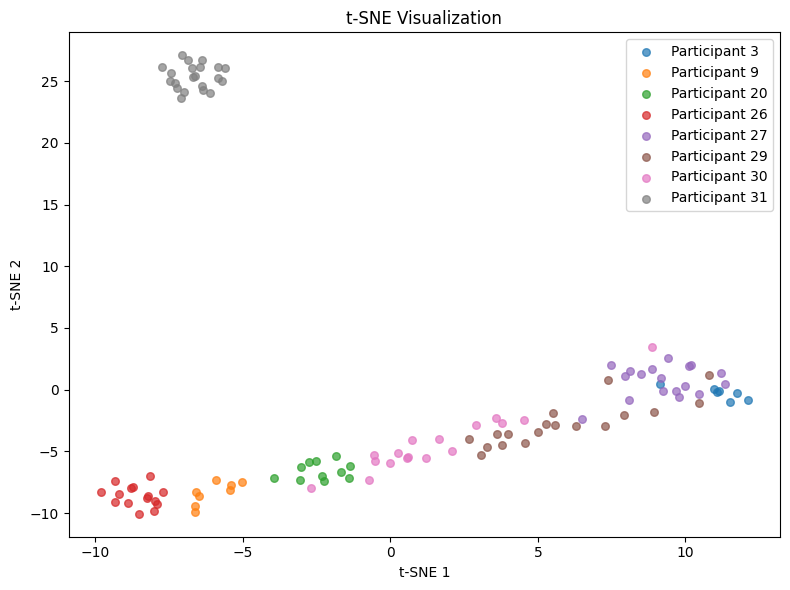

2026-02-06 10:21:30,668 - yolo - INFO - Test set size for rank classification: 115
2026-02-06 10:21:30,669 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 10:21:30,670 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 10:21:30,670 - yolo - INFO - -------------------------------------------------------
2026-02-06 10:21:30,694 - yolo - INFO - k-NN eucl    | 0.7826     | 0.9391     | 0.9739
2026-02-06 10:21:30,714 - yolo - INFO - k-NN manh    | 0.8435     | 0.9304     | 0.9652
2026-02-06 10:21:30,755 - yolo - INFO - SVM          | 0.8174     | 0.9217     | 1.0000
2026-02-06 10:21:31,991 - yolo - INFO - MLP          | 0.8348     | 0.9304     | 0.9826
2026-02-06 10:21:32,012 - yolo - INFO - NB           | 0.8696     | 0.9652     | 0.9913
2026-02-06 10:21:32,063 - yolo - INFO - LR           | 0.7826     | 0.9391     | 0.9739
2026-02-06 10:21:32,674 - yolo - INFO - RF           | 0.8870     | 0.9478     | 1.0000
2026-02-06 10:21:36,363 - yo

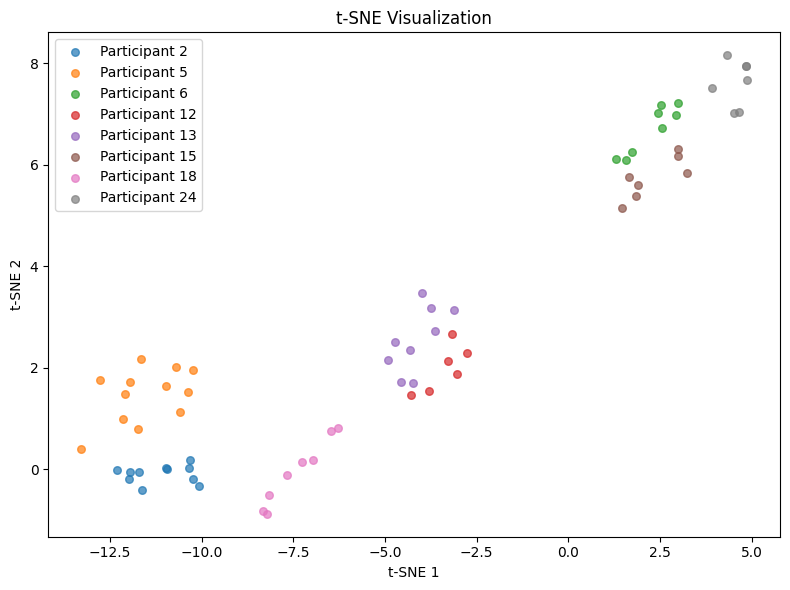

2026-02-06 10:22:03,187 - yolo - INFO - Test set size for rank classification: 68
2026-02-06 10:22:03,188 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 10:22:03,189 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 10:22:03,190 - yolo - INFO - -------------------------------------------------------
2026-02-06 10:22:03,211 - yolo - INFO - k-NN eucl    | 0.8231     | 0.9846     | 1.0000
2026-02-06 10:22:03,231 - yolo - INFO - k-NN manh    | 0.8516     | 1.0000     | 1.0000
2026-02-06 10:22:03,263 - yolo - INFO - SVM          | 0.8374     | 0.9846     | 1.0000
2026-02-06 10:22:04,166 - yolo - INFO - MLP          | 0.8824     | 0.9714     | 1.0000
2026-02-06 10:22:04,186 - yolo - INFO - NB           | 0.9264     | 1.0000     | 1.0000
2026-02-06 10:22:04,233 - yolo - INFO - LR           | 0.9121     | 0.9846     | 0.9846
2026-02-06 10:22:04,815 - yolo - INFO - RF           | 0.9407     | 1.0000     | 1.0000
2026-02-06 10:22:07,867 - yol

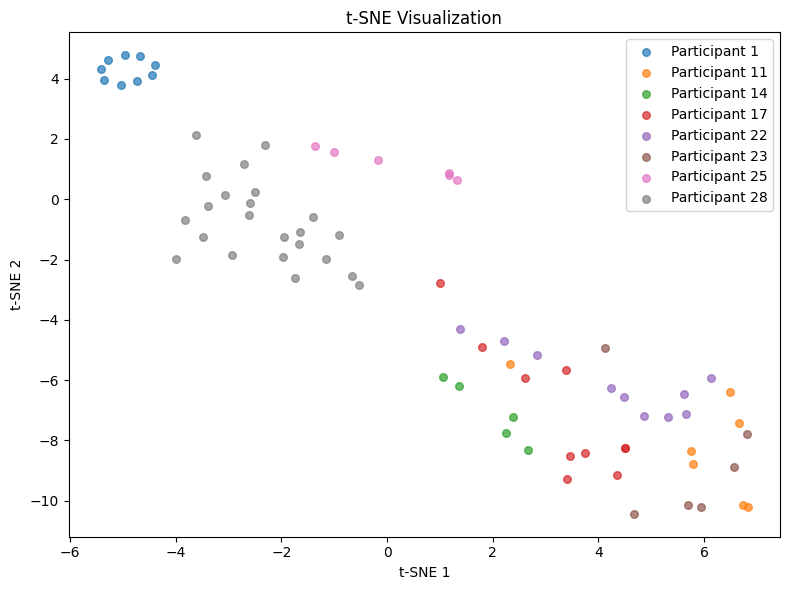

2026-02-06 10:22:33,394 - yolo - INFO - Test set size for rank classification: 76
2026-02-06 10:22:33,395 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 10:22:33,396 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 10:22:33,396 - yolo - INFO - -------------------------------------------------------
2026-02-06 10:22:33,417 - yolo - INFO - k-NN eucl    | 0.7633     | 0.9083     | 0.9875
2026-02-06 10:22:33,436 - yolo - INFO - k-NN manh    | 0.7892     | 0.8958     | 0.9617
2026-02-06 10:22:33,473 - yolo - INFO - SVM          | 0.8033     | 0.9350     | 0.9742
2026-02-06 10:22:34,367 - yolo - INFO - MLP          | 0.8300     | 0.9350     | 0.9867
2026-02-06 10:22:34,388 - yolo - INFO - NB           | 0.8025     | 0.8808     | 0.8942
2026-02-06 10:22:34,426 - yolo - INFO - LR           | 0.8692     | 0.9358     | 0.9608
2026-02-06 10:22:35,008 - yolo - INFO - RF           | 0.8283     | 0.9350     | 0.9875
2026-02-06 10:22:38,302 - yol

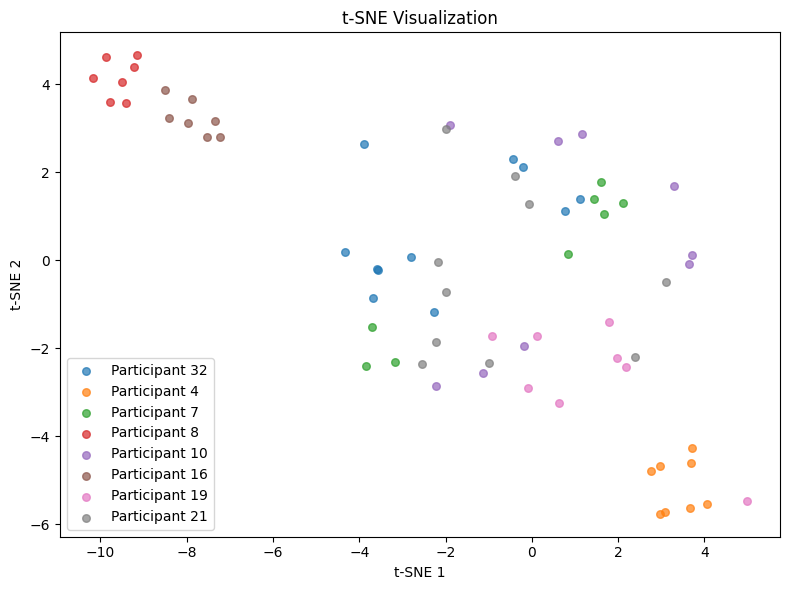

2026-02-06 10:23:07,225 - yolo - INFO - Test set size for rank classification: 68
2026-02-06 10:23:07,226 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 10:23:07,227 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 10:23:07,227 - yolo - INFO - -------------------------------------------------------
2026-02-06 10:23:07,248 - yolo - INFO - k-NN eucl    | 0.5286     | 0.7352     | 0.8824
2026-02-06 10:23:07,267 - yolo - INFO - k-NN manh    | 0.5582     | 0.7495     | 0.8835
2026-02-06 10:23:07,301 - yolo - INFO - SVM          | 0.4967     | 0.6901     | 0.9121
2026-02-06 10:23:08,229 - yolo - INFO - MLP          | 0.7758     | 0.9110     | 0.9407
2026-02-06 10:23:08,251 - yolo - INFO - NB           | 0.6604     | 0.7780     | 0.8659
2026-02-06 10:23:08,293 - yolo - INFO - LR           | 0.7187     | 0.8824     | 0.9253
2026-02-06 10:23:08,879 - yolo - INFO - RF           | 0.6890     | 0.8363     | 0.9549
2026-02-06 10:23:12,220 - yol

In [2]:
cv = CrossValidationSiameseRaw(
    sequence_cycles = yolo_cycles, 
    coordinates_idx = CoordinatesIdx(0, 1, 2), 
    log_level = logging.DEBUG,
    logger_name = 'yolo',
)
cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "conv1d",
    learning_rate = 1e-4,
    batch_size = 32,
    n_epochs = 20,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-06 10:26:28,334 - yolo - DEBUG - [0] Test fold participants: [27, 26, 20, 29, 31, 3, 30, 9]
2026-02-06 10:26:28,335 - yolo - DEBUG - [0] Train fold participants: [1, 2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 28, 32] 
2026-02-06 10:26:28,335 - yolo - DEBUG - [1] Test fold participants: [6, 12, 13, 15, 2, 18, 5, 24]
2026-02-06 10:26:28,336 - yolo - DEBUG - [1] Train fold participants: [1, 3, 4, 7, 8, 9, 10, 11, 14, 16, 17, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32] 
2026-02-06 10:26:28,336 - yolo - DEBUG - [2] Test fold participants: [11, 23, 17, 25, 14, 22, 28, 1]
2026-02-06 10:26:28,336 - yolo - DEBUG - [2] Train fold participants: [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 15, 16, 18, 19, 20, 21, 24, 26, 27, 29, 30, 31, 32] 
2026-02-06 10:26:28,337 - yolo - DEBUG - [3] Test fold participants: [16, 7, 10, 21, 19, 4, 32, 8]
2026-02-06 10:26:28,338 - yolo - DEBUG - [3] Train fold participants: [1, 2, 3, 5, 6, 9, 11, 12, 13, 14, 15, 17, 18, 2

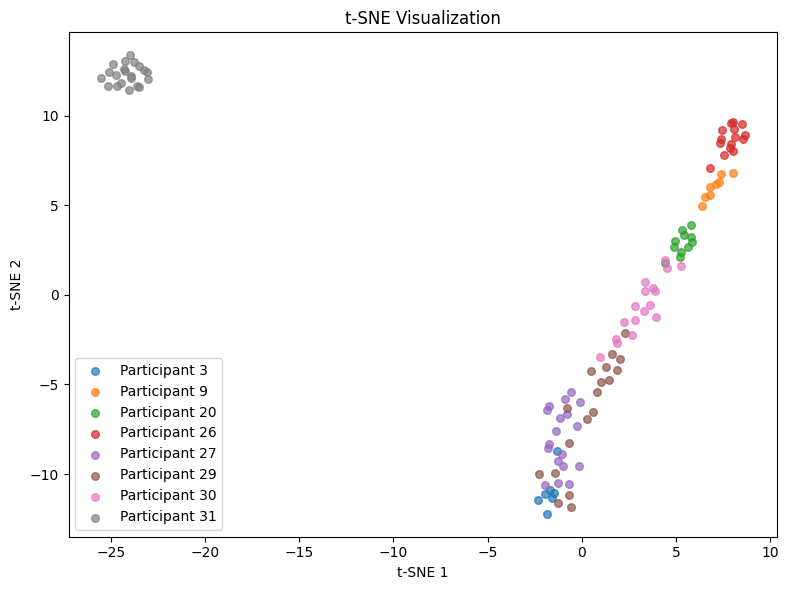

2026-02-06 10:26:37,552 - yolo - INFO - Test set size for rank classification: 115
2026-02-06 10:26:37,553 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 10:26:37,553 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 10:26:37,554 - yolo - INFO - -------------------------------------------------------
2026-02-06 10:26:37,576 - yolo - INFO - k-NN eucl    | 0.7739     | 0.9304     | 0.9652
2026-02-06 10:26:37,597 - yolo - INFO - k-NN manh    | 0.7478     | 0.9565     | 0.9826
2026-02-06 10:26:37,638 - yolo - INFO - SVM          | 0.7043     | 0.9478     | 1.0000
2026-02-06 10:26:38,889 - yolo - INFO - MLP          | 0.8174     | 0.9739     | 1.0000
2026-02-06 10:26:38,911 - yolo - INFO - NB           | 0.7739     | 0.9565     | 0.9913
2026-02-06 10:26:38,965 - yolo - INFO - LR           | 0.6957     | 0.9043     | 0.9913
2026-02-06 10:26:39,580 - yolo - INFO - RF           | 0.7913     | 0.9652     | 0.9913
2026-02-06 10:26:43,383 - yo

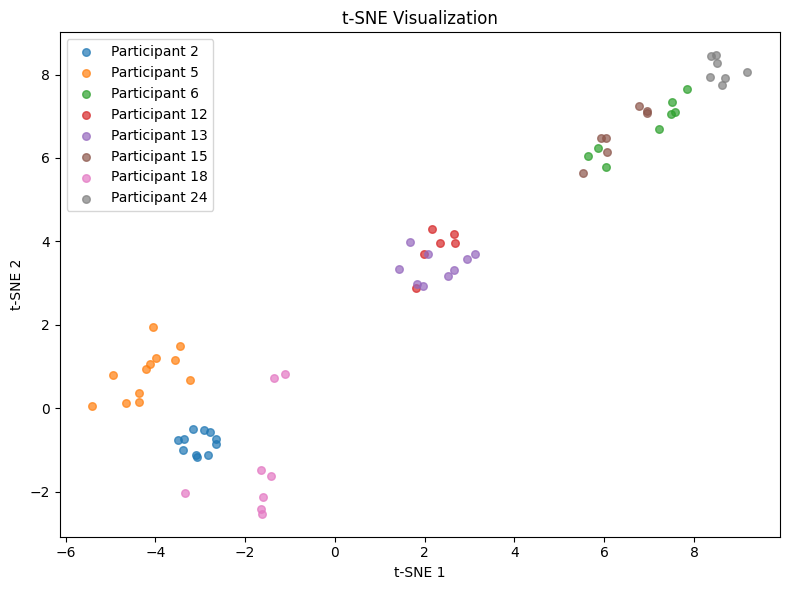

2026-02-06 10:26:57,454 - yolo - INFO - Test set size for rank classification: 68
2026-02-06 10:26:57,455 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 10:26:57,456 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 10:26:57,456 - yolo - INFO - -------------------------------------------------------
2026-02-06 10:26:57,478 - yolo - INFO - k-NN eucl    | 0.8099     | 0.9714     | 1.0000
2026-02-06 10:26:57,498 - yolo - INFO - k-NN manh    | 0.8088     | 0.9571     | 1.0000
2026-02-06 10:26:57,530 - yolo - INFO - SVM          | 0.7363     | 0.9714     | 0.9857
2026-02-06 10:26:58,622 - yolo - INFO - MLP          | 0.8385     | 0.9407     | 0.9560
2026-02-06 10:26:58,643 - yolo - INFO - NB           | 0.7934     | 0.9714     | 1.0000
2026-02-06 10:26:58,687 - yolo - INFO - LR           | 0.8374     | 0.9549     | 0.9846
2026-02-06 10:26:59,265 - yolo - INFO - RF           | 0.8385     | 0.9692     | 0.9846
2026-02-06 10:27:02,317 - yol

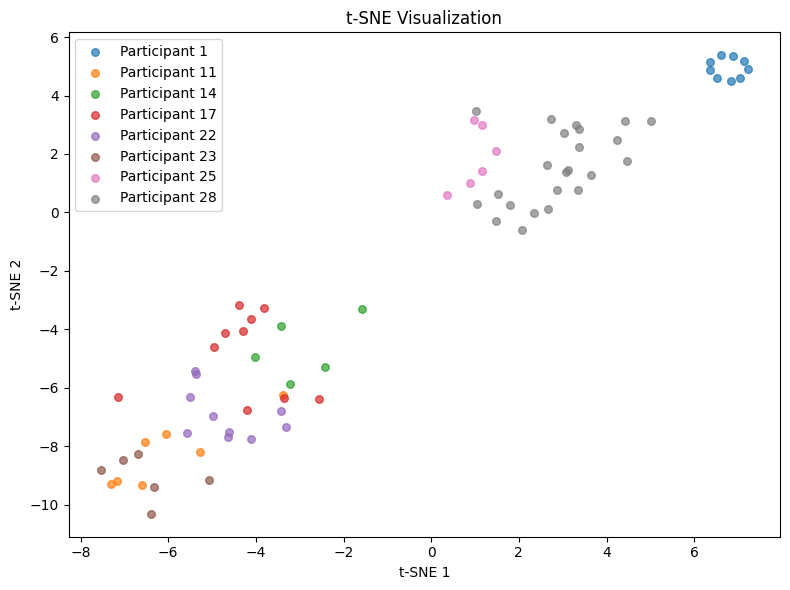

2026-02-06 10:27:14,370 - yolo - INFO - Test set size for rank classification: 76
2026-02-06 10:27:14,371 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 10:27:14,372 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 10:27:14,372 - yolo - INFO - -------------------------------------------------------
2026-02-06 10:27:14,395 - yolo - INFO - k-NN eucl    | 0.7367     | 0.9083     | 0.9217
2026-02-06 10:27:14,422 - yolo - INFO - k-NN manh    | 0.7108     | 0.9483     | 0.9483
2026-02-06 10:27:14,458 - yolo - INFO - SVM          | 0.7383     | 0.9083     | 0.9608
2026-02-06 10:27:15,571 - yolo - INFO - MLP          | 0.8142     | 0.9475     | 0.9475
2026-02-06 10:27:15,592 - yolo - INFO - NB           | 0.8017     | 0.9608     | 0.9742
2026-02-06 10:27:15,636 - yolo - INFO - LR           | 0.8408     | 0.9342     | 0.9742
2026-02-06 10:27:16,230 - yolo - INFO - RF           | 0.7617     | 0.9475     | 0.9742
2026-02-06 10:27:19,616 - yol

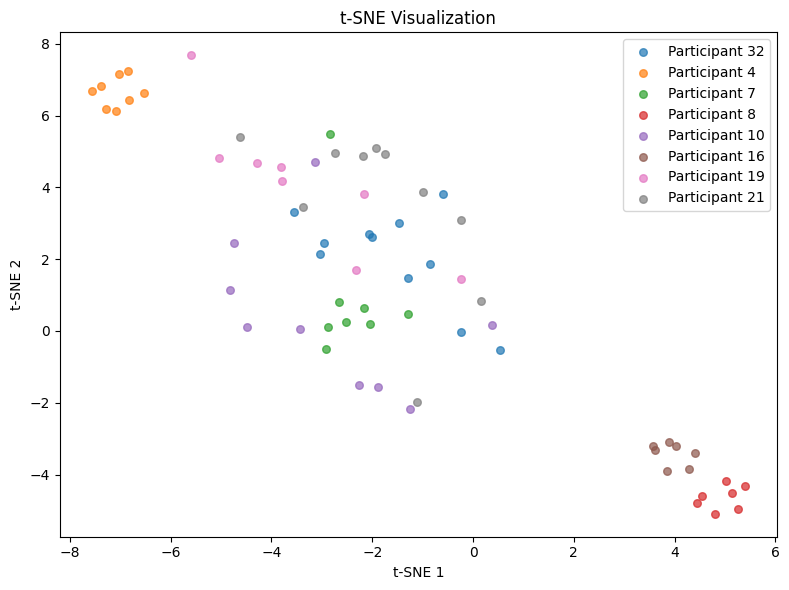

2026-02-06 10:27:33,316 - yolo - INFO - Test set size for rank classification: 68
2026-02-06 10:27:33,317 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 10:27:33,317 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 10:27:33,318 - yolo - INFO - -------------------------------------------------------
2026-02-06 10:27:33,338 - yolo - INFO - k-NN eucl    | 0.7374     | 0.8670     | 0.9121
2026-02-06 10:27:33,357 - yolo - INFO - k-NN manh    | 0.7220     | 0.8231     | 0.9110
2026-02-06 10:27:33,391 - yolo - INFO - SVM          | 0.6022     | 0.9088     | 0.9692
2026-02-06 10:27:34,360 - yolo - INFO - MLP          | 0.7484     | 0.9121     | 0.9857
2026-02-06 10:27:34,388 - yolo - INFO - NB           | 0.7198     | 0.8209     | 0.8802
2026-02-06 10:27:34,431 - yolo - INFO - LR           | 0.7198     | 0.8813     | 0.9549
2026-02-06 10:27:35,018 - yolo - INFO - RF           | 0.7341     | 0.8527     | 0.9549
2026-02-06 10:27:38,287 - yol

In [3]:
cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "conv1d",
    learning_rate = 1e-3,
    batch_size = 32,
    n_epochs = 10,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-06 10:27:52,044 - yolo - DEBUG - [0] Test fold participants: [27, 26, 20, 29, 31, 3, 30, 9]
2026-02-06 10:27:52,045 - yolo - DEBUG - [0] Train fold participants: [1, 2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 28, 32] 
2026-02-06 10:27:52,046 - yolo - DEBUG - [1] Test fold participants: [6, 12, 13, 15, 2, 18, 5, 24]
2026-02-06 10:27:52,046 - yolo - DEBUG - [1] Train fold participants: [1, 3, 4, 7, 8, 9, 10, 11, 14, 16, 17, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32] 
2026-02-06 10:27:52,047 - yolo - DEBUG - [2] Test fold participants: [11, 23, 17, 25, 14, 22, 28, 1]
2026-02-06 10:27:52,048 - yolo - DEBUG - [2] Train fold participants: [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 15, 16, 18, 19, 20, 21, 24, 26, 27, 29, 30, 31, 32] 
2026-02-06 10:27:52,048 - yolo - DEBUG - [3] Test fold participants: [16, 7, 10, 21, 19, 4, 32, 8]
2026-02-06 10:27:52,049 - yolo - DEBUG - [3] Train fold participants: [1, 2, 3, 5, 6, 9, 11, 12, 13, 14, 15, 17, 18, 2

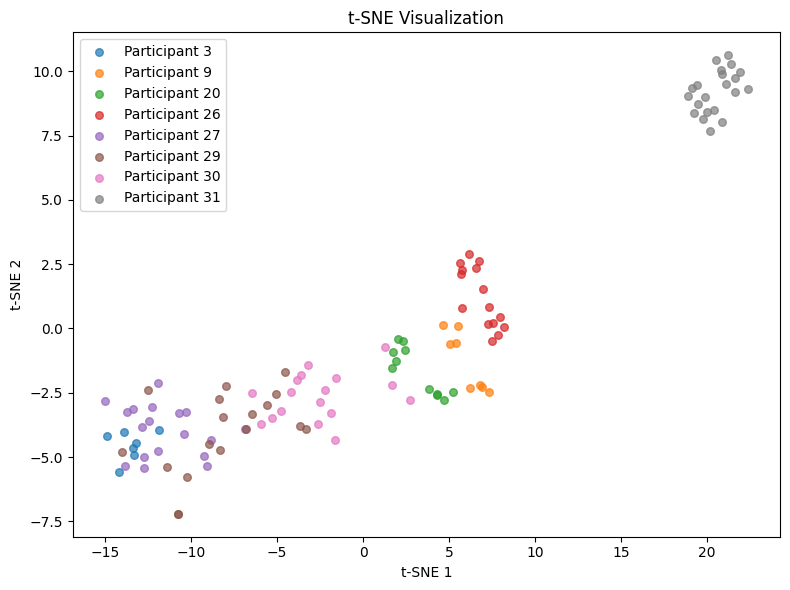

2026-02-06 10:28:34,321 - yolo - INFO - Test set size for rank classification: 115
2026-02-06 10:28:34,322 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 10:28:34,323 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 10:28:34,324 - yolo - INFO - -------------------------------------------------------
2026-02-06 10:28:34,344 - yolo - INFO - k-NN eucl    | 0.7304     | 0.8957     | 0.9739
2026-02-06 10:28:34,366 - yolo - INFO - k-NN manh    | 0.8000     | 0.9391     | 0.9652
2026-02-06 10:28:34,410 - yolo - INFO - SVM          | 0.8174     | 0.9478     | 0.9913
2026-02-06 10:28:35,640 - yolo - INFO - MLP          | 0.8783     | 0.9652     | 0.9739
2026-02-06 10:28:35,661 - yolo - INFO - NB           | 0.8000     | 0.9478     | 0.9913
2026-02-06 10:28:35,708 - yolo - INFO - LR           | 0.8261     | 0.9391     | 0.9913
2026-02-06 10:28:36,325 - yolo - INFO - RF           | 0.8783     | 0.9826     | 1.0000
2026-02-06 10:28:40,059 - yo

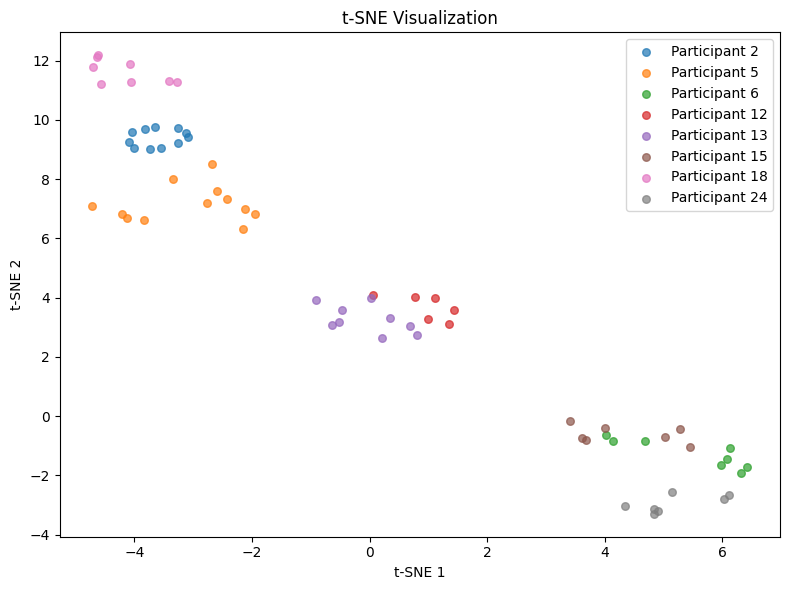

2026-02-06 10:29:45,347 - yolo - INFO - Test set size for rank classification: 68
2026-02-06 10:29:45,348 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 10:29:45,348 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 10:29:45,349 - yolo - INFO - -------------------------------------------------------
2026-02-06 10:29:45,371 - yolo - INFO - k-NN eucl    | 0.8088     | 1.0000     | 1.0000
2026-02-06 10:29:45,390 - yolo - INFO - k-NN manh    | 0.7945     | 1.0000     | 1.0000
2026-02-06 10:29:45,424 - yolo - INFO - SVM          | 0.8088     | 1.0000     | 1.0000
2026-02-06 10:29:46,336 - yolo - INFO - MLP          | 0.9396     | 0.9857     | 1.0000
2026-02-06 10:29:46,356 - yolo - INFO - NB           | 0.8813     | 0.9857     | 1.0000
2026-02-06 10:29:46,404 - yolo - INFO - LR           | 0.9132     | 0.9857     | 1.0000
2026-02-06 10:29:46,984 - yolo - INFO - RF           | 0.8967     | 1.0000     | 1.0000
2026-02-06 10:29:49,828 - yol

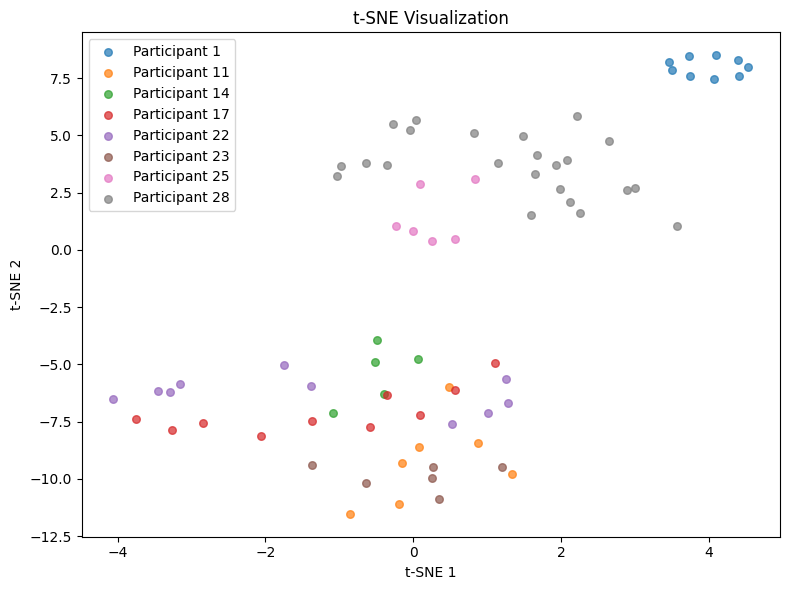

2026-02-06 10:30:47,283 - yolo - INFO - Test set size for rank classification: 76
2026-02-06 10:30:47,284 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 10:30:47,285 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 10:30:47,285 - yolo - INFO - -------------------------------------------------------
2026-02-06 10:30:47,306 - yolo - INFO - k-NN eucl    | 0.7092     | 0.8942     | 0.9733
2026-02-06 10:30:47,325 - yolo - INFO - k-NN manh    | 0.7092     | 0.8942     | 0.9475
2026-02-06 10:30:47,362 - yolo - INFO - SVM          | 0.7367     | 0.9475     | 0.9600
2026-02-06 10:30:48,281 - yolo - INFO - MLP          | 0.8008     | 0.9075     | 0.9608
2026-02-06 10:30:48,304 - yolo - INFO - NB           | 0.7225     | 0.8817     | 0.9342
2026-02-06 10:30:48,348 - yolo - INFO - LR           | 0.7758     | 0.9342     | 0.9608
2026-02-06 10:30:48,933 - yolo - INFO - RF           | 0.7617     | 0.9208     | 0.9475
2026-02-06 10:30:52,211 - yol

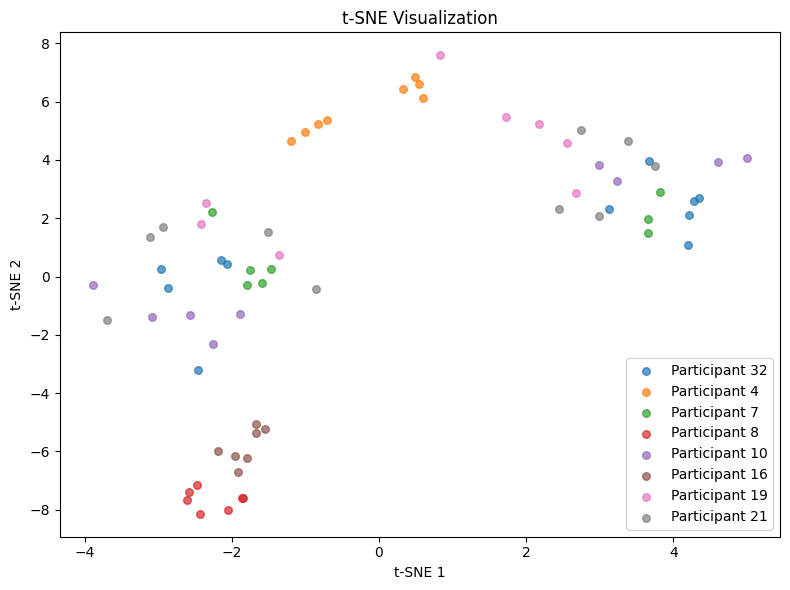

2026-02-06 10:31:58,088 - yolo - INFO - Test set size for rank classification: 68
2026-02-06 10:31:58,089 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 10:31:58,090 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 10:31:58,090 - yolo - INFO - -------------------------------------------------------
2026-02-06 10:31:58,113 - yolo - INFO - k-NN eucl    | 0.5143     | 0.7626     | 0.8945
2026-02-06 10:31:58,131 - yolo - INFO - k-NN manh    | 0.5132     | 0.8088     | 0.9253
2026-02-06 10:31:58,165 - yolo - INFO - SVM          | 0.5154     | 0.6769     | 0.8538
2026-02-06 10:31:59,181 - yolo - INFO - MLP          | 0.8363     | 0.9396     | 0.9549
2026-02-06 10:31:59,201 - yolo - INFO - NB           | 0.5440     | 0.7352     | 0.8835
2026-02-06 10:31:59,241 - yolo - INFO - LR           | 0.7187     | 0.8967     | 0.9253
2026-02-06 10:31:59,830 - yolo - INFO - RF           | 0.6044     | 0.7802     | 0.8967
2026-02-06 10:32:03,136 - yol

In [4]:
cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "conv1d",
    learning_rate = 1e-5,
    batch_size = 32,
    n_epochs = 50,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-06 10:56:58,267 - yolo - DEBUG - [0] Test fold participants: [27, 26, 20, 29, 31, 3, 30, 9]
2026-02-06 10:56:58,268 - yolo - DEBUG - [0] Train fold participants: [1, 2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 28, 32] 
2026-02-06 10:56:58,268 - yolo - DEBUG - [1] Test fold participants: [6, 12, 13, 15, 2, 18, 5, 24]
2026-02-06 10:56:58,269 - yolo - DEBUG - [1] Train fold participants: [1, 3, 4, 7, 8, 9, 10, 11, 14, 16, 17, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32] 
2026-02-06 10:56:58,269 - yolo - DEBUG - [2] Test fold participants: [11, 23, 17, 25, 14, 22, 28, 1]
2026-02-06 10:56:58,270 - yolo - DEBUG - [2] Train fold participants: [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 15, 16, 18, 19, 20, 21, 24, 26, 27, 29, 30, 31, 32] 
2026-02-06 10:56:58,270 - yolo - DEBUG - [3] Test fold participants: [16, 7, 10, 21, 19, 4, 32, 8]
2026-02-06 10:56:58,271 - yolo - DEBUG - [3] Train fold participants: [1, 2, 3, 5, 6, 9, 11, 12, 13, 14, 15, 17, 18, 2

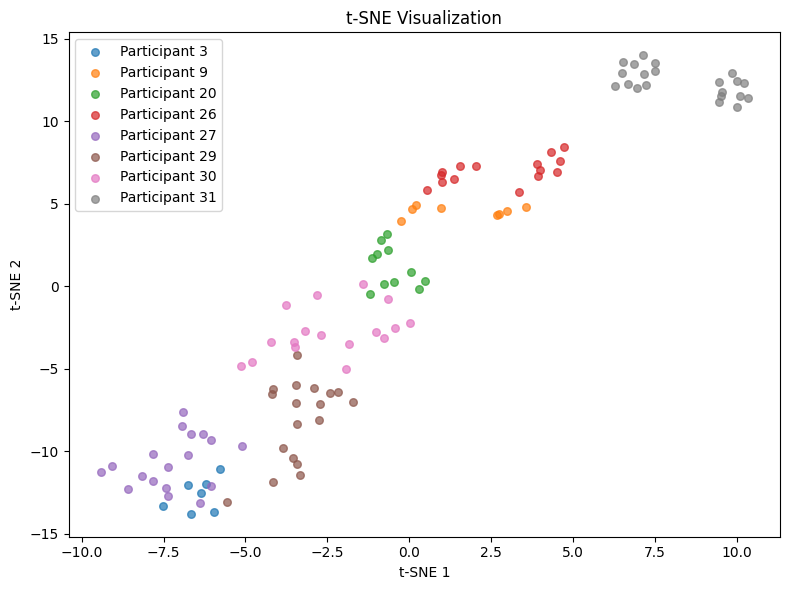

2026-02-06 10:58:56,160 - yolo - INFO - Test set size for rank classification: 115
2026-02-06 10:58:56,162 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 10:58:56,162 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 10:58:56,162 - yolo - INFO - -------------------------------------------------------
2026-02-06 10:58:56,185 - yolo - INFO - k-NN eucl    | 0.8783     | 0.9826     | 0.9913
2026-02-06 10:58:56,204 - yolo - INFO - k-NN manh    | 0.8696     | 0.9913     | 0.9913
2026-02-06 10:58:56,243 - yolo - INFO - SVM          | 0.8348     | 0.9913     | 1.0000
2026-02-06 10:58:57,463 - yolo - INFO - MLP          | 0.8783     | 0.9739     | 1.0000
2026-02-06 10:58:57,485 - yolo - INFO - NB           | 0.8957     | 0.9913     | 1.0000
2026-02-06 10:58:57,534 - yolo - INFO - LR           | 0.8000     | 0.9739     | 1.0000
2026-02-06 10:58:58,136 - yolo - INFO - RF           | 0.8783     | 0.9652     | 1.0000
2026-02-06 10:59:01,758 - yo

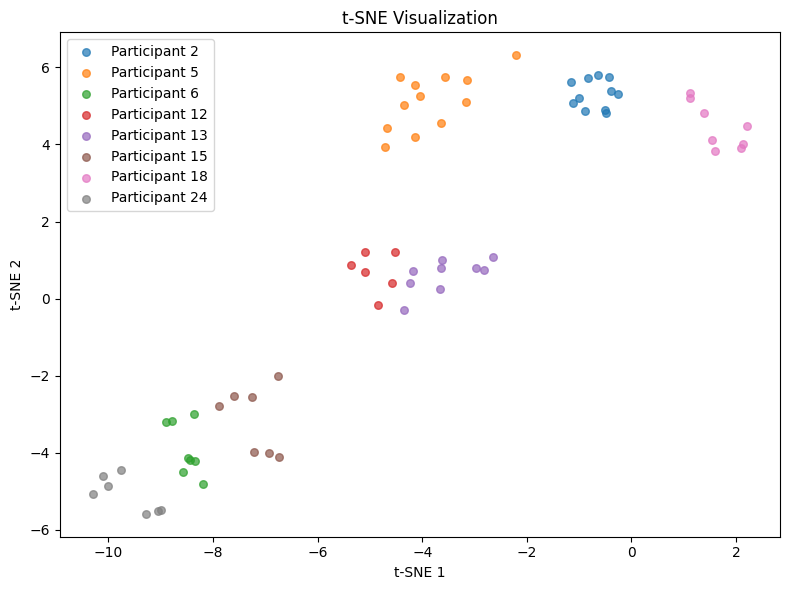

2026-02-06 11:02:16,158 - yolo - INFO - Test set size for rank classification: 68
2026-02-06 11:02:16,159 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 11:02:16,159 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:02:16,160 - yolo - INFO - -------------------------------------------------------
2026-02-06 11:02:16,183 - yolo - INFO - k-NN eucl    | 0.7923     | 0.9571     | 0.9857
2026-02-06 11:02:16,201 - yolo - INFO - k-NN manh    | 0.8363     | 1.0000     | 1.0000
2026-02-06 11:02:16,235 - yolo - INFO - SVM          | 0.9396     | 1.0000     | 1.0000
2026-02-06 11:02:17,025 - yolo - INFO - MLP          | 0.8527     | 0.9714     | 1.0000
2026-02-06 11:02:17,046 - yolo - INFO - NB           | 0.9538     | 0.9692     | 1.0000
2026-02-06 11:02:17,087 - yolo - INFO - LR           | 0.8352     | 0.9703     | 1.0000
2026-02-06 11:02:17,664 - yolo - INFO - RF           | 0.9396     | 1.0000     | 1.0000
2026-02-06 11:02:20,642 - yol

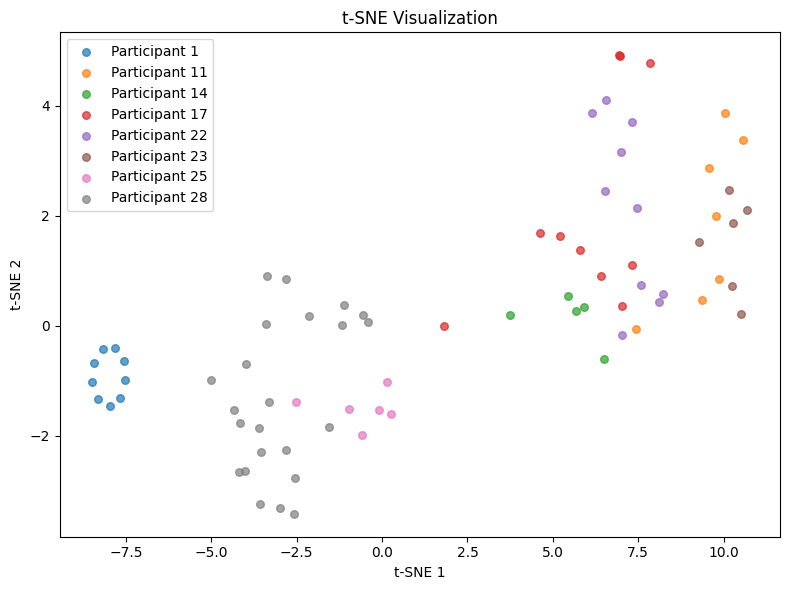

2026-02-06 11:05:10,635 - yolo - INFO - Test set size for rank classification: 76
2026-02-06 11:05:10,636 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 11:05:10,636 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:05:10,637 - yolo - INFO - -------------------------------------------------------
2026-02-06 11:05:10,658 - yolo - INFO - k-NN eucl    | 0.7383     | 0.9100     | 0.9617
2026-02-06 11:05:10,677 - yolo - INFO - k-NN manh    | 0.7383     | 0.9100     | 0.9617
2026-02-06 11:05:10,711 - yolo - INFO - SVM          | 0.8433     | 0.9483     | 0.9742
2026-02-06 11:05:11,756 - yolo - INFO - MLP          | 0.7517     | 0.9350     | 0.9875
2026-02-06 11:05:11,778 - yolo - INFO - NB           | 0.7633     | 0.9358     | 0.9742
2026-02-06 11:05:11,824 - yolo - INFO - LR           | 0.8158     | 0.9750     | 0.9875
2026-02-06 11:05:12,405 - yolo - INFO - RF           | 0.8292     | 0.9358     | 0.9617
2026-02-06 11:05:15,600 - yol

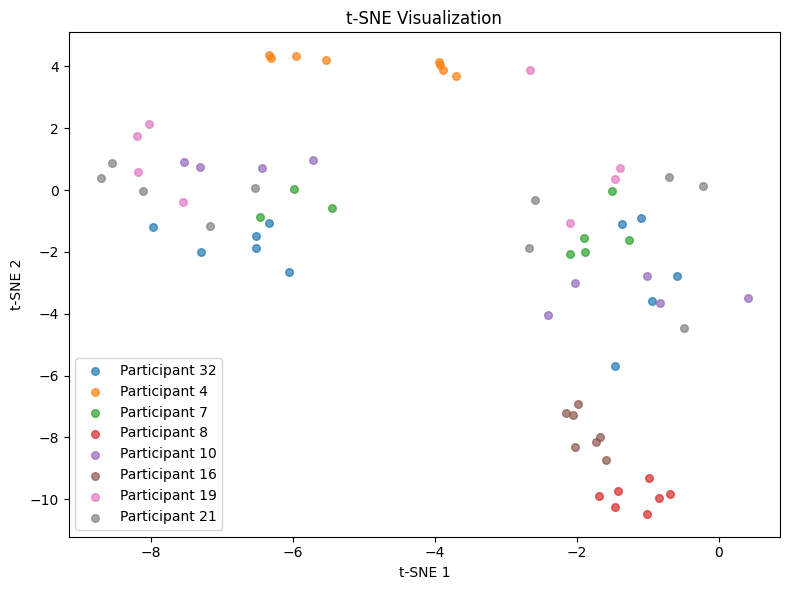

2026-02-06 11:08:28,047 - yolo - INFO - Test set size for rank classification: 68
2026-02-06 11:08:28,048 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 11:08:28,049 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:08:28,050 - yolo - INFO - -------------------------------------------------------
2026-02-06 11:08:28,070 - yolo - INFO - k-NN eucl    | 0.6022     | 0.7648     | 0.8967
2026-02-06 11:08:28,088 - yolo - INFO - k-NN manh    | 0.6165     | 0.7484     | 0.9110
2026-02-06 11:08:28,122 - yolo - INFO - SVM          | 0.5154     | 0.7231     | 0.8659
2026-02-06 11:08:29,136 - yolo - INFO - MLP          | 0.7934     | 0.9121     | 0.9857
2026-02-06 11:08:29,157 - yolo - INFO - NB           | 0.5879     | 0.7055     | 0.8670
2026-02-06 11:08:29,196 - yolo - INFO - LR           | 0.7055     | 0.9110     | 0.9407
2026-02-06 11:08:29,784 - yolo - INFO - RF           | 0.6593     | 0.7923     | 0.8527
2026-02-06 11:08:33,093 - yol

In [8]:
cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "conv1d",
    learning_rate = 1e-6,
    batch_size = 32,
    n_epochs = 150,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-06 11:12:56,590 - yolo - DEBUG - [0] Test fold participants: [27, 26, 20, 29, 31, 3, 30, 9]
2026-02-06 11:12:56,591 - yolo - DEBUG - [0] Train fold participants: [1, 2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 28, 32] 
2026-02-06 11:12:56,592 - yolo - DEBUG - [1] Test fold participants: [6, 12, 13, 15, 2, 18, 5, 24]
2026-02-06 11:12:56,593 - yolo - DEBUG - [1] Train fold participants: [1, 3, 4, 7, 8, 9, 10, 11, 14, 16, 17, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32] 
2026-02-06 11:12:56,593 - yolo - DEBUG - [2] Test fold participants: [11, 23, 17, 25, 14, 22, 28, 1]
2026-02-06 11:12:56,594 - yolo - DEBUG - [2] Train fold participants: [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 15, 16, 18, 19, 20, 21, 24, 26, 27, 29, 30, 31, 32] 
2026-02-06 11:12:56,594 - yolo - DEBUG - [3] Test fold participants: [16, 7, 10, 21, 19, 4, 32, 8]
2026-02-06 11:12:56,595 - yolo - DEBUG - [3] Train fold participants: [1, 2, 3, 5, 6, 9, 11, 12, 13, 14, 15, 17, 18, 2

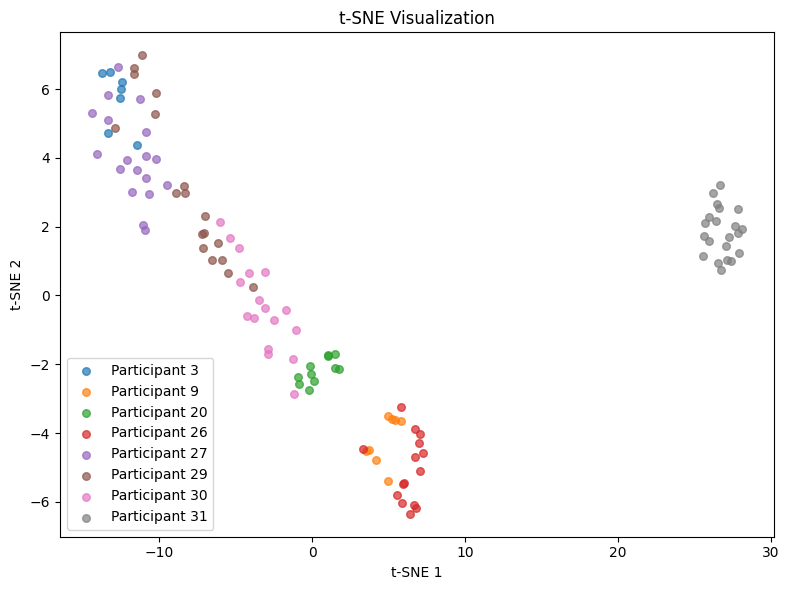

2026-02-06 11:13:36,838 - yolo - INFO - Test set size for rank classification: 115
2026-02-06 11:13:36,839 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 11:13:36,840 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:13:36,840 - yolo - INFO - -------------------------------------------------------
2026-02-06 11:13:36,862 - yolo - INFO - k-NN eucl    | 0.8522     | 0.9478     | 0.9652
2026-02-06 11:13:36,881 - yolo - INFO - k-NN manh    | 0.8609     | 0.9565     | 0.9739
2026-02-06 11:13:36,920 - yolo - INFO - SVM          | 0.8261     | 0.9652     | 0.9913
2026-02-06 11:13:38,143 - yolo - INFO - MLP          | 0.9043     | 0.9826     | 1.0000
2026-02-06 11:13:38,166 - yolo - INFO - NB           | 0.8522     | 1.0000     | 1.0000
2026-02-06 11:13:38,220 - yolo - INFO - LR           | 0.8435     | 0.9652     | 1.0000
2026-02-06 11:13:38,822 - yolo - INFO - RF           | 0.8435     | 0.9652     | 1.0000
2026-02-06 11:13:42,418 - yo

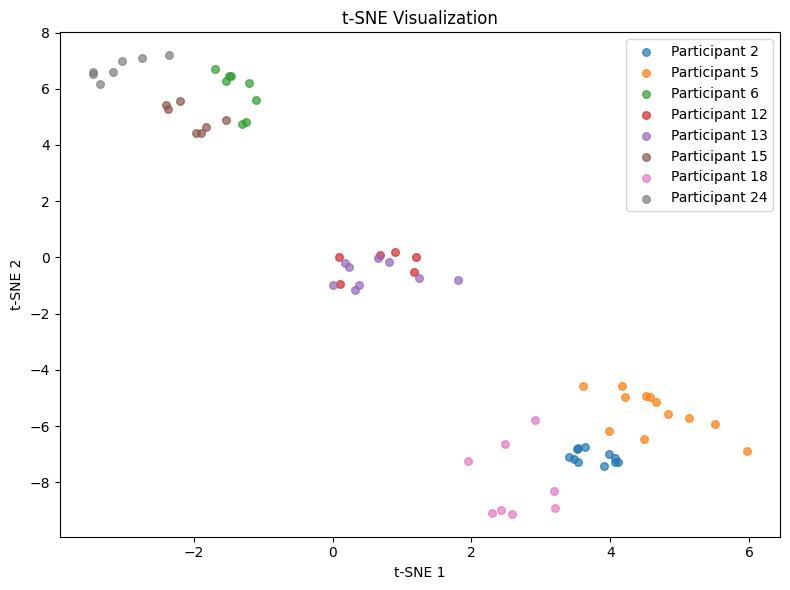

2026-02-06 11:14:48,660 - yolo - INFO - Test set size for rank classification: 68
2026-02-06 11:14:48,661 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 11:14:48,661 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:14:48,662 - yolo - INFO - -------------------------------------------------------
2026-02-06 11:14:48,683 - yolo - INFO - k-NN eucl    | 0.8055     | 0.9549     | 0.9692
2026-02-06 11:14:48,702 - yolo - INFO - k-NN manh    | 0.8066     | 0.9857     | 1.0000
2026-02-06 11:14:48,736 - yolo - INFO - SVM          | 0.8220     | 1.0000     | 1.0000
2026-02-06 11:14:49,623 - yolo - INFO - MLP          | 0.8802     | 0.9857     | 1.0000
2026-02-06 11:14:49,643 - yolo - INFO - NB           | 0.8978     | 1.0000     | 1.0000
2026-02-06 11:14:49,684 - yolo - INFO - LR           | 0.8956     | 1.0000     | 1.0000
2026-02-06 11:14:50,273 - yolo - INFO - RF           | 0.8670     | 0.9857     | 1.0000
2026-02-06 11:14:53,216 - yol

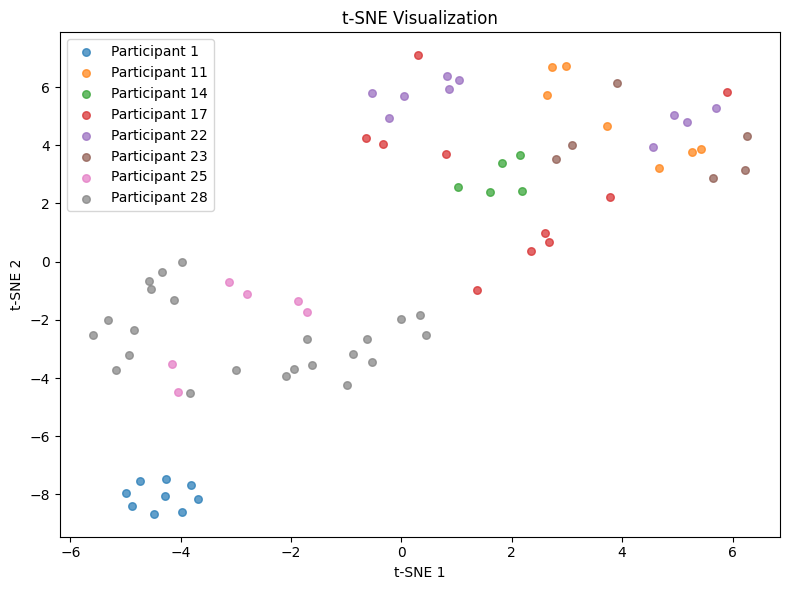

2026-02-06 11:15:50,107 - yolo - INFO - Test set size for rank classification: 76
2026-02-06 11:15:50,108 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 11:15:50,109 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:15:50,109 - yolo - INFO - -------------------------------------------------------
2026-02-06 11:15:50,131 - yolo - INFO - k-NN eucl    | 0.7092     | 0.8808     | 0.9600
2026-02-06 11:15:50,150 - yolo - INFO - k-NN manh    | 0.6692     | 0.8942     | 0.9600
2026-02-06 11:15:50,185 - yolo - INFO - SVM          | 0.7875     | 0.9600     | 1.0000
2026-02-06 11:15:51,089 - yolo - INFO - MLP          | 0.7500     | 0.8942     | 0.9733
2026-02-06 11:15:51,110 - yolo - INFO - NB           | 0.6833     | 0.8825     | 0.9600
2026-02-06 11:15:51,154 - yolo - INFO - LR           | 0.7625     | 0.8942     | 0.9867
2026-02-06 11:15:51,739 - yolo - INFO - RF           | 0.6833     | 0.8950     | 0.9608
2026-02-06 11:15:54,989 - yol

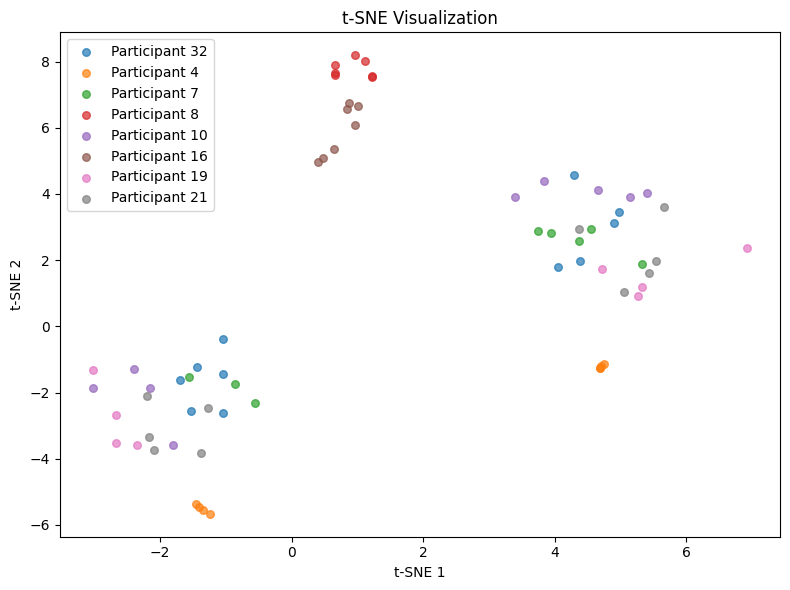

2026-02-06 11:17:00,439 - yolo - INFO - Test set size for rank classification: 68
2026-02-06 11:17:00,440 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 11:17:00,440 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:17:00,441 - yolo - INFO - -------------------------------------------------------
2026-02-06 11:17:00,669 - yolo - INFO - k-NN eucl    | 0.4253     | 0.7198     | 0.8813
2026-02-06 11:17:00,688 - yolo - INFO - k-NN manh    | 0.4703     | 0.7341     | 0.8967
2026-02-06 11:17:00,720 - yolo - INFO - SVM          | 0.4538     | 0.5593     | 0.7670
2026-02-06 11:17:01,779 - yolo - INFO - MLP          | 0.7505     | 0.8363     | 0.9396
2026-02-06 11:17:01,800 - yolo - INFO - NB           | 0.6176     | 0.8495     | 0.9385
2026-02-06 11:17:01,844 - yolo - INFO - LR           | 0.6879     | 0.8374     | 0.9407
2026-02-06 11:17:02,426 - yolo - INFO - RF           | 0.6582     | 0.8198     | 0.9549
2026-02-06 11:17:05,703 - yol

In [10]:
cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "conv1d",
    learning_rate = 1e-5,
    batch_size = 32,
    n_epochs = 50,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-06 11:19:02,683 - yolo - DEBUG - [0] Test fold participants: [27, 26, 20, 29, 31, 3, 30, 9]
2026-02-06 11:19:02,684 - yolo - DEBUG - [0] Train fold participants: [1, 2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 28, 32] 
2026-02-06 11:19:02,684 - yolo - DEBUG - [1] Test fold participants: [6, 12, 13, 15, 2, 18, 5, 24]
2026-02-06 11:19:02,685 - yolo - DEBUG - [1] Train fold participants: [1, 3, 4, 7, 8, 9, 10, 11, 14, 16, 17, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32] 
2026-02-06 11:19:02,685 - yolo - DEBUG - [2] Test fold participants: [11, 23, 17, 25, 14, 22, 28, 1]
2026-02-06 11:19:02,686 - yolo - DEBUG - [2] Train fold participants: [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 15, 16, 18, 19, 20, 21, 24, 26, 27, 29, 30, 31, 32] 
2026-02-06 11:19:02,686 - yolo - DEBUG - [3] Test fold participants: [16, 7, 10, 21, 19, 4, 32, 8]
2026-02-06 11:19:02,687 - yolo - DEBUG - [3] Train fold participants: [1, 2, 3, 5, 6, 9, 11, 12, 13, 14, 15, 17, 18, 2

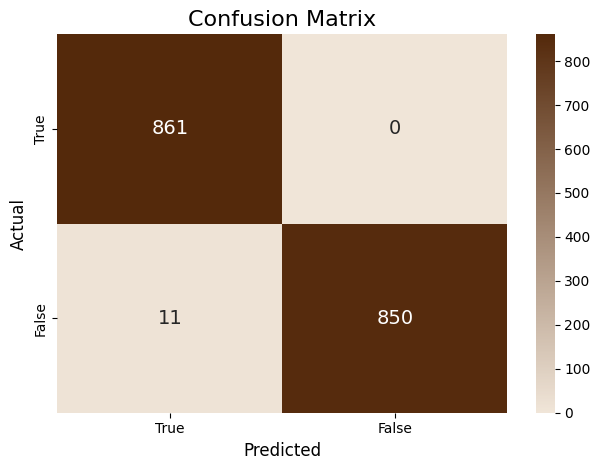

2026-02-06 11:19:45,168 - yolo - INFO - [Iteration 2/4]
2026-02-06 11:19:45,169 - yolo - DEBUG - Test fold participants: [2, 5, 6, 12, 13, 15, 18, 24]
2026-02-06 11:19:45,169 - yolo - DEBUG - Train fold participants: [1, 3, 4, 7, 8, 9, 10, 11, 14, 16, 17, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32]
2026-02-06 11:19:45,211 - yolo - INFO - Train dataset size: 3126
2026-02-06 11:19:45,213 - yolo - INFO - Test dataset size: 540
2026-02-06 11:19:46,441 - yolo - INFO - Epoch 1, Train Loss: 4.223298174082016
2026-02-06 11:19:47,651 - yolo - INFO - Epoch 2, Train Loss: 0.3017673400439778
2026-02-06 11:19:48,974 - yolo - INFO - Epoch 3, Train Loss: 0.11254438126877862
2026-02-06 11:19:50,229 - yolo - INFO - Epoch 4, Train Loss: 0.06890625217739417
2026-02-06 11:19:51,491 - yolo - INFO - Epoch 5, Train Loss: 0.05639812348372474
2026-02-06 11:19:52,726 - yolo - INFO - Epoch 6, Train Loss: 0.045378639229706356
2026-02-06 11:19:54,051 - yolo - INFO - Epoch 7, Train Loss: 0.03989908751100302

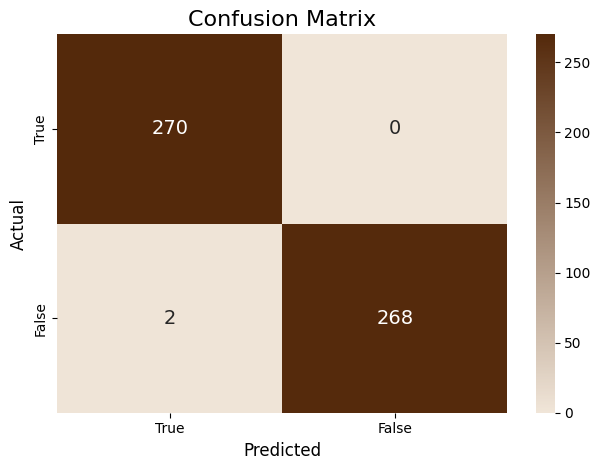

2026-02-06 11:20:50,266 - yolo - INFO - [Iteration 3/4]
2026-02-06 11:20:50,267 - yolo - DEBUG - Test fold participants: [1, 11, 14, 17, 22, 23, 25, 28]
2026-02-06 11:20:50,267 - yolo - DEBUG - Train fold participants: [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 15, 16, 18, 19, 20, 21, 24, 26, 27, 29, 30, 31, 32]
2026-02-06 11:20:50,312 - yolo - INFO - Train dataset size: 2786
2026-02-06 11:20:50,313 - yolo - INFO - Test dataset size: 880
2026-02-06 11:20:51,482 - yolo - INFO - Epoch 1, Train Loss: 1.890922956845977
2026-02-06 11:20:52,608 - yolo - INFO - Epoch 2, Train Loss: 0.24551276236095212
2026-02-06 11:20:53,682 - yolo - INFO - Epoch 3, Train Loss: 0.09145271077498117
2026-02-06 11:20:54,845 - yolo - INFO - Epoch 4, Train Loss: 0.0616023072083904
2026-02-06 11:20:56,106 - yolo - INFO - Epoch 5, Train Loss: 0.04604744066653604
2026-02-06 11:20:57,300 - yolo - INFO - Epoch 6, Train Loss: 0.03770478744991124
2026-02-06 11:20:58,442 - yolo - INFO - Epoch 7, Train Loss: 0.03076035101813349


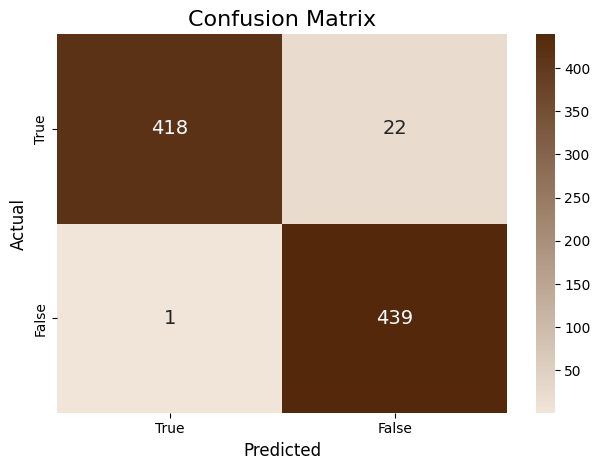

2026-02-06 11:21:49,006 - yolo - INFO - [Iteration 4/4]
2026-02-06 11:21:49,006 - yolo - DEBUG - Test fold participants: [4, 7, 8, 10, 16, 19, 21, 32]
2026-02-06 11:21:49,007 - yolo - DEBUG - Train fold participants: [1, 2, 3, 5, 6, 9, 11, 12, 13, 14, 15, 17, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
2026-02-06 11:21:49,047 - yolo - INFO - Train dataset size: 3142
2026-02-06 11:21:49,048 - yolo - INFO - Test dataset size: 524
2026-02-06 11:21:50,382 - yolo - INFO - Epoch 1, Train Loss: 1.6416997796658315
2026-02-06 11:21:51,684 - yolo - INFO - Epoch 2, Train Loss: 0.15186190955115086
2026-02-06 11:21:53,097 - yolo - INFO - Epoch 3, Train Loss: 0.06669156586356235
2026-02-06 11:21:54,438 - yolo - INFO - Epoch 4, Train Loss: 0.048349708807889864
2026-02-06 11:21:55,712 - yolo - INFO - Epoch 5, Train Loss: 0.03806615246441027
2026-02-06 11:21:56,990 - yolo - INFO - Epoch 6, Train Loss: 0.031216231174767017
2026-02-06 11:21:58,316 - yolo - INFO - Epoch 7, Train Loss: 0.02727569021623

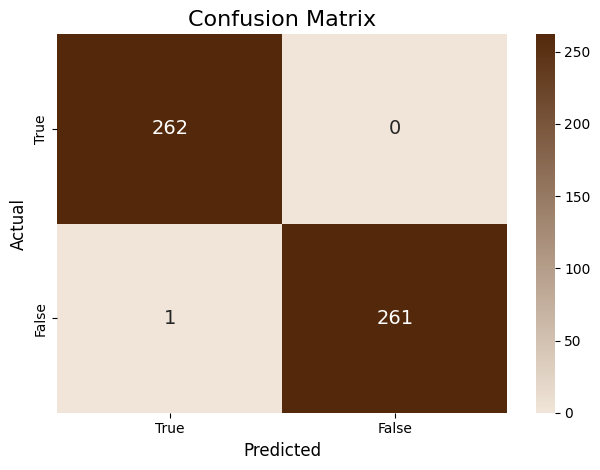

2026-02-06 11:22:54,848 - yolo - INFO - 

2026-02-06 11:22:54,849 - yolo - INFO - Combined evaluation
2026-02-06 11:22:54,849 - yolo - INFO - **************************************************


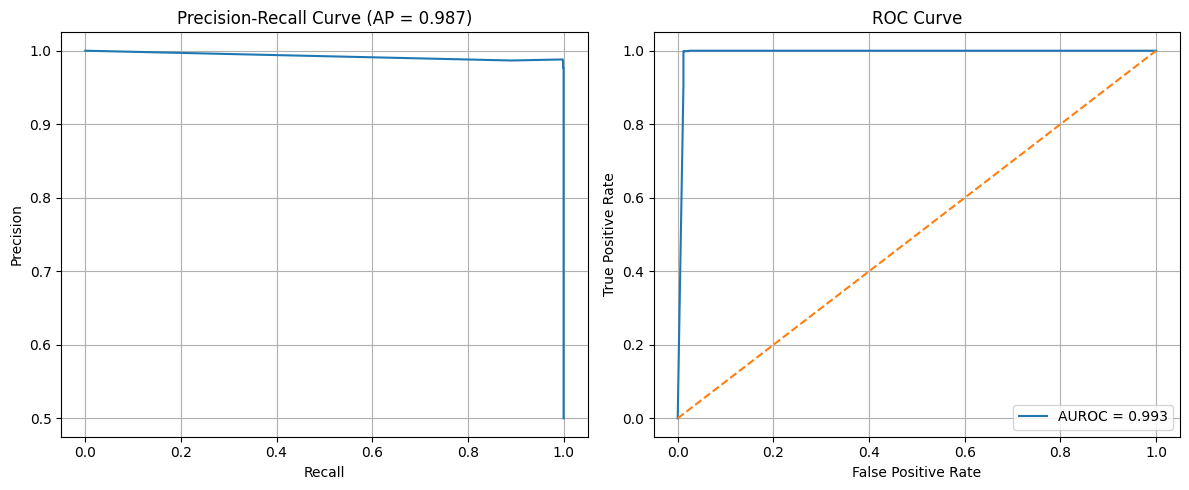

2026-02-06 11:22:55,117 - yolo - INFO - Area under ROC curve: 0.993330434428042
2026-02-06 11:22:55,130 - yolo - INFO - Accuracy: 0.9899072558647026
2026-02-06 11:22:55,131 - yolo - INFO - Precision: 0.9917853231106243
2026-02-06 11:22:55,132 - yolo - INFO - Recall: 0.9879978177850518
2026-02-06 11:22:55,136 - yolo - INFO - Confusion matrix: 
        True  False
True   1811     22
False    15   1818


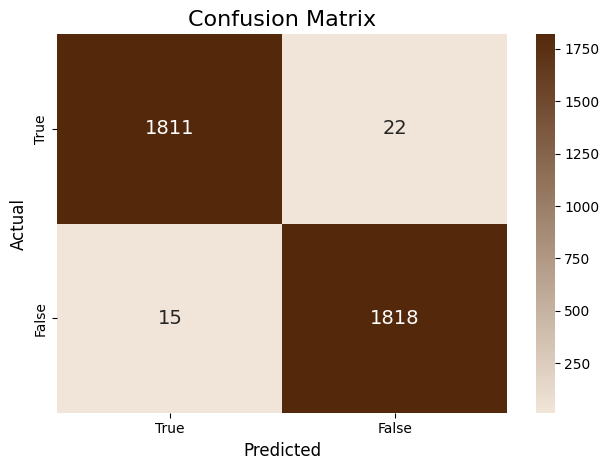

2026-02-06 11:22:55,355 - yolo - INFO - & accuracy & precision &  recall  &   auroc  
2026-02-06 11:22:55,355 - yolo - INFO - & 98.99    & 99.18     & 98.80     & 99.33


(0.9899072558647026, 0.9917853231106243, 0.9879978177850518, 0.993330434428042)

In [11]:
cv.perform_training(
    n_folds = 4,
    siamese_nn_type = "conv1d",
    learning_rate = 1e-5,
    batch_size = 32,
    n_epochs = 50,
    threshold = 0.5,
    show_plot = True, 
)

2026-02-06 11:23:15,117 - yolo_butterworth - INFO - Preparing cycles and participant labels...
2026-02-06 11:23:25,216 - yolo_butterworth - INFO - [Iteration 1/4]
2026-02-06 11:23:25,233 - yolo_butterworth - INFO - Train dataset size: 1642
2026-02-06 11:23:25,891 - yolo_butterworth - INFO - Epoch 1, Train Loss: 4.247038050339772
2026-02-06 11:23:26,546 - yolo_butterworth - INFO - Epoch 2, Train Loss: 0.47739982110663104
2026-02-06 11:23:27,203 - yolo_butterworth - INFO - Epoch 3, Train Loss: 0.19703887431667402
2026-02-06 11:23:27,968 - yolo_butterworth - INFO - Epoch 4, Train Loss: 0.11183807526070338
2026-02-06 11:23:28,674 - yolo_butterworth - INFO - Epoch 5, Train Loss: 0.0844029956139051
2026-02-06 11:23:29,384 - yolo_butterworth - INFO - Epoch 6, Train Loss: 0.07045565216014019
2026-02-06 11:23:30,011 - yolo_butterworth - INFO - Epoch 7, Train Loss: 0.059570522155039586
2026-02-06 11:23:30,665 - yolo_butterworth - INFO - Epoch 8, Train Loss: 0.05443271679373888
2026-02-06 11:23:3

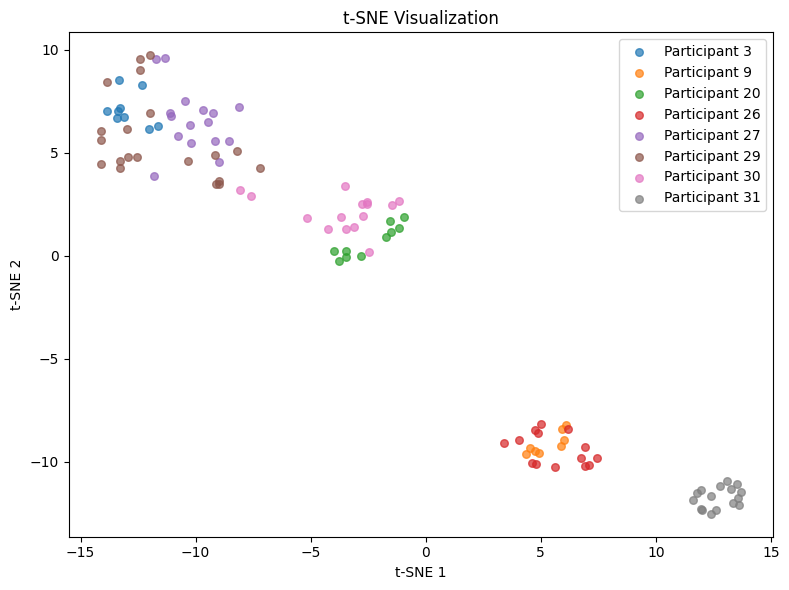

2026-02-06 11:23:59,410 - yolo_butterworth - INFO - Test set size for rank classification: 108
2026-02-06 11:23:59,411 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 11:23:59,412 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:23:59,412 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 11:23:59,432 - yolo_butterworth - INFO - k-NN eucl    | 0.7026     | 0.9251     | 0.9623
2026-02-06 11:23:59,451 - yolo_butterworth - INFO - k-NN manh    | 0.7394     | 0.9346     | 1.0000
2026-02-06 11:23:59,493 - yolo_butterworth - INFO - SVM          | 0.6290     | 0.9169     | 1.0000
2026-02-06 11:24:00,790 - yolo_butterworth - INFO - MLP          | 0.8615     | 0.9719     | 1.0000
2026-02-06 11:24:00,812 - yolo_butterworth - INFO - NB           | 0.7870     | 0.9632     | 1.0000
2026-02-06 11:24:00,865 - yolo_butterworth - INFO - LR           | 0.7134     | 0.9450     | 1.0

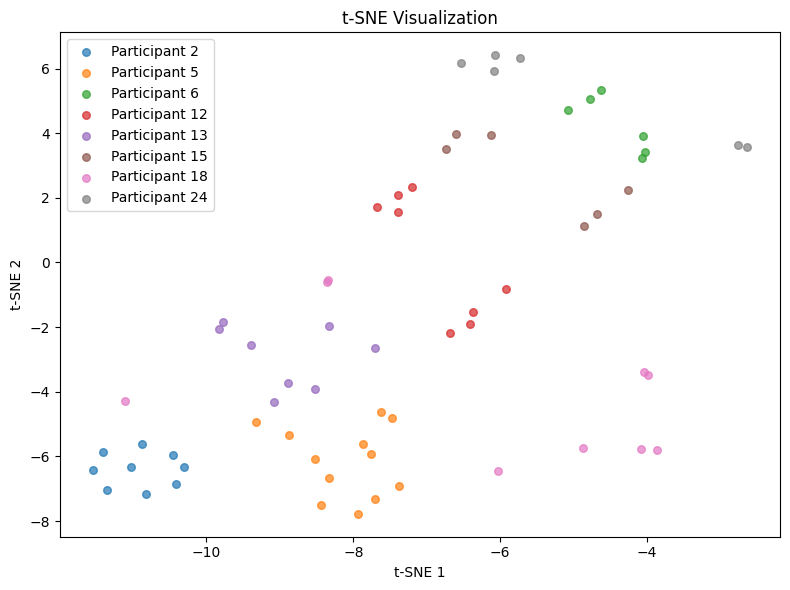

2026-02-06 11:25:00,421 - yolo_butterworth - INFO - Test set size for rank classification: 64
2026-02-06 11:25:00,423 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 11:25:00,423 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:25:00,428 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 11:25:00,452 - yolo_butterworth - INFO - k-NN eucl    | 0.7833     | 0.9692     | 1.0000
2026-02-06 11:25:00,474 - yolo_butterworth - INFO - k-NN manh    | 0.7526     | 0.9846     | 1.0000
2026-02-06 11:25:00,507 - yolo_butterworth - INFO - SVM          | 0.9385     | 0.9846     | 1.0000
2026-02-06 11:25:01,379 - yolo_butterworth - INFO - MLP          | 0.9692     | 1.0000     | 1.0000
2026-02-06 11:25:01,399 - yolo_butterworth - INFO - NB           | 0.9526     | 1.0000     | 1.0000
2026-02-06 11:25:01,442 - yolo_butterworth - INFO - LR           | 0.8897     | 1.0000     | 1.00

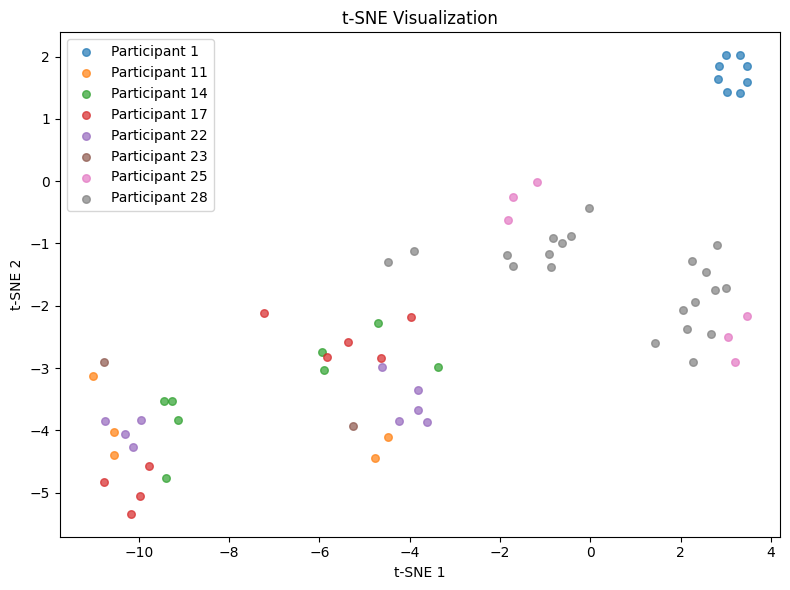

2026-02-06 11:25:54,627 - yolo_butterworth - INFO - Test set size for rank classification: 68
2026-02-06 11:25:54,628 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 11:25:54,628 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:25:54,629 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 11:25:54,649 - yolo_butterworth - INFO - k-NN eucl    | 0.6758     | 0.8527     | 0.9121
2026-02-06 11:25:54,667 - yolo_butterworth - INFO - k-NN manh    | 0.6604     | 0.8835     | 0.9275
2026-02-06 11:25:54,700 - yolo_butterworth - INFO - SVM          | 0.7198     | 0.8385     | 0.9418
2026-02-06 11:25:55,685 - yolo_butterworth - INFO - MLP          | 0.7813     | 0.8835     | 0.9264
2026-02-06 11:25:55,705 - yolo_butterworth - INFO - NB           | 0.6780     | 0.8703     | 0.9429
2026-02-06 11:25:55,760 - yolo_butterworth - INFO - LR           | 0.7923     | 0.9264     | 0.95

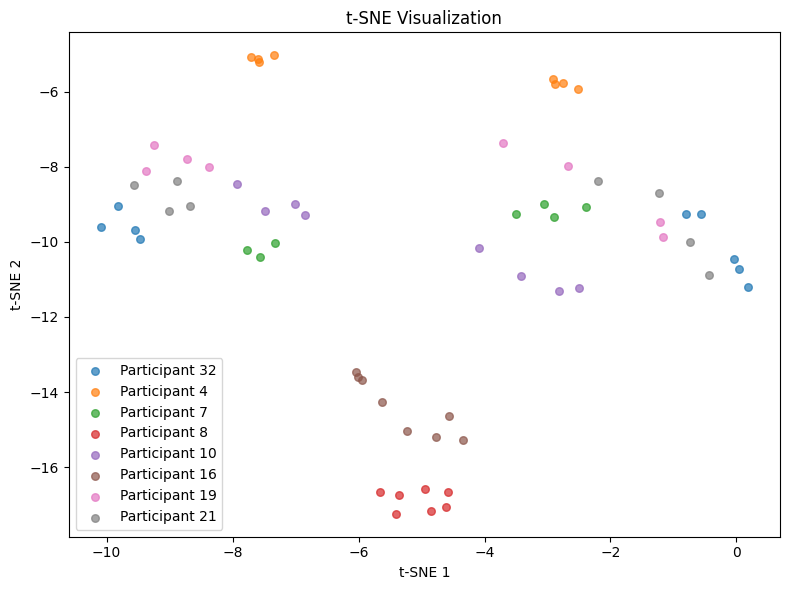

2026-02-06 11:27:02,834 - yolo_butterworth - INFO - Test set size for rank classification: 63
2026-02-06 11:27:02,836 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 11:27:02,836 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:27:02,837 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 11:27:02,858 - yolo_butterworth - INFO - k-NN eucl    | 0.7474     | 0.8897     | 0.9538
2026-02-06 11:27:02,877 - yolo_butterworth - INFO - k-NN manh    | 0.7167     | 0.8744     | 0.9538
2026-02-06 11:27:02,909 - yolo_butterworth - INFO - SVM          | 0.7449     | 0.8256     | 0.9679
2026-02-06 11:27:03,930 - yolo_butterworth - INFO - MLP          | 0.8256     | 0.9513     | 0.9679
2026-02-06 11:27:03,951 - yolo_butterworth - INFO - NB           | 0.6795     | 0.8872     | 0.9692
2026-02-06 11:27:03,987 - yolo_butterworth - INFO - LR           | 0.8410     | 0.9205     | 0.96

In [14]:
cv = CrossValidationSiameseRaw(
    sequence_cycles=yolo_cycles_butterworth, 
    coordinates_idx=CoordinatesIdx(0, 1, 2), 
    log_level=logging.INFO,
    logger_name = 'yolo_butterworth',
)
cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "conv1d",
    learning_rate = 1e-5,
    batch_size = 32,
    n_epochs = 50,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-06 11:27:46,459 - yolo_butterworth - INFO - Preparing cycles and participant labels...
2026-02-06 11:27:56,616 - yolo_butterworth - INFO - [Iteration 1/4]
2026-02-06 11:27:56,634 - yolo_butterworth - INFO - Train dataset size: 1642
2026-02-06 11:27:57,405 - yolo_butterworth - INFO - Epoch 1, Train Loss: 3.3101274577470927
2026-02-06 11:27:58,123 - yolo_butterworth - INFO - Epoch 2, Train Loss: 0.3531671785391294
2026-02-06 11:27:58,810 - yolo_butterworth - INFO - Epoch 3, Train Loss: 0.17401505917167434
2026-02-06 11:27:59,470 - yolo_butterworth - INFO - Epoch 4, Train Loss: 0.10748777065712672
2026-02-06 11:28:00,172 - yolo_butterworth - INFO - Epoch 5, Train Loss: 0.07616649417636487
2026-02-06 11:28:00,833 - yolo_butterworth - INFO - Epoch 6, Train Loss: 0.06220188353640529
2026-02-06 11:28:01,504 - yolo_butterworth - INFO - Epoch 7, Train Loss: 0.05247250192153912
2026-02-06 11:28:02,163 - yolo_butterworth - INFO - Epoch 8, Train Loss: 0.04867190982286747
2026-02-06 11:28:0

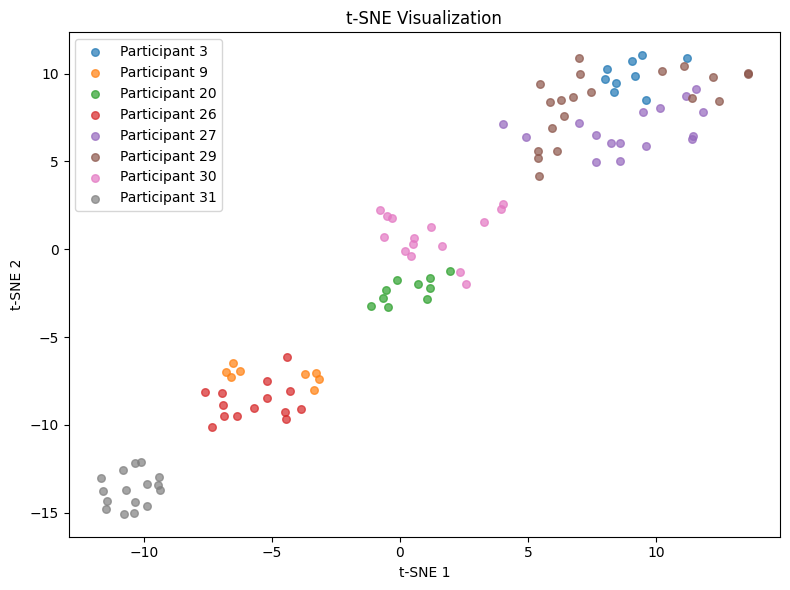

2026-02-06 11:29:07,043 - yolo_butterworth - INFO - Test set size for rank classification: 108
2026-02-06 11:29:07,044 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 11:29:07,045 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:29:07,045 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 11:29:07,067 - yolo_butterworth - INFO - k-NN eucl    | 0.7978     | 0.9442     | 0.9723
2026-02-06 11:29:07,087 - yolo_butterworth - INFO - k-NN manh    | 0.8160     | 0.9351     | 0.9723
2026-02-06 11:29:07,131 - yolo_butterworth - INFO - SVM          | 0.8528     | 0.9632     | 0.9909
2026-02-06 11:29:08,352 - yolo_butterworth - INFO - MLP          | 0.8429     | 0.9723     | 1.0000
2026-02-06 11:29:08,374 - yolo_butterworth - INFO - NB           | 0.8987     | 0.9719     | 1.0000
2026-02-06 11:29:08,422 - yolo_butterworth - INFO - LR           | 0.8061     | 0.9359     | 0.9

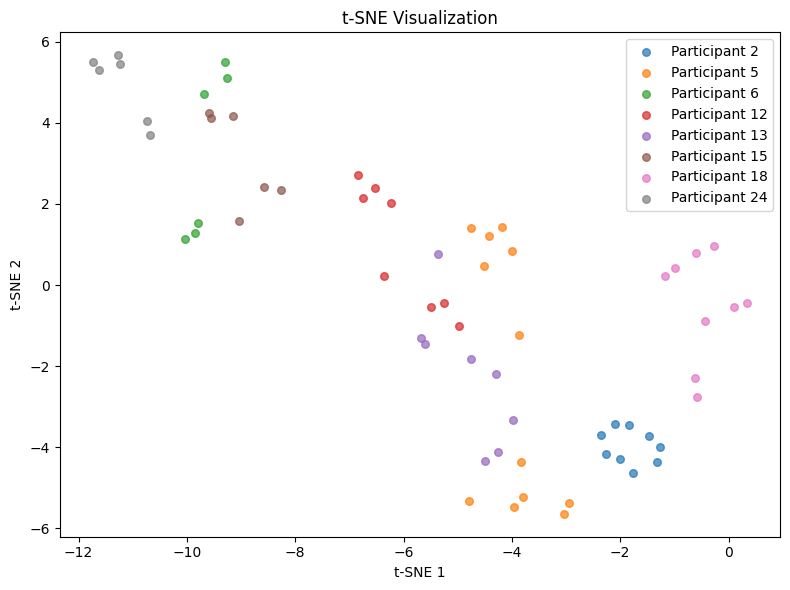

2026-02-06 11:31:00,305 - yolo_butterworth - INFO - Test set size for rank classification: 64
2026-02-06 11:31:00,306 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 11:31:00,306 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:31:00,307 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 11:31:00,328 - yolo_butterworth - INFO - k-NN eucl    | 0.7679     | 0.9064     | 0.9372
2026-02-06 11:31:00,348 - yolo_butterworth - INFO - k-NN manh    | 0.7667     | 0.9538     | 0.9538
2026-02-06 11:31:00,380 - yolo_butterworth - INFO - SVM          | 0.8449     | 0.9846     | 1.0000
2026-02-06 11:31:01,219 - yolo_butterworth - INFO - MLP          | 0.9218     | 0.9833     | 1.0000
2026-02-06 11:31:01,241 - yolo_butterworth - INFO - NB           | 0.8756     | 0.9526     | 0.9833
2026-02-06 11:31:01,280 - yolo_butterworth - INFO - LR           | 0.8910     | 0.9679     | 1.00

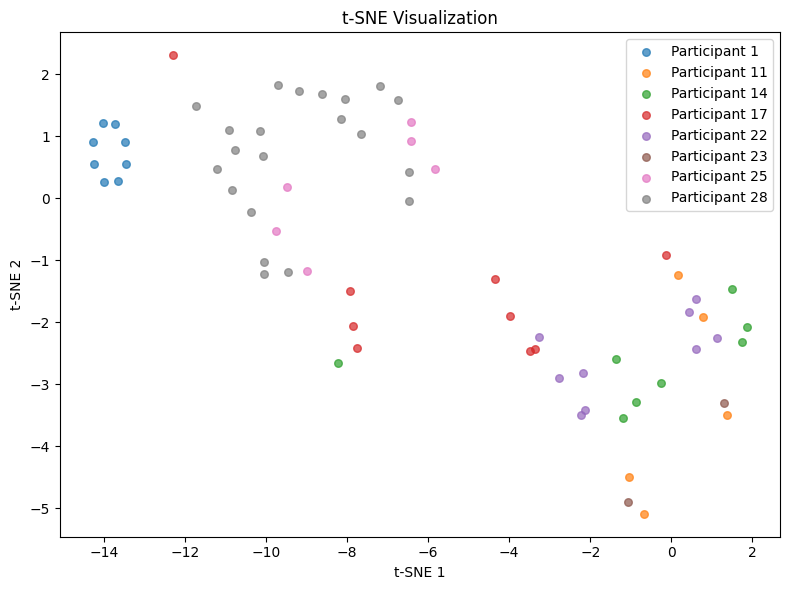

2026-02-06 11:32:41,649 - yolo_butterworth - INFO - Test set size for rank classification: 68
2026-02-06 11:32:41,650 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 11:32:41,650 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:32:41,651 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 11:32:41,673 - yolo_butterworth - INFO - k-NN eucl    | 0.7187     | 0.8681     | 0.8978
2026-02-06 11:32:41,693 - yolo_butterworth - INFO - k-NN manh    | 0.7033     | 0.8681     | 0.8978
2026-02-06 11:32:41,725 - yolo_butterworth - INFO - SVM          | 0.7791     | 0.9264     | 0.9407
2026-02-06 11:32:42,802 - yolo_butterworth - INFO - MLP          | 0.8538     | 0.9275     | 0.9714
2026-02-06 11:32:42,823 - yolo_butterworth - INFO - NB           | 0.7077     | 0.8846     | 0.9571
2026-02-06 11:32:42,865 - yolo_butterworth - INFO - LR           | 0.7945     | 0.9275     | 0.94

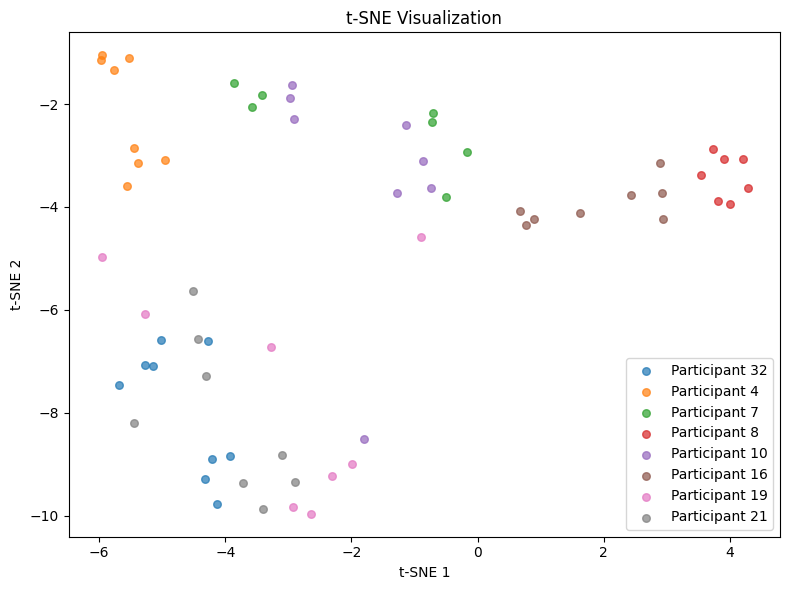

2026-02-06 11:34:34,911 - yolo_butterworth - INFO - Test set size for rank classification: 63
2026-02-06 11:34:34,912 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 11:34:34,912 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:34:34,913 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 11:34:34,935 - yolo_butterworth - INFO - k-NN eucl    | 0.6513     | 0.9218     | 0.9833
2026-02-06 11:34:34,955 - yolo_butterworth - INFO - k-NN manh    | 0.6500     | 0.9192     | 0.9833
2026-02-06 11:34:34,989 - yolo_butterworth - INFO - SVM          | 0.7590     | 0.9192     | 1.0000
2026-02-06 11:34:36,066 - yolo_butterworth - INFO - MLP          | 0.7641     | 0.9218     | 0.9846
2026-02-06 11:34:36,088 - yolo_butterworth - INFO - NB           | 0.7128     | 0.9064     | 0.9679
2026-02-06 11:34:36,133 - yolo_butterworth - INFO - LR           | 0.7321     | 0.9205     | 0.95

In [15]:
cv = CrossValidationSiameseRaw(
    sequence_cycles=yolo_cycles_butterworth, 
    coordinates_idx=CoordinatesIdx(0, 1, 2), 
    log_level=logging.INFO,
    logger_name = 'yolo_butterworth',
)
cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "conv1d",
    learning_rate = 1e-5,
    batch_size = 32,
    n_epochs = 100,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-06 11:35:57,347 - yolo_butterworth - INFO - [Iteration 1/4]
2026-02-06 11:35:57,364 - yolo_butterworth - INFO - Train dataset size: 1642
2026-02-06 11:35:58,071 - yolo_butterworth - INFO - Epoch 1, Train Loss: 16.977725175710823
2026-02-06 11:35:58,841 - yolo_butterworth - INFO - Epoch 2, Train Loss: 13.381352158693167
2026-02-06 11:35:59,521 - yolo_butterworth - INFO - Epoch 3, Train Loss: 10.227799117565155
2026-02-06 11:36:00,197 - yolo_butterworth - INFO - Epoch 4, Train Loss: 7.911335482047154
2026-02-06 11:36:00,876 - yolo_butterworth - INFO - Epoch 5, Train Loss: 5.9921390895660105
2026-02-06 11:36:01,554 - yolo_butterworth - INFO - Epoch 6, Train Loss: 4.577037935073559
2026-02-06 11:36:02,262 - yolo_butterworth - INFO - Epoch 7, Train Loss: 3.4266473788481493
2026-02-06 11:36:02,962 - yolo_butterworth - INFO - Epoch 8, Train Loss: 2.612337513611867
2026-02-06 11:36:03,607 - yolo_butterworth - INFO - Epoch 9, Train Loss: 2.0088282422377515
2026-02-06 11:36:04,294 - yolo

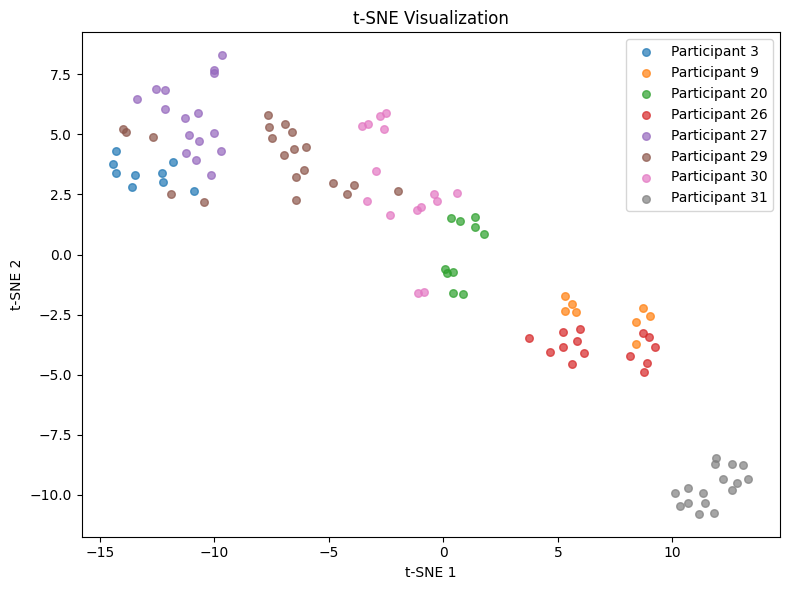

2026-02-06 11:37:05,415 - yolo_butterworth - INFO - Test set size for rank classification: 108
2026-02-06 11:37:05,416 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 11:37:05,417 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:37:05,418 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 11:37:05,440 - yolo_butterworth - INFO - k-NN eucl    | 0.7779     | 0.9446     | 0.9814
2026-02-06 11:37:05,460 - yolo_butterworth - INFO - k-NN manh    | 0.8242     | 0.9723     | 1.0000
2026-02-06 11:37:05,501 - yolo_butterworth - INFO - SVM          | 0.8515     | 0.9814     | 1.0000
2026-02-06 11:37:06,730 - yolo_butterworth - INFO - MLP          | 0.8987     | 0.9719     | 0.9909
2026-02-06 11:37:06,758 - yolo_butterworth - INFO - NB           | 0.9264     | 0.9628     | 1.0000
2026-02-06 11:37:06,811 - yolo_butterworth - INFO - LR           | 0.8429     | 0.9909     | 0.9

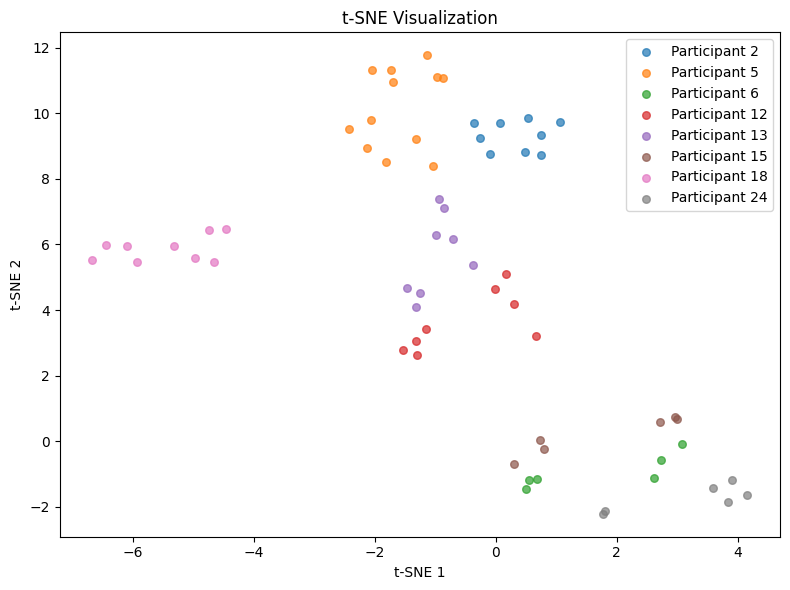

2026-02-06 11:38:58,526 - yolo_butterworth - INFO - Test set size for rank classification: 64
2026-02-06 11:38:58,527 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 11:38:58,527 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:38:58,528 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 11:38:58,549 - yolo_butterworth - INFO - k-NN eucl    | 0.7833     | 0.9231     | 0.9692
2026-02-06 11:38:58,569 - yolo_butterworth - INFO - k-NN manh    | 0.7833     | 0.9538     | 0.9846
2026-02-06 11:38:58,601 - yolo_butterworth - INFO - SVM          | 0.9231     | 0.9692     | 1.0000
2026-02-06 11:38:59,443 - yolo_butterworth - INFO - MLP          | 0.9385     | 0.9692     | 0.9846
2026-02-06 11:38:59,473 - yolo_butterworth - INFO - NB           | 0.9538     | 1.0000     | 1.0000
2026-02-06 11:38:59,515 - yolo_butterworth - INFO - LR           | 0.9231     | 0.9692     | 1.00

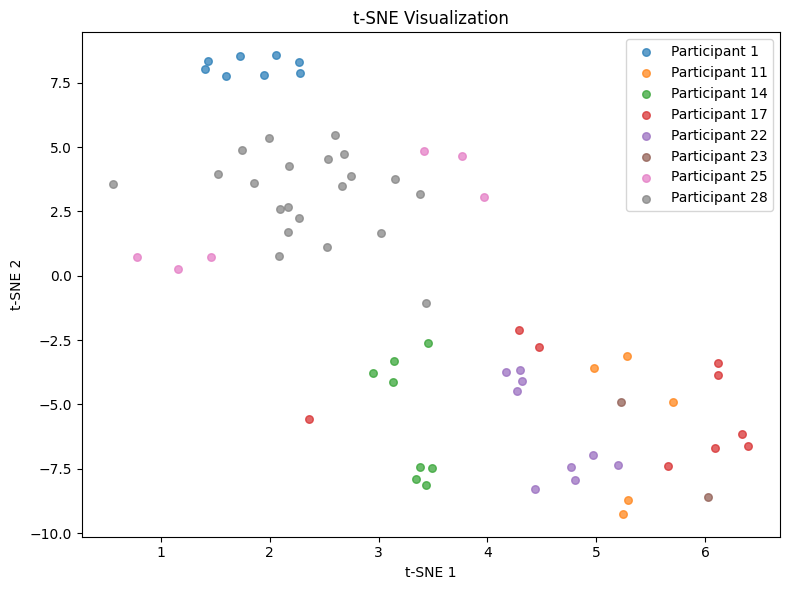

2026-02-06 11:40:40,133 - yolo_butterworth - INFO - Test set size for rank classification: 68
2026-02-06 11:40:40,134 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 11:40:40,134 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:40:40,135 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 11:40:40,157 - yolo_butterworth - INFO - k-NN eucl    | 0.7648     | 0.9275     | 0.9571
2026-02-06 11:40:40,177 - yolo_butterworth - INFO - k-NN manh    | 0.7505     | 0.9275     | 0.9429
2026-02-06 11:40:40,211 - yolo_butterworth - INFO - SVM          | 0.8385     | 0.9571     | 0.9571
2026-02-06 11:40:41,003 - yolo_butterworth - INFO - MLP          | 0.8549     | 0.9418     | 0.9714
2026-02-06 11:40:41,031 - yolo_butterworth - INFO - NB           | 0.7648     | 0.8549     | 0.9571
2026-02-06 11:40:41,074 - yolo_butterworth - INFO - LR           | 0.8396     | 0.9418     | 0.94

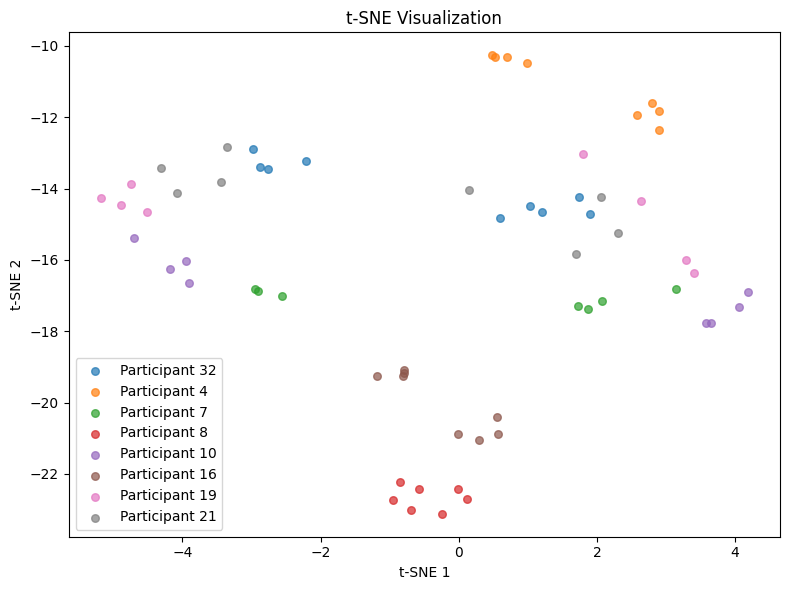

2026-02-06 11:42:35,269 - yolo_butterworth - INFO - Test set size for rank classification: 63
2026-02-06 11:42:35,270 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 11:42:35,271 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:42:35,271 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 11:42:35,292 - yolo_butterworth - INFO - k-NN eucl    | 0.7103     | 0.8705     | 0.9846
2026-02-06 11:42:35,311 - yolo_butterworth - INFO - k-NN manh    | 0.7115     | 0.8872     | 0.9513
2026-02-06 11:42:35,344 - yolo_butterworth - INFO - SVM          | 0.7423     | 0.9026     | 1.0000
2026-02-06 11:42:36,110 - yolo_butterworth - INFO - MLP          | 0.8885     | 0.9513     | 0.9679
2026-02-06 11:42:36,131 - yolo_butterworth - INFO - NB           | 0.7808     | 0.9051     | 0.9526
2026-02-06 11:42:36,169 - yolo_butterworth - INFO - LR           | 0.8885     | 0.9679     | 0.96

In [16]:
cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "conv1d",
    learning_rate = 1e-6,
    batch_size = 32,
    n_epochs = 100,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-06 11:42:50,839 - yolo_butterworth - INFO - [Iteration 1/4]
2026-02-06 11:42:50,856 - yolo_butterworth - INFO - Train dataset size: 1642
2026-02-06 11:42:51,506 - yolo_butterworth - INFO - Epoch 1, Train Loss: 11.27390797321613
2026-02-06 11:42:52,208 - yolo_butterworth - INFO - Epoch 2, Train Loss: 9.343695406730358
2026-02-06 11:42:52,885 - yolo_butterworth - INFO - Epoch 3, Train Loss: 7.6807450881371135
2026-02-06 11:42:53,566 - yolo_butterworth - INFO - Epoch 4, Train Loss: 6.403775912064773
2026-02-06 11:42:54,293 - yolo_butterworth - INFO - Epoch 5, Train Loss: 5.276144401385234
2026-02-06 11:42:54,971 - yolo_butterworth - INFO - Epoch 6, Train Loss: 4.349065487201397
2026-02-06 11:42:55,671 - yolo_butterworth - INFO - Epoch 7, Train Loss: 3.671832875563548
2026-02-06 11:42:56,377 - yolo_butterworth - INFO - Epoch 8, Train Loss: 3.0128863958212047
2026-02-06 11:42:57,030 - yolo_butterworth - INFO - Epoch 9, Train Loss: 2.43833903165964
2026-02-06 11:42:57,716 - yolo_butt

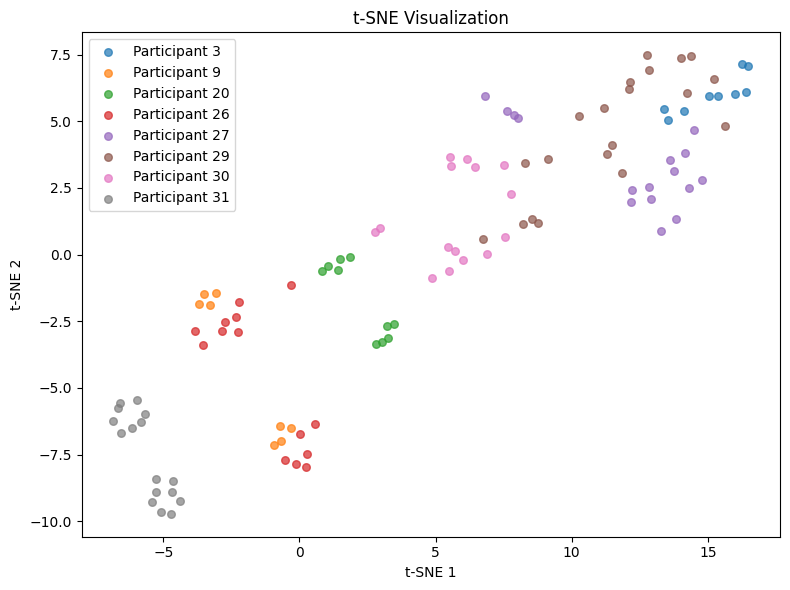

2026-02-06 11:44:32,280 - yolo_butterworth - INFO - Test set size for rank classification: 108
2026-02-06 11:44:32,281 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 11:44:32,281 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:44:32,282 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 11:44:32,303 - yolo_butterworth - INFO - k-NN eucl    | 0.8229     | 0.9905     | 1.0000
2026-02-06 11:44:32,322 - yolo_butterworth - INFO - k-NN manh    | 0.8697     | 0.9714     | 0.9905
2026-02-06 11:44:32,362 - yolo_butterworth - INFO - SVM          | 0.8615     | 0.9727     | 1.0000
2026-02-06 11:44:33,582 - yolo_butterworth - INFO - MLP          | 0.8983     | 1.0000     | 1.0000
2026-02-06 11:44:33,604 - yolo_butterworth - INFO - NB           | 0.9069     | 1.0000     | 1.0000
2026-02-06 11:44:33,648 - yolo_butterworth - INFO - LR           | 0.8333     | 0.9727     | 0.9

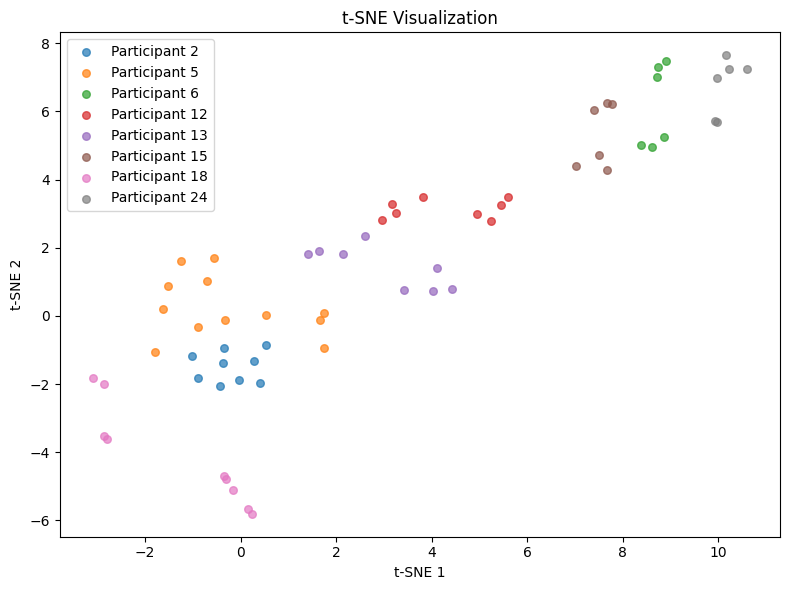

2026-02-06 11:47:18,173 - yolo_butterworth - INFO - Test set size for rank classification: 64
2026-02-06 11:47:18,174 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 11:47:18,175 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:47:18,175 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 11:47:18,197 - yolo_butterworth - INFO - k-NN eucl    | 0.6590     | 0.9077     | 0.9846
2026-02-06 11:47:18,216 - yolo_butterworth - INFO - k-NN manh    | 0.7359     | 0.9692     | 1.0000
2026-02-06 11:47:18,250 - yolo_butterworth - INFO - SVM          | 0.7821     | 0.9846     | 1.0000
2026-02-06 11:47:19,157 - yolo_butterworth - INFO - MLP          | 0.9077     | 0.9846     | 1.0000
2026-02-06 11:47:19,178 - yolo_butterworth - INFO - NB           | 0.9692     | 0.9692     | 1.0000
2026-02-06 11:47:19,222 - yolo_butterworth - INFO - LR           | 0.7974     | 0.9679     | 1.00

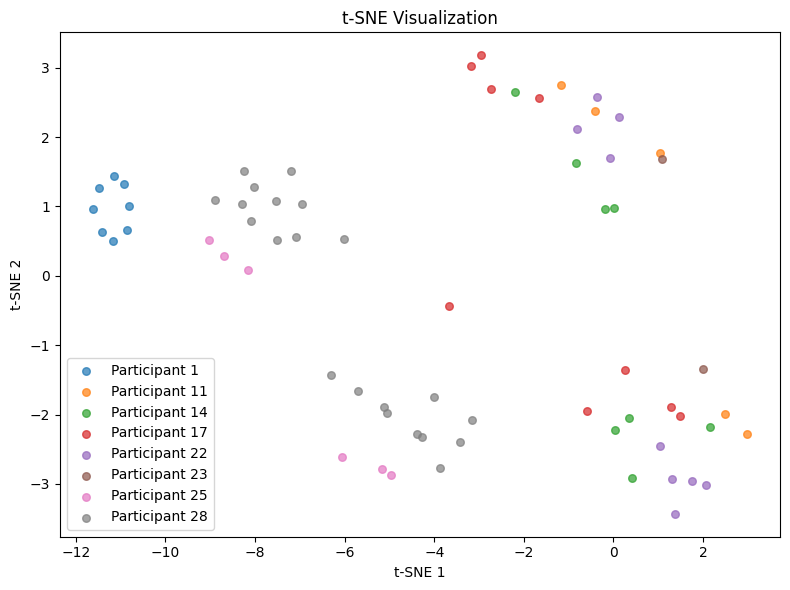

2026-02-06 11:49:48,605 - yolo_butterworth - INFO - Test set size for rank classification: 68
2026-02-06 11:49:48,606 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 11:49:48,607 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:49:48,607 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 11:49:48,629 - yolo_butterworth - INFO - k-NN eucl    | 0.6308     | 0.8231     | 0.8835
2026-02-06 11:49:48,650 - yolo_butterworth - INFO - k-NN manh    | 0.6308     | 0.8231     | 0.8824
2026-02-06 11:49:48,683 - yolo_butterworth - INFO - SVM          | 0.6780     | 0.8681     | 0.8681
2026-02-06 11:49:49,698 - yolo_butterworth - INFO - MLP          | 0.7824     | 0.9132     | 0.9560
2026-02-06 11:49:49,720 - yolo_butterworth - INFO - NB           | 0.7099     | 0.8110     | 0.8978
2026-02-06 11:49:49,762 - yolo_butterworth - INFO - LR           | 0.7956     | 0.8967     | 0.92

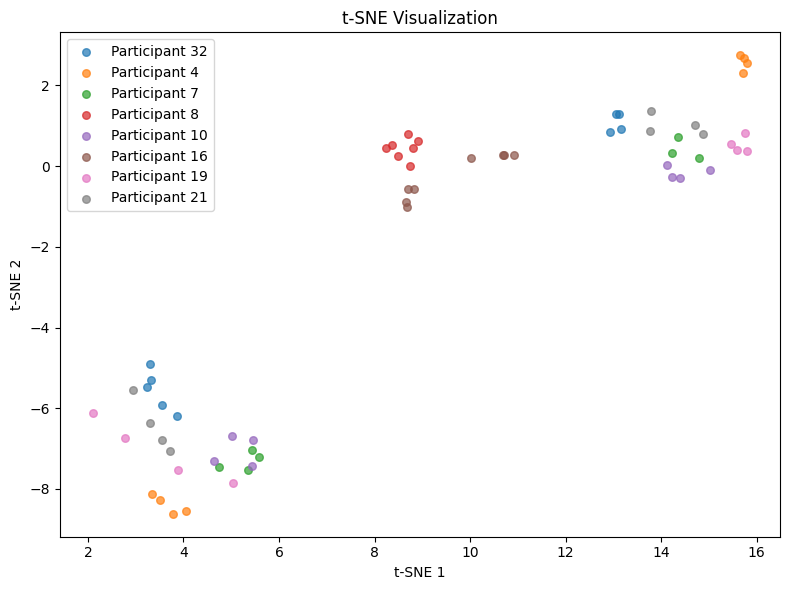

2026-02-06 11:52:35,671 - yolo_butterworth - INFO - Test set size for rank classification: 63
2026-02-06 11:52:35,672 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 11:52:35,673 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 11:52:35,673 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 11:52:35,695 - yolo_butterworth - INFO - k-NN eucl    | 0.6372     | 0.8885     | 0.9833
2026-02-06 11:52:35,714 - yolo_butterworth - INFO - k-NN manh    | 0.6846     | 0.9359     | 0.9833
2026-02-06 11:52:35,747 - yolo_butterworth - INFO - SVM          | 0.6154     | 0.7897     | 0.8846
2026-02-06 11:52:36,548 - yolo_butterworth - INFO - MLP          | 0.9038     | 0.9667     | 1.0000
2026-02-06 11:52:36,569 - yolo_butterworth - INFO - NB           | 0.7141     | 0.8718     | 0.9513
2026-02-06 11:52:36,607 - yolo_butterworth - INFO - LR           | 0.8410     | 0.9513     | 1.00

In [17]:
cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "conv1d",
    learning_rate = 1e-6,
    batch_size = 32,
    n_epochs = 150,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-06 12:06:28,968 - yolo_butterworth - INFO - [Iteration 1/4]
2026-02-06 12:06:28,986 - yolo_butterworth - INFO - Train dataset size: 1642
2026-02-06 12:06:29,529 - yolo_butterworth - INFO - Epoch 1, Train Loss: 15.871281036963829
2026-02-06 12:06:30,074 - yolo_butterworth - INFO - Epoch 2, Train Loss: 13.788032293319702
2026-02-06 12:06:30,674 - yolo_butterworth - INFO - Epoch 3, Train Loss: 12.001665903971745
2026-02-06 12:06:31,241 - yolo_butterworth - INFO - Epoch 4, Train Loss: 10.405937598301815
2026-02-06 12:06:31,826 - yolo_butterworth - INFO - Epoch 5, Train Loss: 8.969008684158325
2026-02-06 12:06:32,383 - yolo_butterworth - INFO - Epoch 6, Train Loss: 7.711269488701453
2026-02-06 12:06:32,933 - yolo_butterworth - INFO - Epoch 7, Train Loss: 6.623177363322331
2026-02-06 12:06:33,477 - yolo_butterworth - INFO - Epoch 8, Train Loss: 5.638314824837905
2026-02-06 12:06:34,028 - yolo_butterworth - INFO - Epoch 9, Train Loss: 4.798811866686894
2026-02-06 12:06:34,567 - yolo_b

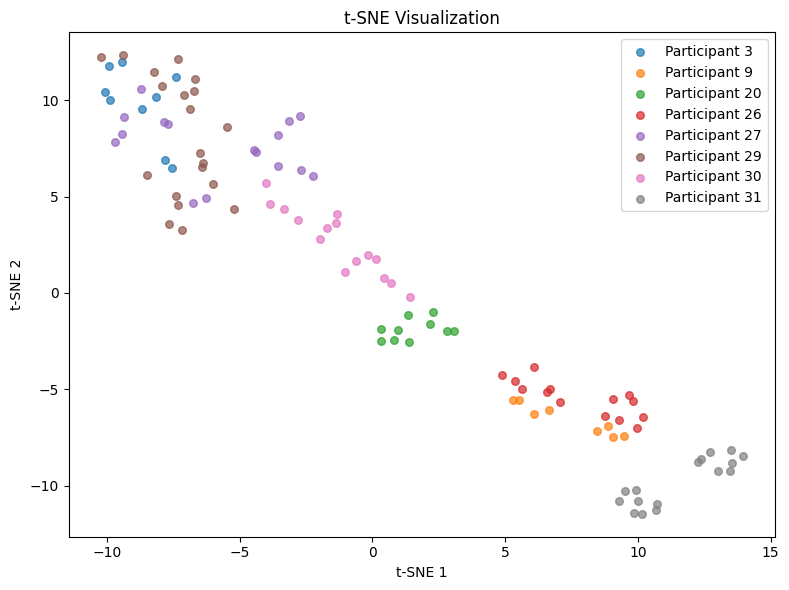

2026-02-06 12:07:12,467 - yolo_butterworth - INFO - Test set size for rank classification: 108
2026-02-06 12:07:12,468 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 12:07:12,469 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 12:07:12,469 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 12:07:12,489 - yolo_butterworth - INFO - k-NN eucl    | 0.7320     | 0.9628     | 0.9909
2026-02-06 12:07:12,508 - yolo_butterworth - INFO - k-NN manh    | 0.7684     | 0.9723     | 1.0000
2026-02-06 12:07:12,549 - yolo_butterworth - INFO - SVM          | 0.7407     | 0.9537     | 1.0000
2026-02-06 12:07:13,773 - yolo_butterworth - INFO - MLP          | 0.8420     | 0.9814     | 1.0000
2026-02-06 12:07:13,794 - yolo_butterworth - INFO - NB           | 0.8065     | 0.9537     | 1.0000
2026-02-06 12:07:13,838 - yolo_butterworth - INFO - LR           | 0.8238     | 0.9636     | 1.0

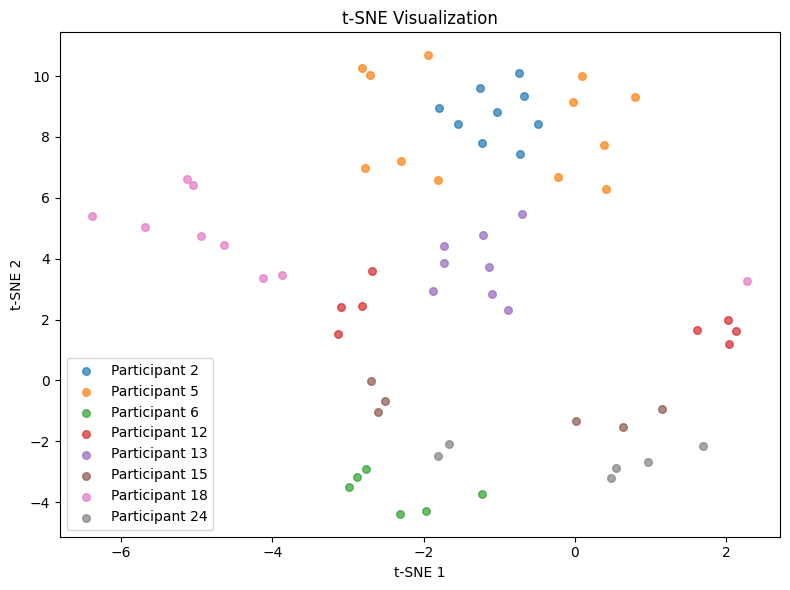

2026-02-06 12:08:26,194 - yolo_butterworth - INFO - Test set size for rank classification: 64
2026-02-06 12:08:26,195 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 12:08:26,196 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 12:08:26,196 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 12:08:26,217 - yolo_butterworth - INFO - k-NN eucl    | 0.7538     | 0.9846     | 1.0000
2026-02-06 12:08:26,238 - yolo_butterworth - INFO - k-NN manh    | 0.7846     | 1.0000     | 1.0000
2026-02-06 12:08:26,271 - yolo_butterworth - INFO - SVM          | 0.9359     | 1.0000     | 1.0000
2026-02-06 12:08:27,277 - yolo_butterworth - INFO - MLP          | 0.9385     | 1.0000     | 1.0000
2026-02-06 12:08:27,297 - yolo_butterworth - INFO - NB           | 0.9231     | 0.9846     | 1.0000
2026-02-06 12:08:27,338 - yolo_butterworth - INFO - LR           | 0.9526     | 1.0000     | 1.00

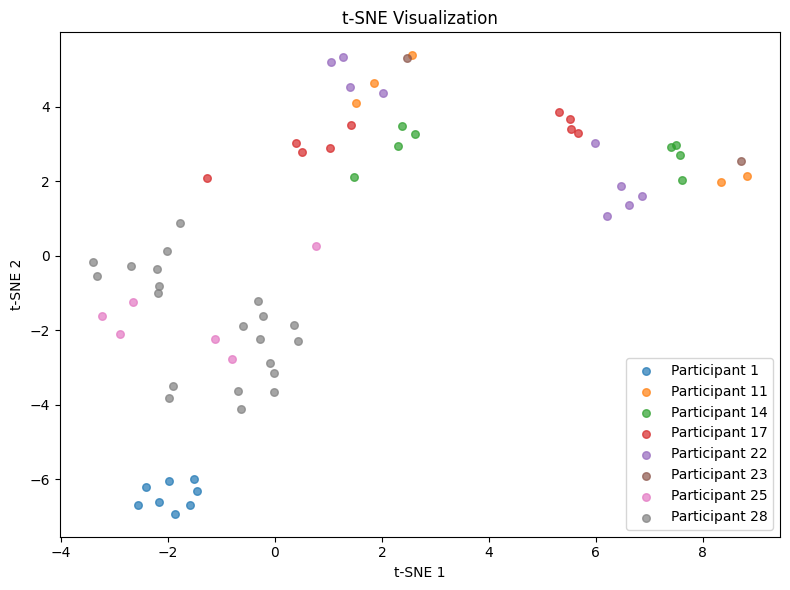

2026-02-06 12:09:32,863 - yolo_butterworth - INFO - Test set size for rank classification: 68
2026-02-06 12:09:32,864 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 12:09:32,865 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 12:09:32,865 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 12:09:32,885 - yolo_butterworth - INFO - k-NN eucl    | 0.7648     | 0.9132     | 0.9418
2026-02-06 12:09:32,906 - yolo_butterworth - INFO - k-NN manh    | 0.7352     | 0.8989     | 0.9132
2026-02-06 12:09:32,939 - yolo_butterworth - INFO - SVM          | 0.7956     | 0.9121     | 0.9560
2026-02-06 12:09:33,795 - yolo_butterworth - INFO - MLP          | 0.8703     | 0.9560     | 0.9857
2026-02-06 12:09:33,815 - yolo_butterworth - INFO - NB           | 0.6912     | 0.8549     | 0.8989
2026-02-06 12:09:33,857 - yolo_butterworth - INFO - LR           | 0.8549     | 0.9560     | 0.98

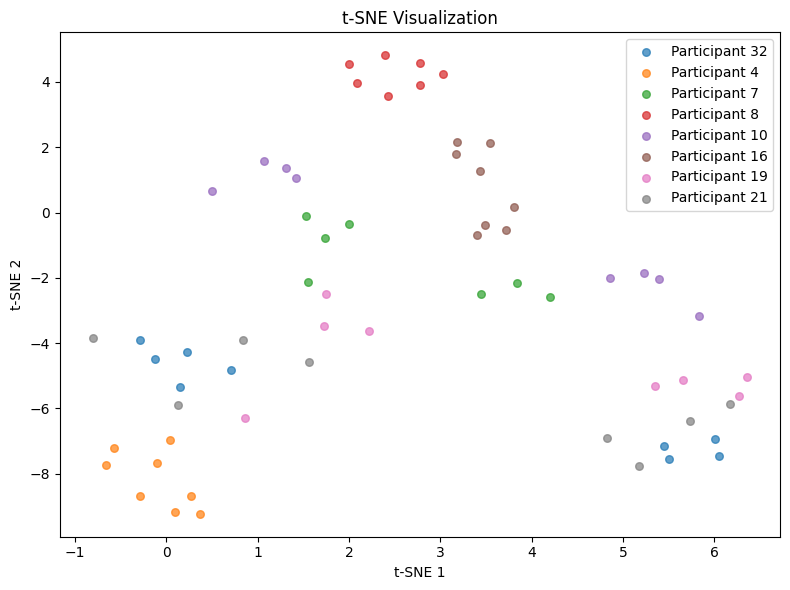

2026-02-06 12:10:44,563 - yolo_butterworth - INFO - Test set size for rank classification: 63
2026-02-06 12:10:44,564 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 12:10:44,564 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 12:10:44,565 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 12:10:44,585 - yolo_butterworth - INFO - k-NN eucl    | 0.8090     | 0.9846     | 1.0000
2026-02-06 12:10:44,604 - yolo_butterworth - INFO - k-NN manh    | 0.7615     | 0.9846     | 1.0000
2026-02-06 12:10:44,636 - yolo_butterworth - INFO - SVM          | 0.8244     | 0.9846     | 1.0000
2026-02-06 12:10:45,495 - yolo_butterworth - INFO - MLP          | 0.8218     | 0.9846     | 0.9846
2026-02-06 12:10:45,515 - yolo_butterworth - INFO - NB           | 0.7590     | 0.9667     | 0.9667
2026-02-06 12:10:45,554 - yolo_butterworth - INFO - LR           | 0.8397     | 0.9692     | 0.98

In [19]:
cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "conv1d",
    learning_rate = 1e-6,
    batch_size = 64,
    n_epochs = 75,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-06 12:11:26,373 - yolo_butterworth - INFO - [Iteration 1/4]
2026-02-06 12:11:26,390 - yolo_butterworth - INFO - Train dataset size: 1642
2026-02-06 12:11:26,911 - yolo_butterworth - INFO - Epoch 1, Train Loss: 4.421683595730708
2026-02-06 12:11:27,453 - yolo_butterworth - INFO - Epoch 2, Train Loss: 4.302148883159344
2026-02-06 12:11:27,975 - yolo_butterworth - INFO - Epoch 3, Train Loss: 4.219148489145132
2026-02-06 12:11:28,501 - yolo_butterworth - INFO - Epoch 4, Train Loss: 4.096452818467067
2026-02-06 12:11:29,028 - yolo_butterworth - INFO - Epoch 5, Train Loss: 4.044774000461285
2026-02-06 12:11:29,531 - yolo_butterworth - INFO - Epoch 6, Train Loss: 3.9514199678714457
2026-02-06 12:11:30,138 - yolo_butterworth - INFO - Epoch 7, Train Loss: 3.872476788667532
2026-02-06 12:11:30,677 - yolo_butterworth - INFO - Epoch 8, Train Loss: 3.7643415331840515
2026-02-06 12:11:31,244 - yolo_butterworth - INFO - Epoch 9, Train Loss: 3.7012770726130557
2026-02-06 12:11:31,790 - yolo_bu

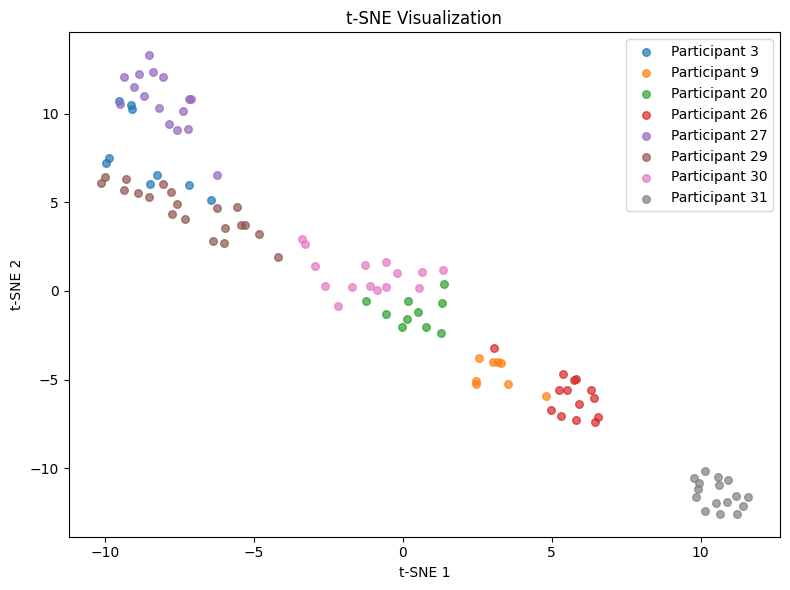

2026-02-06 12:12:47,338 - yolo_butterworth - INFO - Test set size for rank classification: 108
2026-02-06 12:12:47,339 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 12:12:47,339 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 12:12:47,340 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 12:12:47,362 - yolo_butterworth - INFO - k-NN eucl    | 0.8329     | 0.9814     | 1.0000
2026-02-06 12:12:47,381 - yolo_butterworth - INFO - k-NN manh    | 0.8693     | 0.9719     | 0.9905
2026-02-06 12:12:47,421 - yolo_butterworth - INFO - SVM          | 0.8602     | 0.9818     | 1.0000
2026-02-06 12:12:48,637 - yolo_butterworth - INFO - MLP          | 0.8970     | 1.0000     | 1.0000
2026-02-06 12:12:48,661 - yolo_butterworth - INFO - NB           | 0.8701     | 0.9909     | 1.0000
2026-02-06 12:12:48,705 - yolo_butterworth - INFO - LR           | 0.8515     | 0.9632     | 0.9

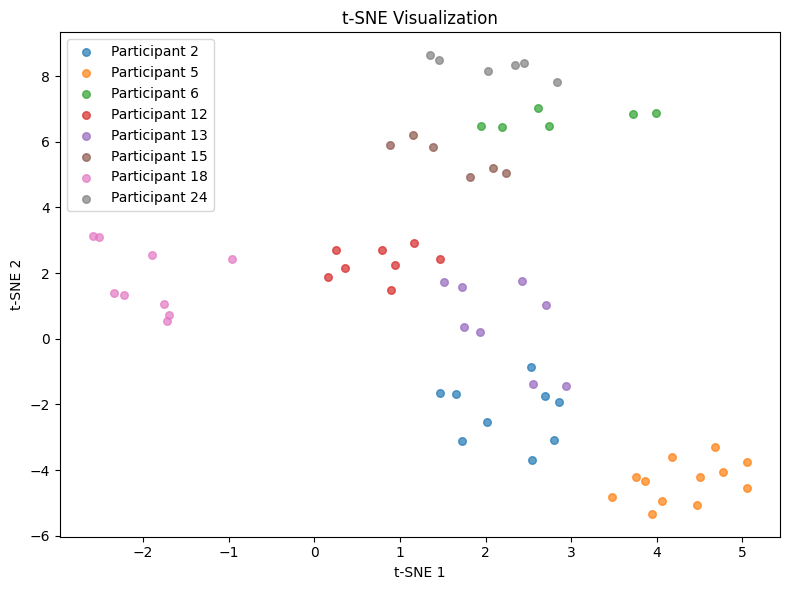

2026-02-06 12:15:00,997 - yolo_butterworth - INFO - Test set size for rank classification: 64
2026-02-06 12:15:00,998 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 12:15:00,999 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 12:15:01,000 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 12:15:01,021 - yolo_butterworth - INFO - k-NN eucl    | 0.8282     | 0.9692     | 0.9846
2026-02-06 12:15:01,040 - yolo_butterworth - INFO - k-NN manh    | 0.8744     | 0.9846     | 1.0000
2026-02-06 12:15:01,073 - yolo_butterworth - INFO - SVM          | 0.8256     | 0.9846     | 1.0000
2026-02-06 12:15:01,915 - yolo_butterworth - INFO - MLP          | 0.9372     | 0.9846     | 1.0000
2026-02-06 12:15:01,936 - yolo_butterworth - INFO - NB           | 0.8897     | 1.0000     | 1.0000
2026-02-06 12:15:01,978 - yolo_butterworth - INFO - LR           | 0.9372     | 0.9846     | 1.00

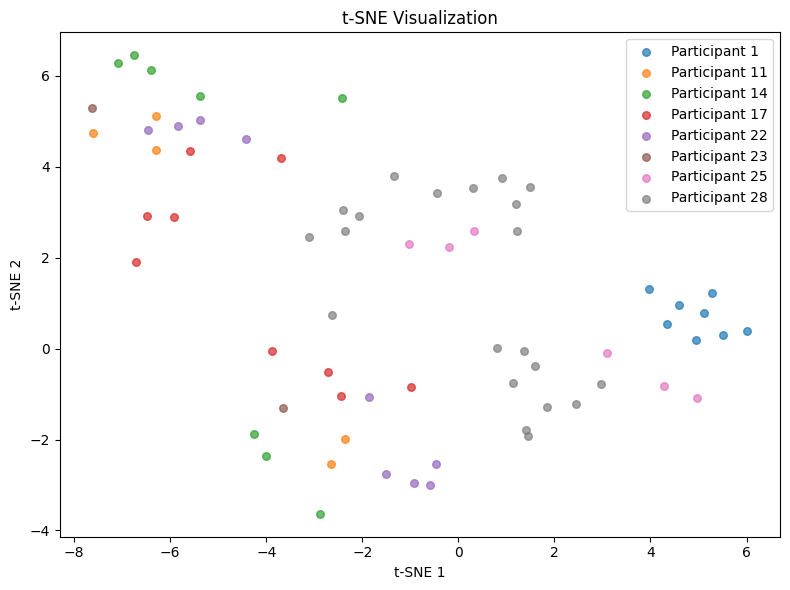

2026-02-06 12:17:01,411 - yolo_butterworth - INFO - Test set size for rank classification: 68
2026-02-06 12:17:01,412 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 12:17:01,413 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 12:17:01,413 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 12:17:01,435 - yolo_butterworth - INFO - k-NN eucl    | 0.7209     | 0.8681     | 0.9275
2026-02-06 12:17:01,455 - yolo_butterworth - INFO - k-NN manh    | 0.7187     | 0.8824     | 0.9132
2026-02-06 12:17:01,488 - yolo_butterworth - INFO - SVM          | 0.7945     | 0.8670     | 0.9264
2026-02-06 12:17:02,418 - yolo_butterworth - INFO - MLP          | 0.8374     | 0.9275     | 0.9571
2026-02-06 12:17:02,440 - yolo_butterworth - INFO - NB           | 0.7516     | 0.8385     | 0.9143
2026-02-06 12:17:02,478 - yolo_butterworth - INFO - LR           | 0.8692     | 0.9275     | 0.97

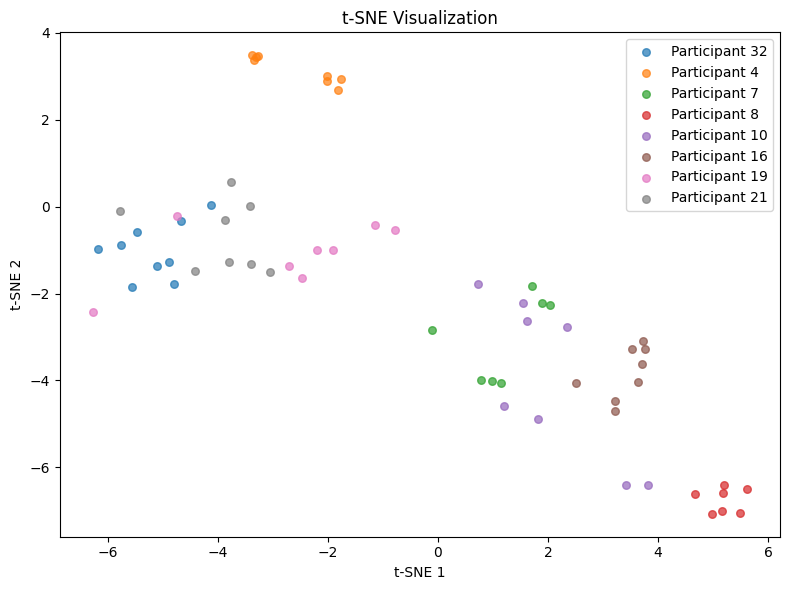

2026-02-06 12:19:15,314 - yolo_butterworth - INFO - Test set size for rank classification: 63
2026-02-06 12:19:15,315 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 12:19:15,315 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 12:19:15,316 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 12:19:15,336 - yolo_butterworth - INFO - k-NN eucl    | 0.7462     | 0.9526     | 1.0000
2026-02-06 12:19:15,356 - yolo_butterworth - INFO - k-NN manh    | 0.7782     | 0.9679     | 1.0000
2026-02-06 12:19:15,388 - yolo_butterworth - INFO - SVM          | 0.8410     | 0.9051     | 1.0000
2026-02-06 12:19:16,183 - yolo_butterworth - INFO - MLP          | 0.8885     | 1.0000     | 1.0000
2026-02-06 12:19:16,204 - yolo_butterworth - INFO - NB           | 0.8282     | 0.9385     | 1.0000
2026-02-06 12:19:16,246 - yolo_butterworth - INFO - LR           | 0.8731     | 0.9359     | 0.98

In [21]:
cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "conv1d",
    learning_rate = 1e-7,
    batch_size = 64,
    n_epochs = 150,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-06 12:20:08,517 - yolo_butterworth - INFO - [Iteration 1/4]
2026-02-06 12:20:08,533 - yolo_butterworth - INFO - Train dataset size: 1642
2026-02-06 12:20:09,074 - yolo_butterworth - INFO - Epoch 1, Train Loss: 10.573570563242985
2026-02-06 12:20:09,618 - yolo_butterworth - INFO - Epoch 2, Train Loss: 10.512807130813599
2026-02-06 12:20:10,163 - yolo_butterworth - INFO - Epoch 3, Train Loss: 10.301144471535316
2026-02-06 12:20:10,698 - yolo_butterworth - INFO - Epoch 4, Train Loss: 10.100318908691406
2026-02-06 12:20:11,282 - yolo_butterworth - INFO - Epoch 5, Train Loss: 9.937966108322144
2026-02-06 12:20:11,845 - yolo_butterworth - INFO - Epoch 6, Train Loss: 9.745562718464779
2026-02-06 12:20:12,407 - yolo_butterworth - INFO - Epoch 7, Train Loss: 9.669548914982723
2026-02-06 12:20:12,951 - yolo_butterworth - INFO - Epoch 8, Train Loss: 9.448039843485905
2026-02-06 12:20:13,473 - yolo_butterworth - INFO - Epoch 9, Train Loss: 9.339908893291767
2026-02-06 12:20:14,046 - yolo_b

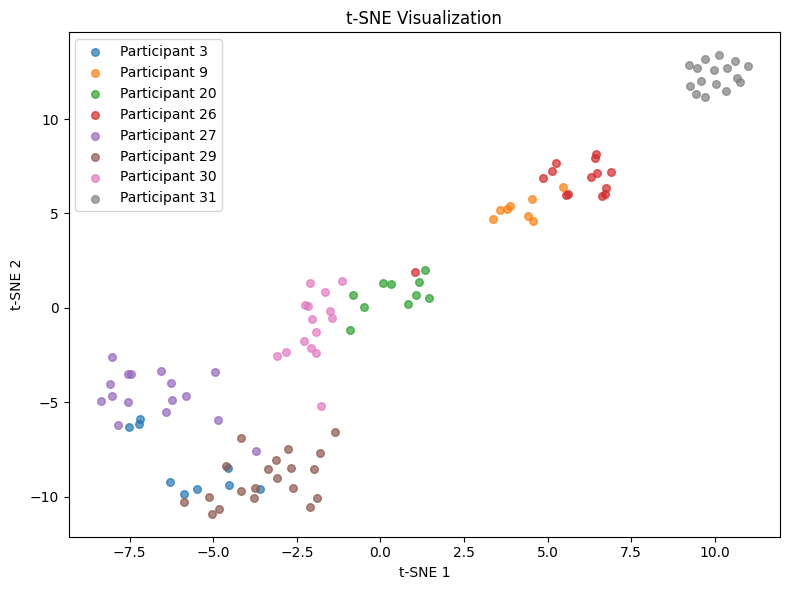

2026-02-06 12:22:24,900 - yolo_butterworth - INFO - Test set size for rank classification: 108
2026-02-06 12:22:24,901 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 12:22:24,902 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 12:22:24,903 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 12:22:24,923 - yolo_butterworth - INFO - k-NN eucl    | 0.8035     | 0.9719     | 0.9905
2026-02-06 12:22:24,943 - yolo_butterworth - INFO - k-NN manh    | 0.8312     | 0.9810     | 0.9810
2026-02-06 12:22:24,982 - yolo_butterworth - INFO - SVM          | 0.8879     | 0.9719     | 1.0000
2026-02-06 12:22:26,197 - yolo_butterworth - INFO - MLP          | 0.9160     | 0.9909     | 1.0000
2026-02-06 12:22:26,218 - yolo_butterworth - INFO - NB           | 0.8788     | 0.9814     | 1.0000
2026-02-06 12:22:26,261 - yolo_butterworth - INFO - LR           | 0.8701     | 0.9723     | 0.9

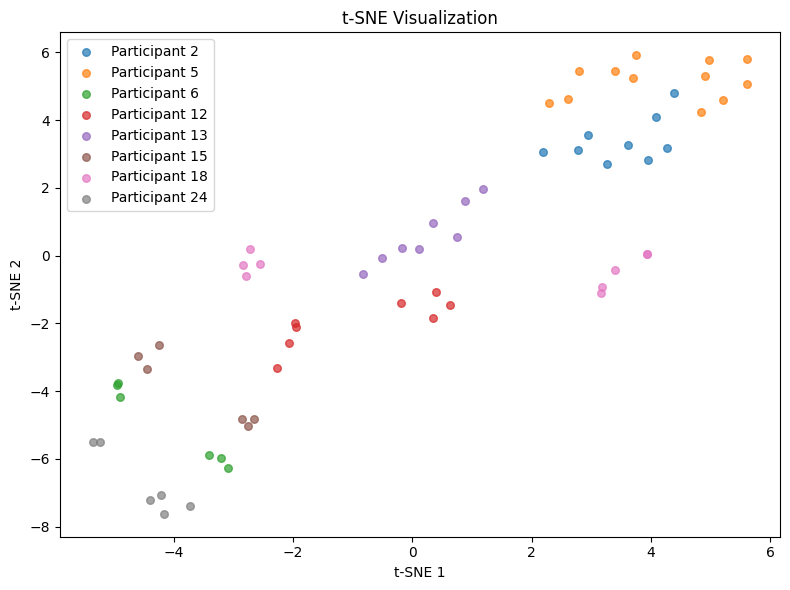

2026-02-06 12:26:06,488 - yolo_butterworth - INFO - Test set size for rank classification: 64
2026-02-06 12:26:06,489 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 12:26:06,490 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 12:26:06,490 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 12:26:06,515 - yolo_butterworth - INFO - k-NN eucl    | 0.7667     | 0.9538     | 0.9692
2026-02-06 12:26:06,537 - yolo_butterworth - INFO - k-NN manh    | 0.7974     | 0.9385     | 0.9692
2026-02-06 12:26:06,572 - yolo_butterworth - INFO - SVM          | 0.9538     | 1.0000     | 1.0000
2026-02-06 12:26:07,399 - yolo_butterworth - INFO - MLP          | 0.9385     | 1.0000     | 1.0000
2026-02-06 12:26:07,420 - yolo_butterworth - INFO - NB           | 0.8769     | 0.9846     | 1.0000
2026-02-06 12:26:07,461 - yolo_butterworth - INFO - LR           | 0.9385     | 1.0000     | 1.00

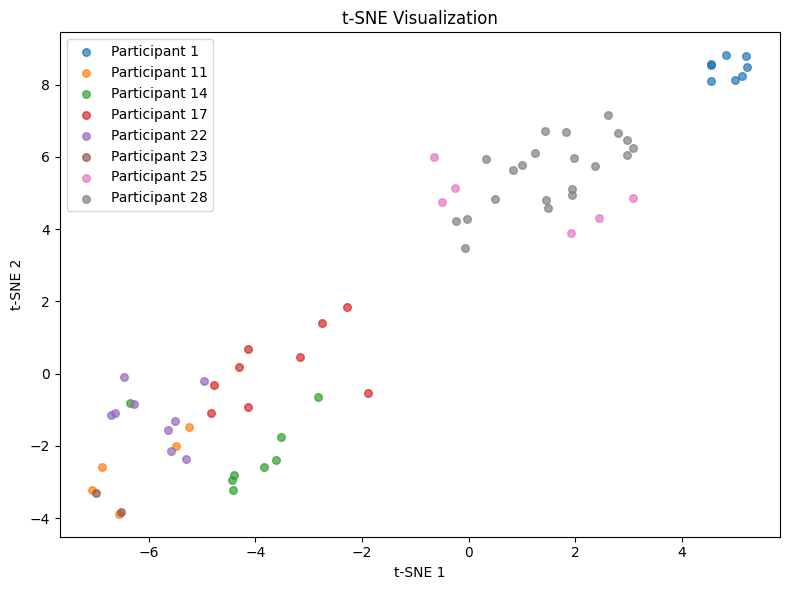

2026-02-06 12:29:24,934 - yolo_butterworth - INFO - Test set size for rank classification: 68
2026-02-06 12:29:24,935 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 12:29:24,935 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 12:29:24,936 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 12:29:24,956 - yolo_butterworth - INFO - k-NN eucl    | 0.7956     | 0.9132     | 0.9714
2026-02-06 12:29:24,975 - yolo_butterworth - INFO - k-NN manh    | 0.7967     | 0.9275     | 0.9560
2026-02-06 12:29:25,006 - yolo_butterworth - INFO - SVM          | 0.8835     | 0.9714     | 0.9714
2026-02-06 12:29:26,008 - yolo_butterworth - INFO - MLP          | 0.8692     | 0.9560     | 0.9703
2026-02-06 12:29:26,029 - yolo_butterworth - INFO - NB           | 0.8396     | 0.9286     | 0.9571
2026-02-06 12:29:26,076 - yolo_butterworth - INFO - LR           | 0.8253     | 0.9571     | 0.97

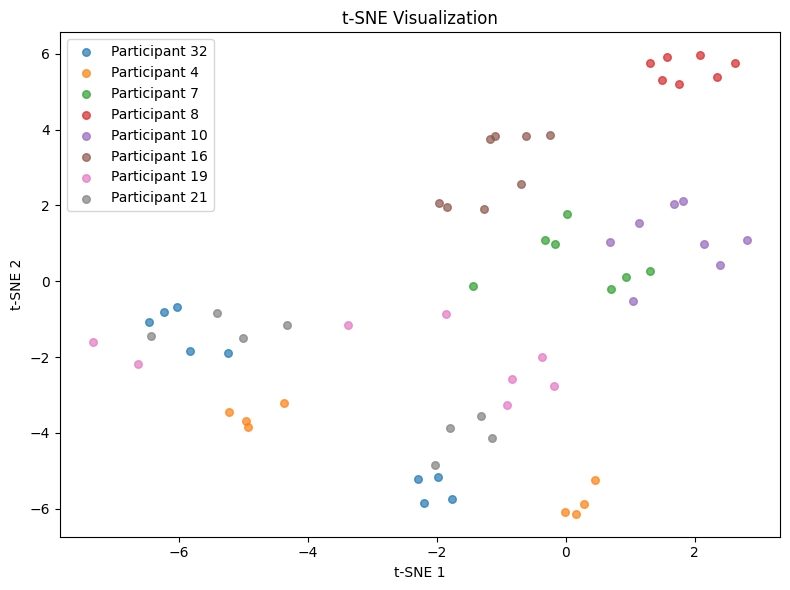

2026-02-06 12:33:03,471 - yolo_butterworth - INFO - Test set size for rank classification: 63
2026-02-06 12:33:03,472 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 12:33:03,473 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 12:33:03,474 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 12:33:03,494 - yolo_butterworth - INFO - k-NN eucl    | 0.7295     | 0.9359     | 0.9846
2026-02-06 12:33:03,512 - yolo_butterworth - INFO - k-NN manh    | 0.7308     | 0.9526     | 0.9846
2026-02-06 12:33:03,544 - yolo_butterworth - INFO - SVM          | 0.6949     | 0.9346     | 1.0000
2026-02-06 12:33:04,469 - yolo_butterworth - INFO - MLP          | 0.7936     | 0.9692     | 1.0000
2026-02-06 12:33:04,489 - yolo_butterworth - INFO - NB           | 0.8269     | 0.8885     | 0.9833
2026-02-06 12:33:04,526 - yolo_butterworth - INFO - LR           | 0.7923     | 0.9526     | 1.00

In [22]:
cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "conv1d",
    learning_rate = 1e-7,
    batch_size = 64,
    n_epochs = 250,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-06 12:39:34,033 - yolo_butterworth - INFO - [Iteration 1/4]
2026-02-06 12:39:34,050 - yolo_butterworth - INFO - Train dataset size: 1642
2026-02-06 12:39:34,627 - yolo_butterworth - INFO - Epoch 1, Train Loss: 8.691270149671114
2026-02-06 12:39:35,195 - yolo_butterworth - INFO - Epoch 2, Train Loss: 8.558538895386915
2026-02-06 12:39:35,753 - yolo_butterworth - INFO - Epoch 3, Train Loss: 8.440669719989483
2026-02-06 12:39:36,302 - yolo_butterworth - INFO - Epoch 4, Train Loss: 8.347572345000048
2026-02-06 12:39:36,865 - yolo_butterworth - INFO - Epoch 5, Train Loss: 8.212732205024132
2026-02-06 12:39:37,420 - yolo_butterworth - INFO - Epoch 6, Train Loss: 8.164533615112305
2026-02-06 12:39:38,049 - yolo_butterworth - INFO - Epoch 7, Train Loss: 7.975374240141648
2026-02-06 12:39:38,682 - yolo_butterworth - INFO - Epoch 8, Train Loss: 7.869558426050039
2026-02-06 12:39:39,362 - yolo_butterworth - INFO - Epoch 9, Train Loss: 7.781473948405339
2026-02-06 12:39:40,119 - yolo_butte

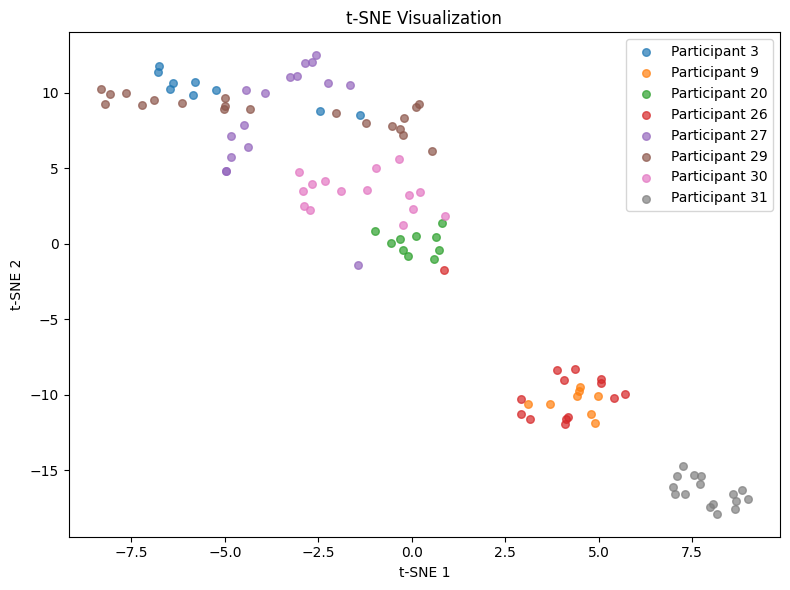

2026-02-06 12:43:14,407 - yolo_butterworth - INFO - Test set size for rank classification: 108
2026-02-06 12:43:14,408 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 12:43:14,409 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 12:43:14,409 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 12:43:14,432 - yolo_butterworth - INFO - k-NN eucl    | 0.7857     | 0.9342     | 0.9905
2026-02-06 12:43:14,451 - yolo_butterworth - INFO - k-NN manh    | 0.7680     | 0.9619     | 0.9905
2026-02-06 12:43:14,490 - yolo_butterworth - INFO - SVM          | 0.7957     | 0.9628     | 1.0000
2026-02-06 12:43:15,714 - yolo_butterworth - INFO - MLP          | 0.8784     | 0.9719     | 1.0000
2026-02-06 12:43:15,735 - yolo_butterworth - INFO - NB           | 0.8701     | 0.9723     | 1.0000
2026-02-06 12:43:15,792 - yolo_butterworth - INFO - LR           | 0.7680     | 0.9537     | 1.0

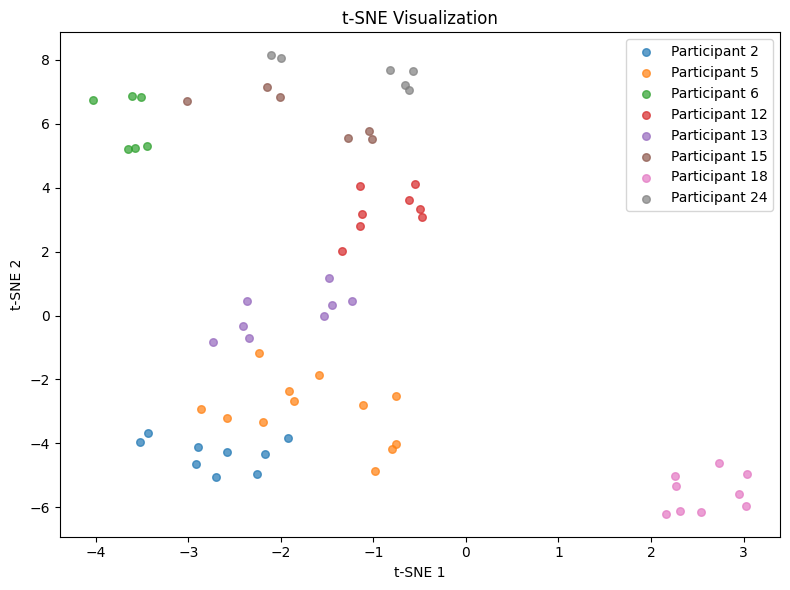

2026-02-06 12:49:07,949 - yolo_butterworth - INFO - Test set size for rank classification: 64
2026-02-06 12:49:07,950 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 12:49:07,951 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 12:49:07,952 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 12:49:07,971 - yolo_butterworth - INFO - k-NN eucl    | 0.8282     | 0.9385     | 0.9846
2026-02-06 12:49:07,990 - yolo_butterworth - INFO - k-NN manh    | 0.8141     | 0.9538     | 0.9846
2026-02-06 12:49:08,023 - yolo_butterworth - INFO - SVM          | 0.9372     | 1.0000     | 1.0000
2026-02-06 12:49:08,845 - yolo_butterworth - INFO - MLP          | 0.9372     | 1.0000     | 1.0000
2026-02-06 12:49:08,866 - yolo_butterworth - INFO - NB           | 0.9051     | 1.0000     | 1.0000
2026-02-06 12:49:08,909 - yolo_butterworth - INFO - LR           | 0.9846     | 1.0000     | 1.00

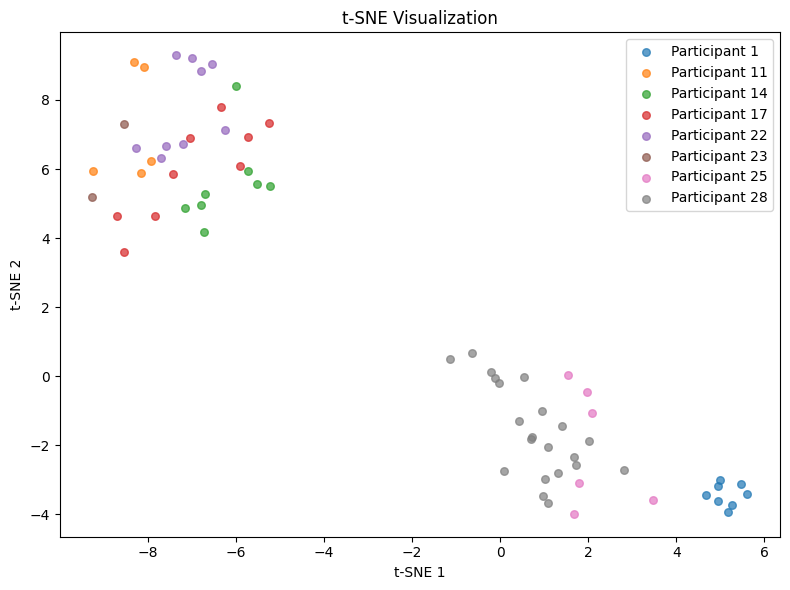

2026-02-06 12:54:28,800 - yolo_butterworth - INFO - Test set size for rank classification: 68
2026-02-06 12:54:28,801 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 12:54:28,802 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 12:54:28,803 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 12:54:28,823 - yolo_butterworth - INFO - k-NN eucl    | 0.7648     | 0.8824     | 0.9275
2026-02-06 12:54:28,843 - yolo_butterworth - INFO - k-NN manh    | 0.6780     | 0.8527     | 0.9275
2026-02-06 12:54:28,876 - yolo_butterworth - INFO - SVM          | 0.6769     | 0.8538     | 0.8967
2026-02-06 12:54:29,790 - yolo_butterworth - INFO - MLP          | 0.8264     | 0.9418     | 0.9560
2026-02-06 12:54:29,810 - yolo_butterworth - INFO - NB           | 0.7516     | 0.8967     | 0.9571
2026-02-06 12:54:29,852 - yolo_butterworth - INFO - LR           | 0.8549     | 0.9418     | 0.98

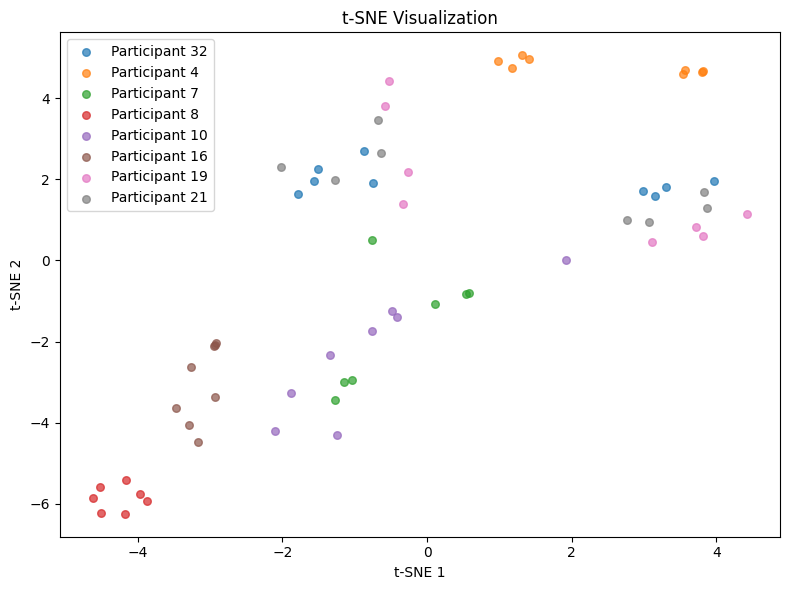

2026-02-06 13:00:27,510 - yolo_butterworth - INFO - Test set size for rank classification: 63
2026-02-06 13:00:27,511 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 13:00:27,512 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 13:00:27,512 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 13:00:27,534 - yolo_butterworth - INFO - k-NN eucl    | 0.7154     | 0.9526     | 0.9846
2026-02-06 13:00:27,553 - yolo_butterworth - INFO - k-NN manh    | 0.6667     | 0.9372     | 1.0000
2026-02-06 13:00:27,587 - yolo_butterworth - INFO - SVM          | 0.7603     | 0.9679     | 0.9846
2026-02-06 13:00:28,367 - yolo_butterworth - INFO - MLP          | 0.9179     | 0.9846     | 0.9846
2026-02-06 13:00:28,389 - yolo_butterworth - INFO - NB           | 0.7115     | 0.9359     | 0.9526
2026-02-06 13:00:28,430 - yolo_butterworth - INFO - LR           | 0.8885     | 0.9679     | 0.98

In [24]:
cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "conv1d",
    learning_rate = 1e-7,
    batch_size = 64,
    n_epochs = 400,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-06 16:36:57,614 - yolo_butterworth - INFO - [Iteration 1/4]
2026-02-06 16:36:57,632 - yolo_butterworth - INFO - Train dataset size: 1642
2026-02-06 16:36:58,150 - yolo_butterworth - INFO - Epoch 1, Train Loss: 3.595156119419978
2026-02-06 16:36:58,668 - yolo_butterworth - INFO - Epoch 2, Train Loss: 3.2766470175523024
2026-02-06 16:36:59,168 - yolo_butterworth - INFO - Epoch 3, Train Loss: 2.971845113314115
2026-02-06 16:36:59,666 - yolo_butterworth - INFO - Epoch 4, Train Loss: 2.6985317652042093
2026-02-06 16:37:00,173 - yolo_butterworth - INFO - Epoch 5, Train Loss: 2.4453400648557224
2026-02-06 16:37:00,684 - yolo_butterworth - INFO - Epoch 6, Train Loss: 2.214029541382423
2026-02-06 16:37:01,173 - yolo_butterworth - INFO - Epoch 7, Train Loss: 1.9969531022585356
2026-02-06 16:37:01,709 - yolo_butterworth - INFO - Epoch 8, Train Loss: 1.804474583038917
2026-02-06 16:37:02,231 - yolo_butterworth - INFO - Epoch 9, Train Loss: 1.6330426656282866
2026-02-06 16:37:02,751 - yolo_

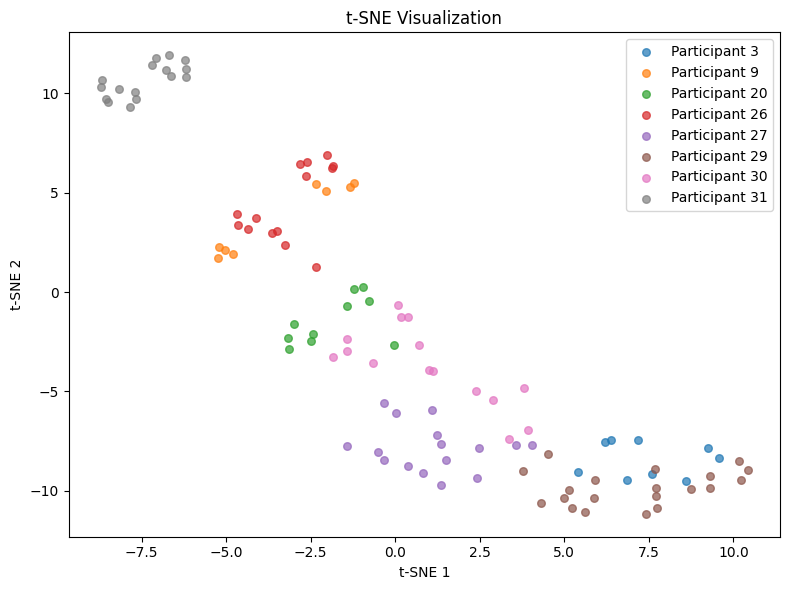

2026-02-06 16:37:51,844 - yolo_butterworth - INFO - Test set size for rank classification: 108
2026-02-06 16:37:51,845 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 16:37:51,845 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 16:37:51,846 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 16:37:51,869 - yolo_butterworth - INFO - k-NN eucl    | 0.8247     | 0.9528     | 0.9905
2026-02-06 16:37:51,888 - yolo_butterworth - INFO - k-NN manh    | 0.8610     | 0.9810     | 1.0000
2026-02-06 16:37:51,927 - yolo_butterworth - INFO - SVM          | 0.9346     | 0.9719     | 1.0000
2026-02-06 16:37:53,135 - yolo_butterworth - INFO - MLP          | 0.9255     | 0.9905     | 1.0000
2026-02-06 16:37:53,156 - yolo_butterworth - INFO - NB           | 0.8784     | 1.0000     | 1.0000
2026-02-06 16:37:53,200 - yolo_butterworth - INFO - LR           | 0.8429     | 0.9818     | 1.0

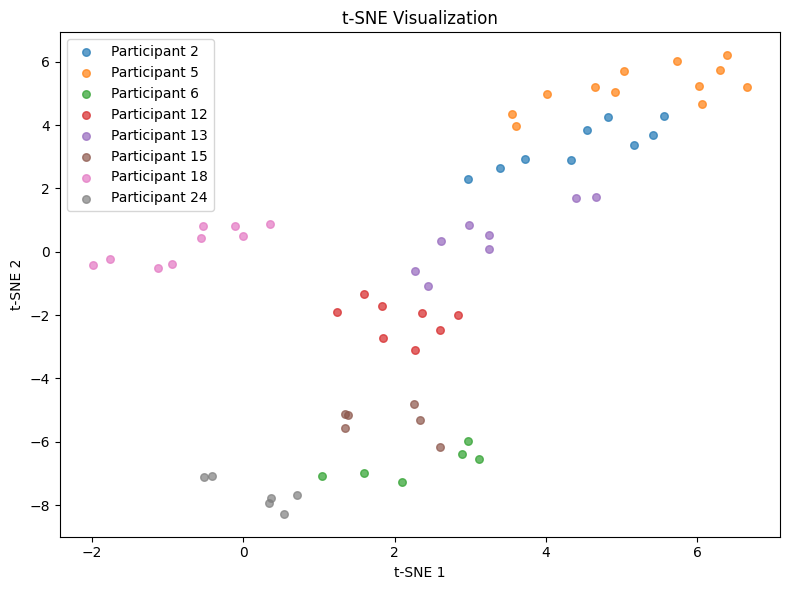

2026-02-06 16:39:21,669 - yolo_butterworth - INFO - Test set size for rank classification: 64
2026-02-06 16:39:21,670 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 16:39:21,671 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 16:39:21,671 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 16:39:21,695 - yolo_butterworth - INFO - k-NN eucl    | 0.7500     | 0.9385     | 0.9846
2026-02-06 16:39:21,715 - yolo_butterworth - INFO - k-NN manh    | 0.8282     | 0.9538     | 0.9692
2026-02-06 16:39:21,750 - yolo_butterworth - INFO - SVM          | 0.8885     | 0.9846     | 1.0000
2026-02-06 16:39:22,690 - yolo_butterworth - INFO - MLP          | 0.9372     | 0.9846     | 1.0000
2026-02-06 16:39:22,712 - yolo_butterworth - INFO - NB           | 0.9372     | 1.0000     | 1.0000
2026-02-06 16:39:22,755 - yolo_butterworth - INFO - LR           | 0.8744     | 0.9692     | 1.00

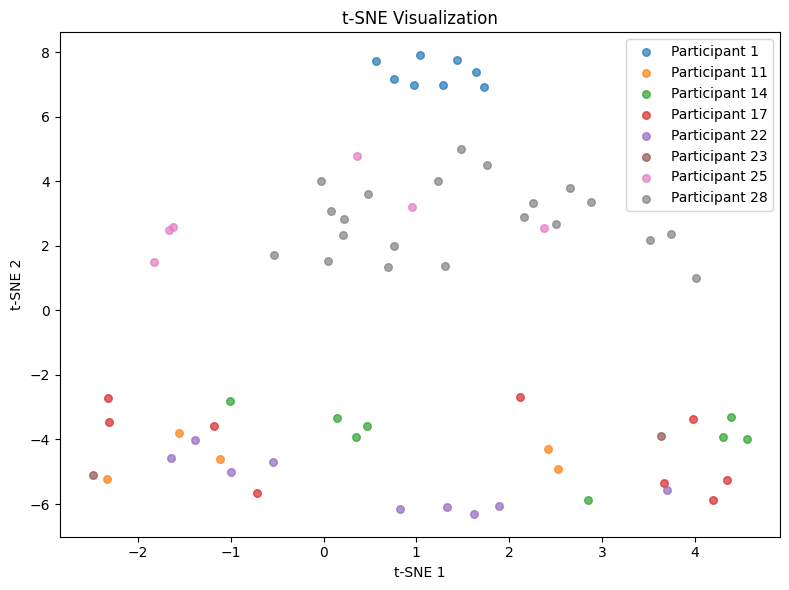

2026-02-06 16:40:43,341 - yolo_butterworth - INFO - Test set size for rank classification: 68
2026-02-06 16:40:43,342 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 16:40:43,342 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 16:40:43,343 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 16:40:43,364 - yolo_butterworth - INFO - k-NN eucl    | 0.7209     | 0.8538     | 0.8978
2026-02-06 16:40:43,383 - yolo_butterworth - INFO - k-NN manh    | 0.7198     | 0.8527     | 0.8978
2026-02-06 16:40:43,416 - yolo_butterworth - INFO - SVM          | 0.7516     | 0.8538     | 0.9275
2026-02-06 16:40:44,263 - yolo_butterworth - INFO - MLP          | 0.8099     | 0.8692     | 0.9275
2026-02-06 16:40:44,284 - yolo_butterworth - INFO - NB           | 0.7341     | 0.8538     | 0.9560
2026-02-06 16:40:44,324 - yolo_butterworth - INFO - LR           | 0.7670     | 0.8538     | 0.91

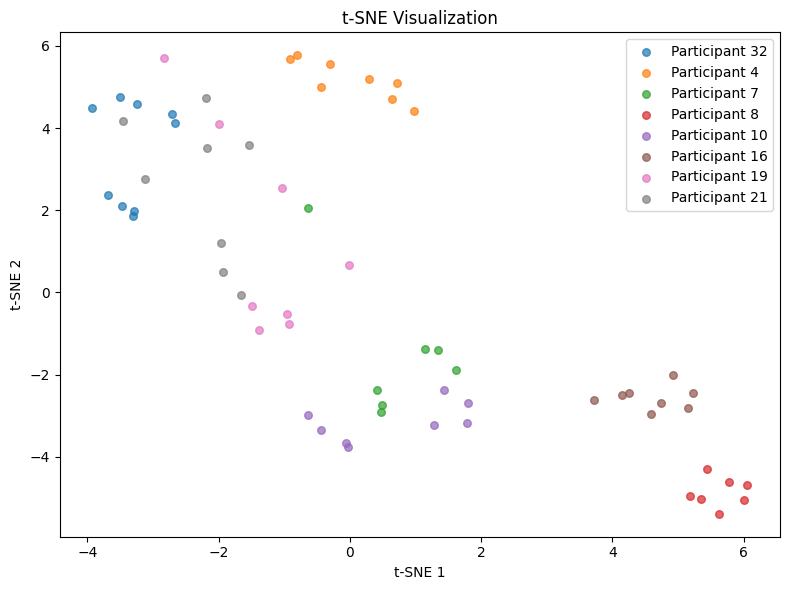

2026-02-06 16:42:13,223 - yolo_butterworth - INFO - Test set size for rank classification: 63
2026-02-06 16:42:13,223 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 16:42:13,224 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 16:42:13,224 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 16:42:13,246 - yolo_butterworth - INFO - k-NN eucl    | 0.6833     | 0.9192     | 0.9833
2026-02-06 16:42:13,265 - yolo_butterworth - INFO - k-NN manh    | 0.7769     | 0.9513     | 1.0000
2026-02-06 16:42:13,297 - yolo_butterworth - INFO - SVM          | 0.6936     | 0.9846     | 1.0000
2026-02-06 16:42:14,215 - yolo_butterworth - INFO - MLP          | 0.8885     | 0.9846     | 1.0000
2026-02-06 16:42:14,236 - yolo_butterworth - INFO - NB           | 0.8244     | 0.9513     | 0.9667
2026-02-06 16:42:14,276 - yolo_butterworth - INFO - LR           | 0.7769     | 0.9526     | 0.96

In [26]:
cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "conv1d",
    learning_rate = 1e-6,
    batch_size = 128,
    n_epochs = 100,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-06 16:42:49,311 - yolo - INFO - Preparing cycles and participant labels...
2026-02-06 16:43:00,381 - yolo - DEBUG - [0] Test fold participants: [27, 26, 20, 29, 31, 3, 30, 9]
2026-02-06 16:43:00,382 - yolo - DEBUG - [0] Train fold participants: [1, 2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 28, 32] 
2026-02-06 16:43:00,383 - yolo - DEBUG - [1] Test fold participants: [6, 12, 13, 15, 2, 18, 5, 24]
2026-02-06 16:43:00,383 - yolo - DEBUG - [1] Train fold participants: [1, 3, 4, 7, 8, 9, 10, 11, 14, 16, 17, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32] 
2026-02-06 16:43:00,384 - yolo - DEBUG - [2] Test fold participants: [11, 23, 17, 25, 14, 22, 28, 1]
2026-02-06 16:43:00,384 - yolo - DEBUG - [2] Train fold participants: [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 15, 16, 18, 19, 20, 21, 24, 26, 27, 29, 30, 31, 32] 
2026-02-06 16:43:00,385 - yolo - DEBUG - [3] Test fold participants: [16, 7, 10, 21, 19, 4, 32, 8]
2026-02-06 16:43:00,385 - yolo - DE

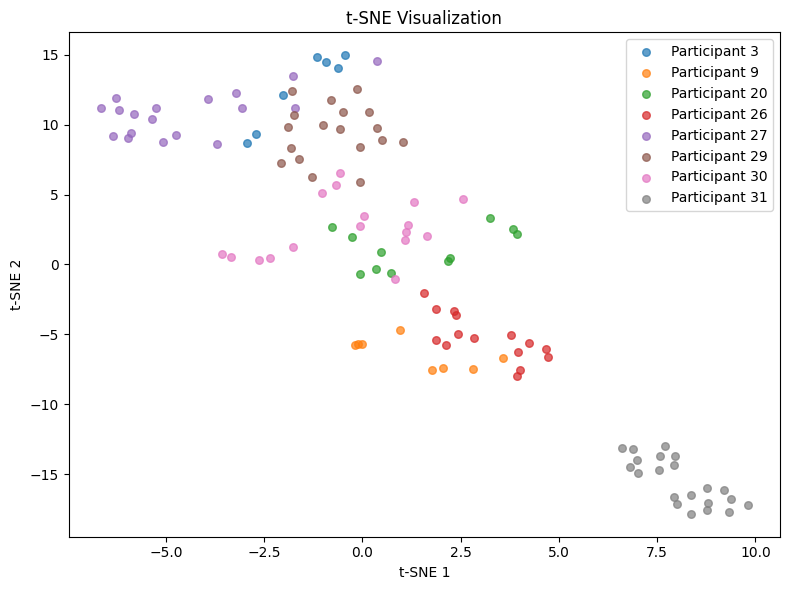

2026-02-06 16:44:03,234 - yolo - INFO - Test set size for rank classification: 115
2026-02-06 16:44:03,235 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 16:44:03,235 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 16:44:03,236 - yolo - INFO - -------------------------------------------------------
2026-02-06 16:44:03,257 - yolo - INFO - k-NN eucl    | 0.8000     | 0.9652     | 0.9826
2026-02-06 16:44:03,277 - yolo - INFO - k-NN manh    | 0.8087     | 0.9478     | 0.9826
2026-02-06 16:44:03,320 - yolo - INFO - SVM          | 0.8870     | 0.9391     | 0.9826
2026-02-06 16:44:04,558 - yolo - INFO - MLP          | 0.8609     | 0.9565     | 0.9826
2026-02-06 16:44:04,578 - yolo - INFO - NB           | 0.8348     | 0.9565     | 1.0000
2026-02-06 16:44:04,624 - yolo - INFO - LR           | 0.8348     | 0.9304     | 0.9826
2026-02-06 16:44:05,237 - yolo - INFO - RF           | 0.8348     | 0.9739     | 1.0000
2026-02-06 16:44:08,983 - yo

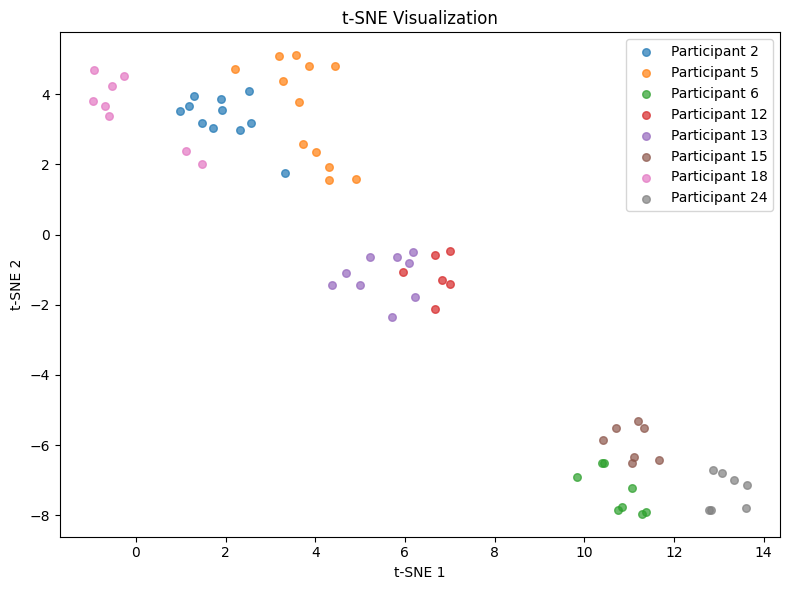

2026-02-06 16:45:46,217 - yolo - INFO - Test set size for rank classification: 68
2026-02-06 16:45:46,218 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 16:45:46,218 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 16:45:46,219 - yolo - INFO - -------------------------------------------------------
2026-02-06 16:45:46,240 - yolo - INFO - k-NN eucl    | 0.7484     | 0.9560     | 0.9703
2026-02-06 16:45:46,260 - yolo - INFO - k-NN manh    | 0.7637     | 0.9560     | 0.9703
2026-02-06 16:45:46,295 - yolo - INFO - SVM          | 0.7802     | 0.9703     | 1.0000
2026-02-06 16:45:47,313 - yolo - INFO - MLP          | 0.8341     | 0.9253     | 0.9846
2026-02-06 16:45:47,338 - yolo - INFO - NB           | 0.8363     | 0.9549     | 0.9857
2026-02-06 16:45:47,384 - yolo - INFO - LR           | 0.8648     | 0.9385     | 0.9692
2026-02-06 16:45:48,020 - yolo - INFO - RF           | 0.9110     | 0.9846     | 1.0000
2026-02-06 16:45:51,173 - yol

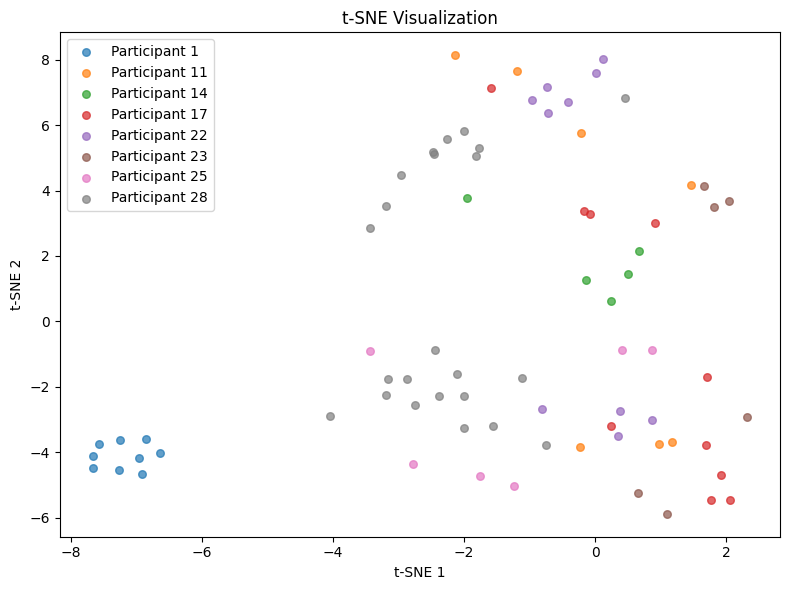

2026-02-06 16:47:20,020 - yolo - INFO - Test set size for rank classification: 76
2026-02-06 16:47:20,021 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 16:47:20,022 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 16:47:20,022 - yolo - INFO - -------------------------------------------------------
2026-02-06 16:47:20,045 - yolo - INFO - k-NN eucl    | 0.7383     | 0.8683     | 0.9075
2026-02-06 16:47:20,065 - yolo - INFO - k-NN manh    | 0.7233     | 0.8417     | 0.9342
2026-02-06 16:47:20,100 - yolo - INFO - SVM          | 0.7633     | 0.8817     | 0.9608
2026-02-06 16:47:20,984 - yolo - INFO - MLP          | 0.8025     | 0.8675     | 0.9342
2026-02-06 16:47:21,005 - yolo - INFO - NB           | 0.6183     | 0.7233     | 0.8417
2026-02-06 16:47:21,041 - yolo - INFO - LR           | 0.7242     | 0.8683     | 0.9600
2026-02-06 16:47:21,628 - yolo - INFO - RF           | 0.6442     | 0.7892     | 0.8808
2026-02-06 16:47:25,022 - yol

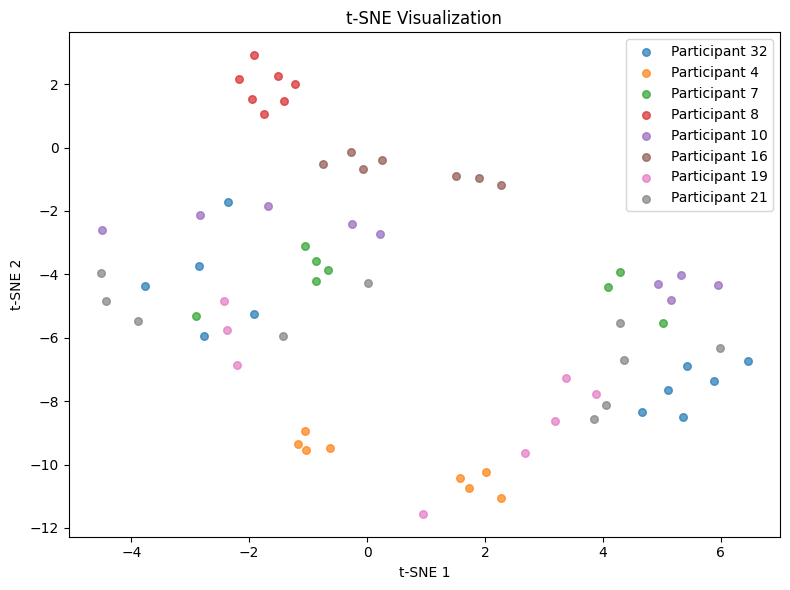

2026-02-06 16:49:05,851 - yolo - INFO - Test set size for rank classification: 68
2026-02-06 16:49:05,852 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 16:49:05,853 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 16:49:05,853 - yolo - INFO - -------------------------------------------------------
2026-02-06 16:49:05,875 - yolo - INFO - k-NN eucl    | 0.5275     | 0.7780     | 0.9253
2026-02-06 16:49:05,895 - yolo - INFO - k-NN manh    | 0.5275     | 0.7637     | 0.9407
2026-02-06 16:49:05,930 - yolo - INFO - SVM          | 0.6780     | 0.8681     | 0.9407
2026-02-06 16:49:06,914 - yolo - INFO - MLP          | 0.7813     | 0.9418     | 0.9703
2026-02-06 16:49:06,935 - yolo - INFO - NB           | 0.6484     | 0.7802     | 0.8824
2026-02-06 16:49:06,972 - yolo - INFO - LR           | 0.6637     | 0.8088     | 0.9407
2026-02-06 16:49:07,568 - yolo - INFO - RF           | 0.7055     | 0.8681     | 0.9692
2026-02-06 16:49:11,000 - yol

In [27]:
cv = CrossValidationSiameseRaw(
    sequence_cycles = yolo_cycles, 
    coordinates_idx = CoordinatesIdx(0, 1, 2), 
    log_level = logging.DEBUG,
    logger_name = 'yolo',
)

cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "conv1d",
    learning_rate = 1e-6,
    batch_size = 128,
    n_epochs = 100,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-06 16:58:46,380 - yolo - INFO - Preparing cycles and participant labels...
2026-02-06 16:58:57,360 - yolo - INFO - [Iteration 1/4]
2026-02-06 16:58:57,382 - yolo - INFO - Train dataset size: 1944
2026-02-06 16:58:58,261 - yolo - INFO - Epoch 1, Train Loss: 0.3659538003753443
2026-02-06 16:58:59,161 - yolo - INFO - Epoch 2, Train Loss: 0.3575407207989302
2026-02-06 16:59:00,129 - yolo - INFO - Epoch 3, Train Loss: 0.34603963767895934
2026-02-06 16:59:01,019 - yolo - INFO - Epoch 4, Train Loss: 0.3380148027275429
2026-02-06 16:59:01,972 - yolo - INFO - Epoch 5, Train Loss: 0.3278828483135974
2026-02-06 16:59:02,880 - yolo - INFO - Epoch 6, Train Loss: 0.31747910111654
2026-02-06 16:59:03,809 - yolo - INFO - Epoch 7, Train Loss: 0.30933237173518197
2026-02-06 16:59:04,700 - yolo - INFO - Epoch 8, Train Loss: 0.3011788225076238
2026-02-06 16:59:05,656 - yolo - INFO - Epoch 9, Train Loss: 0.28703876303844766
2026-02-06 16:59:06,524 - yolo - INFO - Epoch 10, Train Loss: 0.27205217568

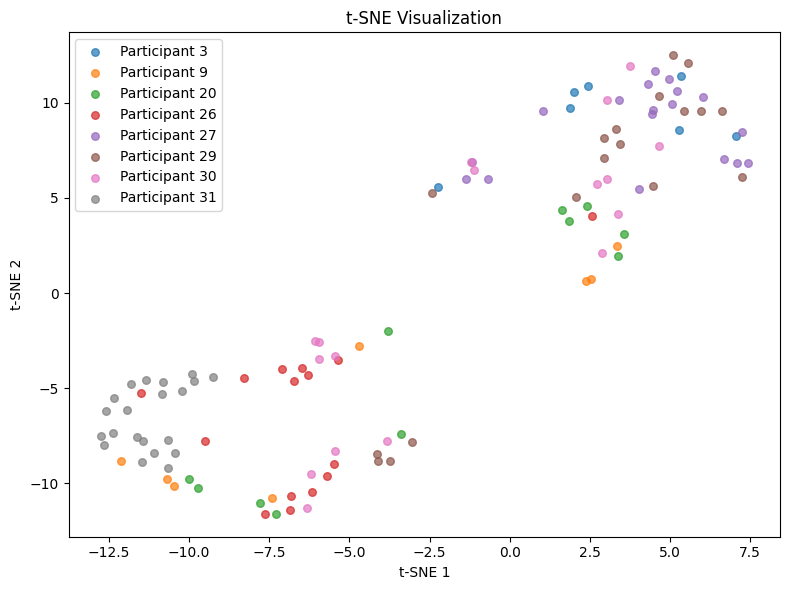

2026-02-06 17:00:31,299 - yolo - INFO - Test set size for rank classification: 115
2026-02-06 17:00:31,300 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 17:00:31,300 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 17:00:31,301 - yolo - INFO - -------------------------------------------------------
2026-02-06 17:00:31,328 - yolo - INFO - k-NN eucl    | 0.4957     | 0.7478     | 0.8087
2026-02-06 17:00:31,348 - yolo - INFO - k-NN manh    | 0.4522     | 0.7391     | 0.8087
2026-02-06 17:00:31,390 - yolo - INFO - SVM          | 0.4609     | 0.7043     | 0.8174
2026-02-06 17:00:32,639 - yolo - INFO - MLP          | 0.5478     | 0.7391     | 0.8870
2026-02-06 17:00:32,659 - yolo - INFO - NB           | 0.4522     | 0.6087     | 0.8261
2026-02-06 17:00:32,712 - yolo - INFO - LR           | 0.4870     | 0.6522     | 0.8174
2026-02-06 17:00:33,332 - yolo - INFO - RF           | 0.5130     | 0.7652     | 0.8174
2026-02-06 17:00:37,084 - yo

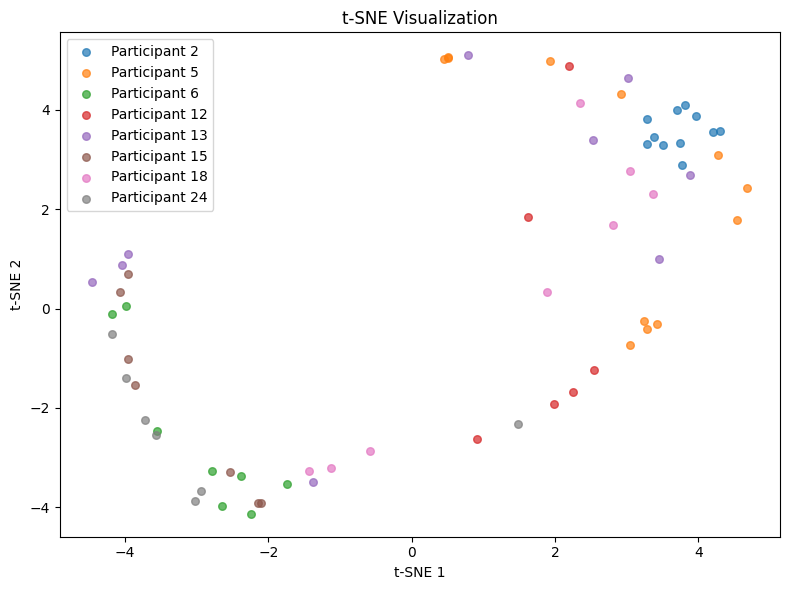

2026-02-06 17:03:00,176 - yolo - INFO - Test set size for rank classification: 68
2026-02-06 17:03:00,177 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 17:03:00,178 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 17:03:00,178 - yolo - INFO - -------------------------------------------------------
2026-02-06 17:03:00,201 - yolo - INFO - k-NN eucl    | 0.4978     | 0.6011     | 0.7780
2026-02-06 17:03:00,221 - yolo - INFO - k-NN manh    | 0.4989     | 0.6165     | 0.7791
2026-02-06 17:03:00,254 - yolo - INFO - SVM          | 0.4396     | 0.5901     | 0.8385
2026-02-06 17:03:01,367 - yolo - INFO - MLP          | 0.4407     | 0.6769     | 0.8670
2026-02-06 17:03:01,387 - yolo - INFO - NB           | 0.3967     | 0.6901     | 0.8527
2026-02-06 17:03:01,432 - yolo - INFO - LR           | 0.4231     | 0.7055     | 0.8077
2026-02-06 17:03:02,016 - yolo - INFO - RF           | 0.6000     | 0.7165     | 0.8945
2026-02-06 17:03:05,341 - yol

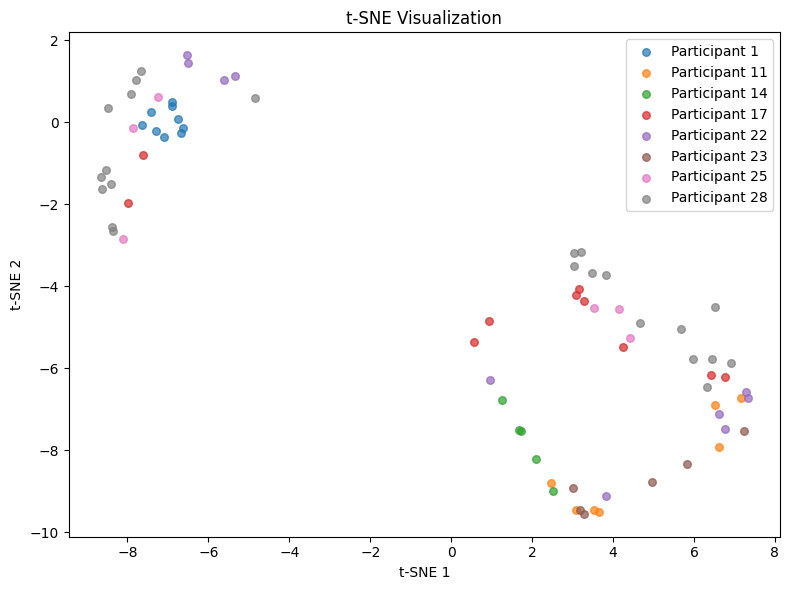

2026-02-06 17:05:33,266 - yolo - INFO - Test set size for rank classification: 76
2026-02-06 17:05:33,267 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 17:05:33,267 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 17:05:33,268 - yolo - INFO - -------------------------------------------------------
2026-02-06 17:05:33,293 - yolo - INFO - k-NN eucl    | 0.4992     | 0.6458     | 0.8700
2026-02-06 17:05:33,318 - yolo - INFO - k-NN manh    | 0.5525     | 0.6858     | 0.9100
2026-02-06 17:05:33,356 - yolo - INFO - SVM          | 0.3683     | 0.6325     | 0.8175
2026-02-06 17:05:34,721 - yolo - INFO - MLP          | 0.5392     | 0.7242     | 0.8950
2026-02-06 17:05:34,785 - yolo - INFO - NB           | 0.3942     | 0.6058     | 0.8042
2026-02-06 17:05:34,908 - yolo - INFO - LR           | 0.5258     | 0.7125     | 0.8442
2026-02-06 17:05:35,644 - yolo - INFO - RF           | 0.5792     | 0.7250     | 0.8967
2026-02-06 17:05:39,442 - yol

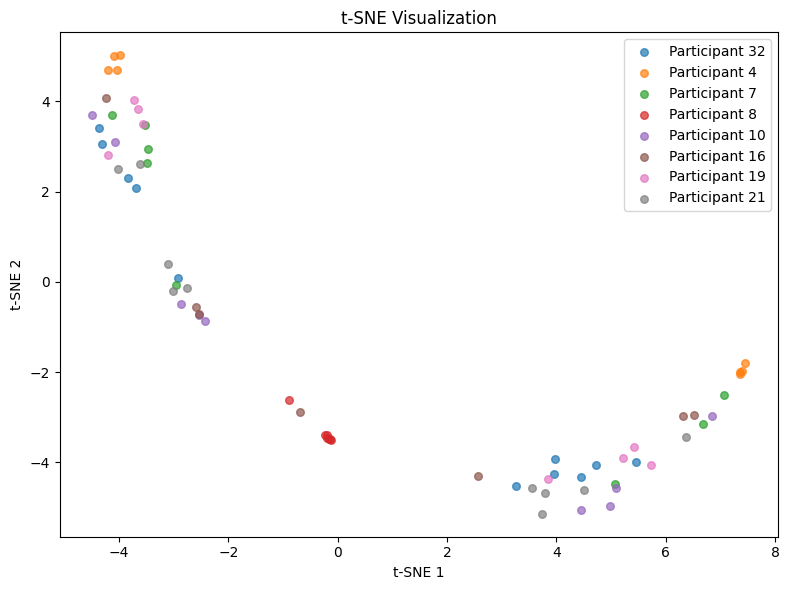

2026-02-06 17:08:27,649 - yolo - INFO - Test set size for rank classification: 68
2026-02-06 17:08:27,651 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 17:08:27,652 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 17:08:27,652 - yolo - INFO - -------------------------------------------------------
2026-02-06 17:08:27,674 - yolo - INFO - k-NN eucl    | 0.3549     | 0.5736     | 0.7802
2026-02-06 17:08:27,694 - yolo - INFO - k-NN manh    | 0.3571     | 0.5308     | 0.7363
2026-02-06 17:08:27,727 - yolo - INFO - SVM          | 0.2626     | 0.4099     | 0.5275
2026-02-06 17:08:28,847 - yolo - INFO - MLP          | 0.4560     | 0.7341     | 0.8066
2026-02-06 17:08:28,868 - yolo - INFO - NB           | 0.3670     | 0.6044     | 0.7209
2026-02-06 17:08:28,916 - yolo - INFO - LR           | 0.3945     | 0.6440     | 0.7473
2026-02-06 17:08:29,626 - yolo - INFO - RF           | 0.4582     | 0.6912     | 0.7648
2026-02-06 17:08:32,930 - yol

In [30]:
cv = CrossValidationSiameseRaw(
    sequence_cycles = yolo_cycles, 
    coordinates_idx = CoordinatesIdx(0, 1, 2), 
    log_level = logging.INFO,
    logger_name = 'yolo',
)

cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "lstm",
    learning_rate = 1e-5,
    batch_size = 32,
    n_epochs = 100,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-06 17:08:55,305 - yolo - INFO - [Iteration 1/4]
2026-02-06 17:08:55,325 - yolo - INFO - Train dataset size: 1944
2026-02-06 17:08:56,253 - yolo - INFO - Epoch 1, Train Loss: 0.29176487004170654
2026-02-06 17:08:57,349 - yolo - INFO - Epoch 2, Train Loss: 0.21318934906701573
2026-02-06 17:08:58,351 - yolo - INFO - Epoch 3, Train Loss: 0.17625829186595854
2026-02-06 17:08:59,411 - yolo - INFO - Epoch 4, Train Loss: 0.13789425301747243
2026-02-06 17:09:00,357 - yolo - INFO - Epoch 5, Train Loss: 0.10714865048400692
2026-02-06 17:09:01,370 - yolo - INFO - Epoch 6, Train Loss: 0.07983482800057677
2026-02-06 17:09:02,381 - yolo - INFO - Epoch 7, Train Loss: 0.06610764300481217
2026-02-06 17:09:03,336 - yolo - INFO - Epoch 8, Train Loss: 0.05590517373114336
2026-02-06 17:09:04,348 - yolo - INFO - Epoch 9, Train Loss: 0.04163731840729225
2026-02-06 17:09:05,323 - yolo - INFO - Epoch 10, Train Loss: 0.03175654112681991
2026-02-06 17:09:06,292 - yolo - INFO - Epoch 11, Train Loss: 0.0305

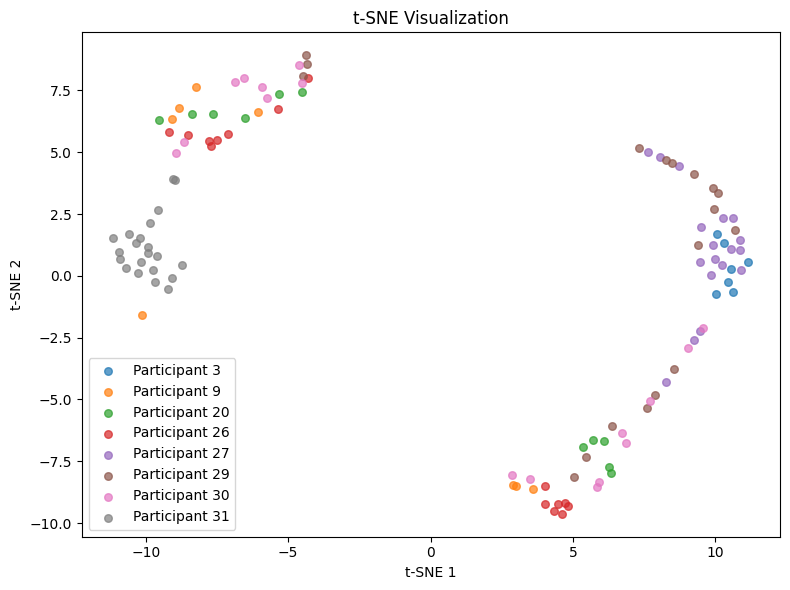

2026-02-06 17:09:46,272 - yolo - INFO - Test set size for rank classification: 115
2026-02-06 17:09:46,273 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 17:09:46,273 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 17:09:46,274 - yolo - INFO - -------------------------------------------------------
2026-02-06 17:09:46,296 - yolo - INFO - k-NN eucl    | 0.5478     | 0.7652     | 0.8522
2026-02-06 17:09:46,315 - yolo - INFO - k-NN manh    | 0.5478     | 0.7478     | 0.8435
2026-02-06 17:09:46,360 - yolo - INFO - SVM          | 0.4957     | 0.7130     | 0.8957
2026-02-06 17:09:47,606 - yolo - INFO - MLP          | 0.5826     | 0.7739     | 0.8783
2026-02-06 17:09:47,628 - yolo - INFO - NB           | 0.4783     | 0.7652     | 0.8957
2026-02-06 17:09:47,679 - yolo - INFO - LR           | 0.5565     | 0.7739     | 0.8870
2026-02-06 17:09:48,309 - yolo - INFO - RF           | 0.5739     | 0.7826     | 0.9217
2026-02-06 17:09:52,019 - yo

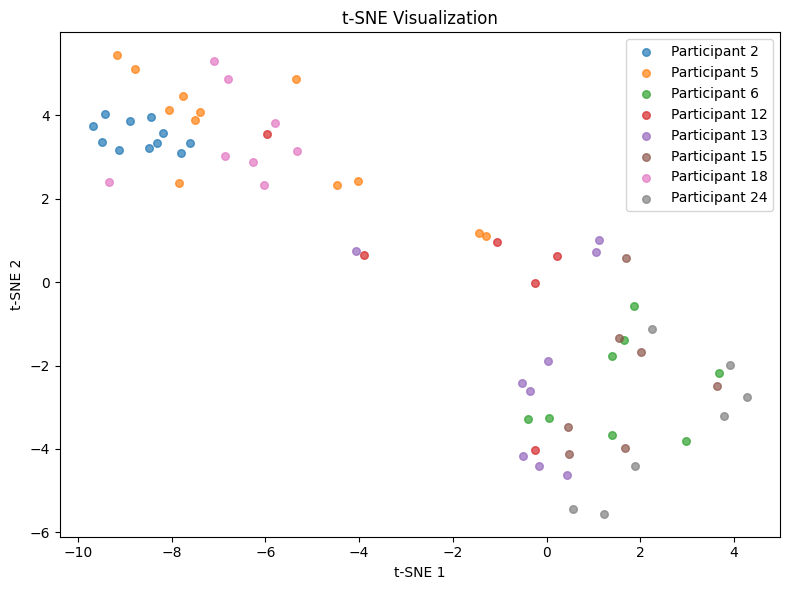

2026-02-06 17:11:13,144 - yolo - INFO - Test set size for rank classification: 68
2026-02-06 17:11:13,146 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 17:11:13,146 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 17:11:13,147 - yolo - INFO - -------------------------------------------------------
2026-02-06 17:11:13,176 - yolo - INFO - k-NN eucl    | 0.4264     | 0.7044     | 0.7945
2026-02-06 17:11:13,196 - yolo - INFO - k-NN manh    | 0.4549     | 0.6890     | 0.7802
2026-02-06 17:11:13,231 - yolo - INFO - SVM          | 0.3824     | 0.5890     | 0.8516
2026-02-06 17:11:14,320 - yolo - INFO - MLP          | 0.4846     | 0.7505     | 0.8099
2026-02-06 17:11:14,350 - yolo - INFO - NB           | 0.5264     | 0.7462     | 0.8824
2026-02-06 17:11:14,390 - yolo - INFO - LR           | 0.3802     | 0.7055     | 0.8967
2026-02-06 17:11:14,982 - yolo - INFO - RF           | 0.5582     | 0.7637     | 0.9132
2026-02-06 17:11:18,263 - yol

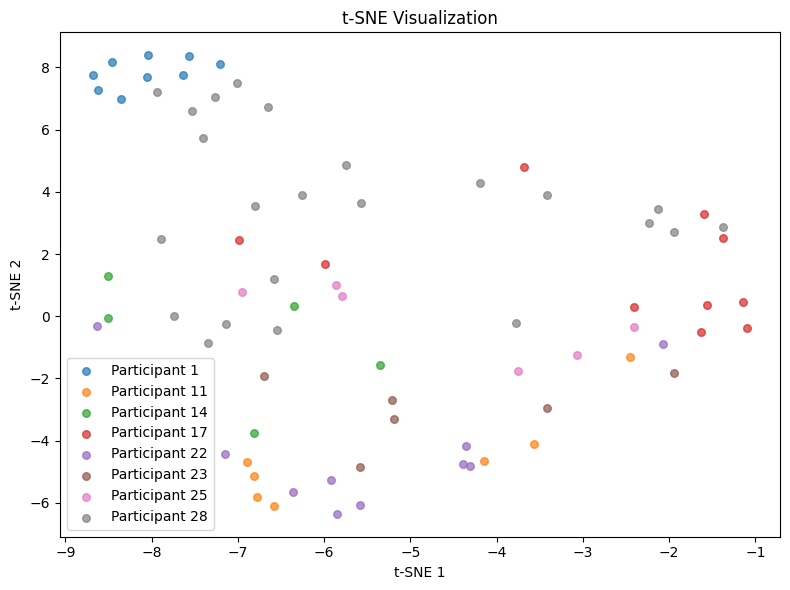

2026-02-06 17:12:29,912 - yolo - INFO - Test set size for rank classification: 76
2026-02-06 17:12:29,913 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 17:12:29,914 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 17:12:29,914 - yolo - INFO - -------------------------------------------------------
2026-02-06 17:12:29,936 - yolo - INFO - k-NN eucl    | 0.5558     | 0.8058     | 0.8842
2026-02-06 17:12:29,956 - yolo - INFO - k-NN manh    | 0.5692     | 0.8058     | 0.8708
2026-02-06 17:12:29,994 - yolo - INFO - SVM          | 0.5542     | 0.8292     | 0.8817
2026-02-06 17:12:31,192 - yolo - INFO - MLP          | 0.6467     | 0.8817     | 0.9208
2026-02-06 17:12:31,212 - yolo - INFO - NB           | 0.4883     | 0.8167     | 0.8825
2026-02-06 17:12:31,258 - yolo - INFO - LR           | 0.5417     | 0.8175     | 0.9083
2026-02-06 17:12:31,852 - yolo - INFO - RF           | 0.5808     | 0.8167     | 0.9208
2026-02-06 17:12:35,275 - yol

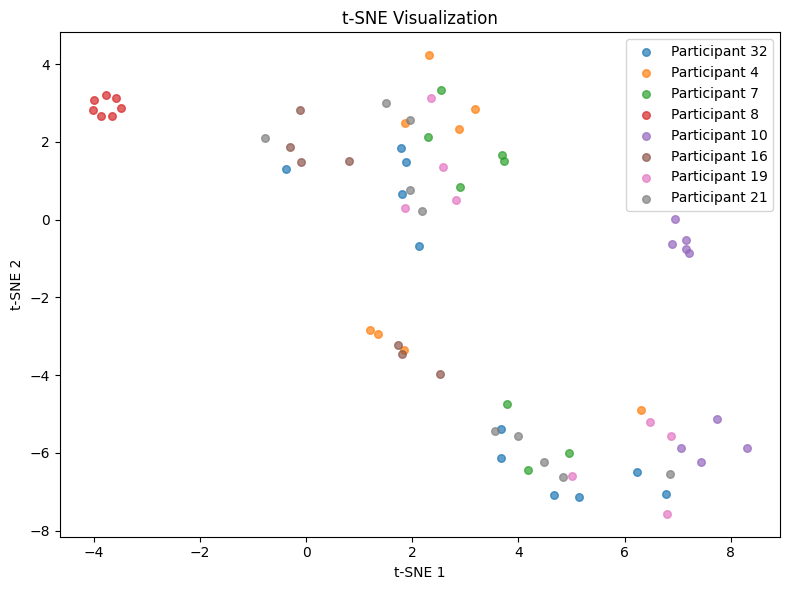

2026-02-06 17:13:54,842 - yolo - INFO - Test set size for rank classification: 68
2026-02-06 17:13:54,843 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-06 17:13:54,843 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 17:13:54,844 - yolo - INFO - -------------------------------------------------------
2026-02-06 17:13:54,866 - yolo - INFO - k-NN eucl    | 0.4099     | 0.6593     | 0.8077
2026-02-06 17:13:54,887 - yolo - INFO - k-NN manh    | 0.3791     | 0.6593     | 0.7923
2026-02-06 17:13:54,924 - yolo - INFO - SVM          | 0.4099     | 0.5736     | 0.7077
2026-02-06 17:13:56,053 - yolo - INFO - MLP          | 0.5736     | 0.7659     | 0.8692
2026-02-06 17:13:56,073 - yolo - INFO - NB           | 0.5165     | 0.6187     | 0.7648
2026-02-06 17:13:56,112 - yolo - INFO - LR           | 0.4725     | 0.7352     | 0.8374
2026-02-06 17:13:56,706 - yolo - INFO - RF           | 0.6341     | 0.7505     | 0.8681
2026-02-06 17:14:00,021 - yol

In [31]:
cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "lstm",
    learning_rate = 1e-4,
    batch_size = 32,
    n_epochs = 50,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-06 17:14:10,128 - yolo_butterworth - INFO - Preparing cycles and participant labels...
2026-02-06 17:14:20,282 - yolo_butterworth - INFO - [Iteration 1/4]
2026-02-06 17:14:20,299 - yolo_butterworth - INFO - Train dataset size: 1642
2026-02-06 17:14:21,058 - yolo_butterworth - INFO - Epoch 1, Train Loss: 0.279742001914061
2026-02-06 17:14:21,821 - yolo_butterworth - INFO - Epoch 2, Train Loss: 0.19654092335930237
2026-02-06 17:14:22,675 - yolo_butterworth - INFO - Epoch 3, Train Loss: 0.14285979362634513
2026-02-06 17:14:23,504 - yolo_butterworth - INFO - Epoch 4, Train Loss: 0.1151796539958853
2026-02-06 17:14:24,371 - yolo_butterworth - INFO - Epoch 5, Train Loss: 0.0922260656952858
2026-02-06 17:14:25,168 - yolo_butterworth - INFO - Epoch 6, Train Loss: 0.07973502848583919
2026-02-06 17:14:25,933 - yolo_butterworth - INFO - Epoch 7, Train Loss: 0.06403288882798873
2026-02-06 17:14:26,730 - yolo_butterworth - INFO - Epoch 8, Train Loss: 0.05481159511523751
2026-02-06 17:14:27,

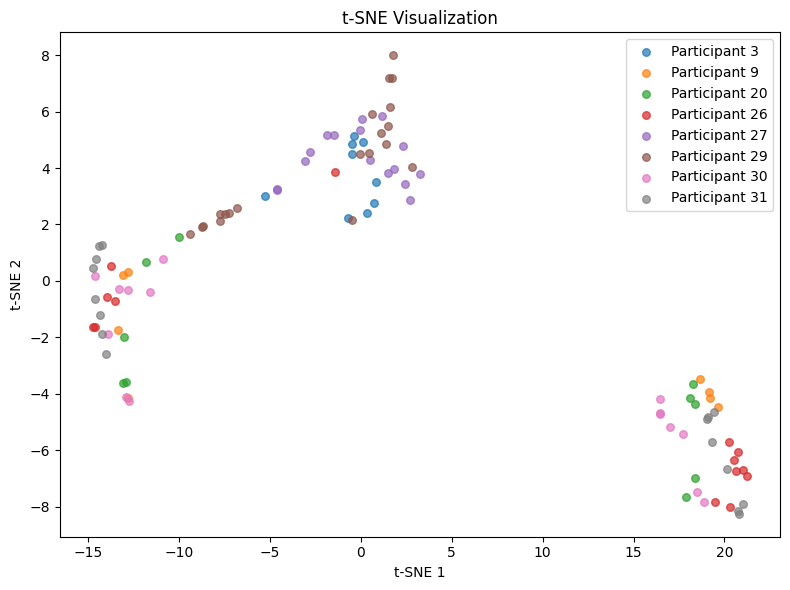

2026-02-06 17:15:00,585 - yolo_butterworth - INFO - Test set size for rank classification: 108
2026-02-06 17:15:00,586 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 17:15:00,586 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 17:15:00,587 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 17:15:00,608 - yolo_butterworth - INFO - k-NN eucl    | 0.5459     | 0.6758     | 0.8420
2026-02-06 17:15:00,629 - yolo_butterworth - INFO - k-NN manh    | 0.5359     | 0.7039     | 0.8610
2026-02-06 17:15:00,669 - yolo_butterworth - INFO - SVM          | 0.3524     | 0.6580     | 0.8338
2026-02-06 17:15:01,881 - yolo_butterworth - INFO - MLP          | 0.5831     | 0.7671     | 0.9351
2026-02-06 17:15:01,905 - yolo_butterworth - INFO - NB           | 0.3333     | 0.5286     | 0.7502
2026-02-06 17:15:01,950 - yolo_butterworth - INFO - LR           | 0.4355     | 0.6766     | 0.8

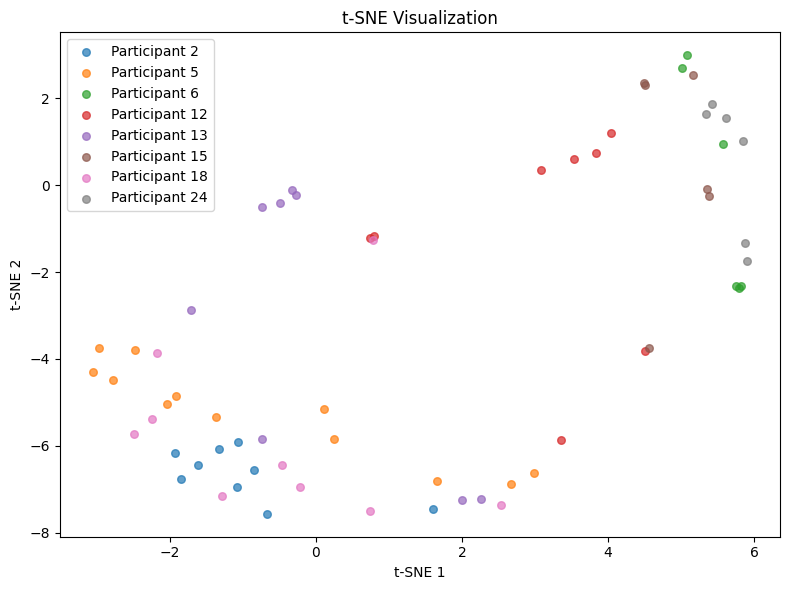

2026-02-06 17:16:11,997 - yolo_butterworth - INFO - Test set size for rank classification: 64
2026-02-06 17:16:11,998 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 17:16:11,999 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 17:16:11,999 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 17:16:12,022 - yolo_butterworth - INFO - k-NN eucl    | 0.5013     | 0.7064     | 0.8295
2026-02-06 17:16:12,042 - yolo_butterworth - INFO - k-NN manh    | 0.5346     | 0.7064     | 0.8449
2026-02-06 17:16:12,073 - yolo_butterworth - INFO - SVM          | 0.4679     | 0.7192     | 0.8756
2026-02-06 17:16:13,157 - yolo_butterworth - INFO - MLP          | 0.6564     | 0.8269     | 0.9064
2026-02-06 17:16:13,178 - yolo_butterworth - INFO - NB           | 0.5936     | 0.7974     | 0.9064
2026-02-06 17:16:13,236 - yolo_butterworth - INFO - LR           | 0.5615     | 0.7667     | 0.89

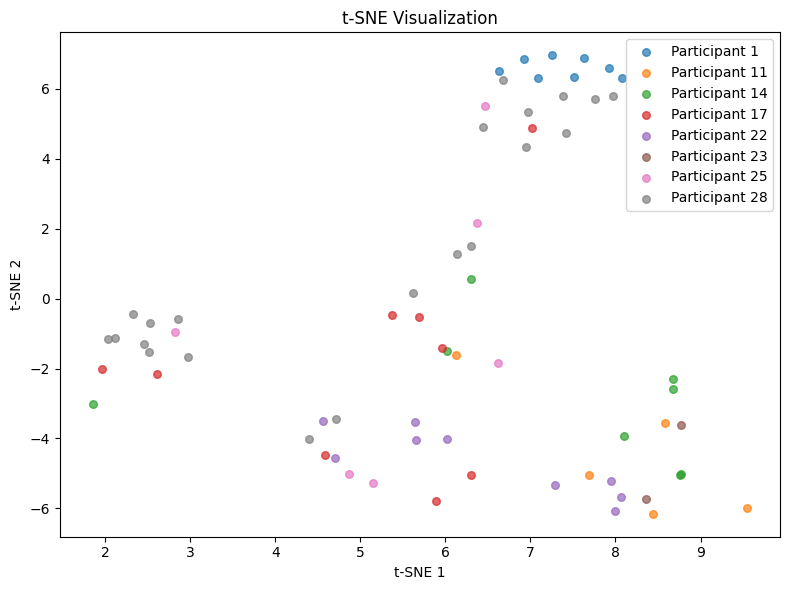

2026-02-06 17:17:15,878 - yolo_butterworth - INFO - Test set size for rank classification: 68
2026-02-06 17:17:15,879 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 17:17:15,879 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 17:17:15,880 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 17:17:15,901 - yolo_butterworth - INFO - k-NN eucl    | 0.5286     | 0.6484     | 0.7374
2026-02-06 17:17:15,920 - yolo_butterworth - INFO - k-NN manh    | 0.5275     | 0.6758     | 0.7505
2026-02-06 17:17:15,954 - yolo_butterworth - INFO - SVM          | 0.4560     | 0.7659     | 0.8692
2026-02-06 17:17:17,069 - yolo_butterworth - INFO - MLP          | 0.5593     | 0.6615     | 0.7791
2026-02-06 17:17:17,091 - yolo_butterworth - INFO - NB           | 0.5571     | 0.6604     | 0.8099
2026-02-06 17:17:17,143 - yolo_butterworth - INFO - LR           | 0.5582     | 0.7187     | 0.78

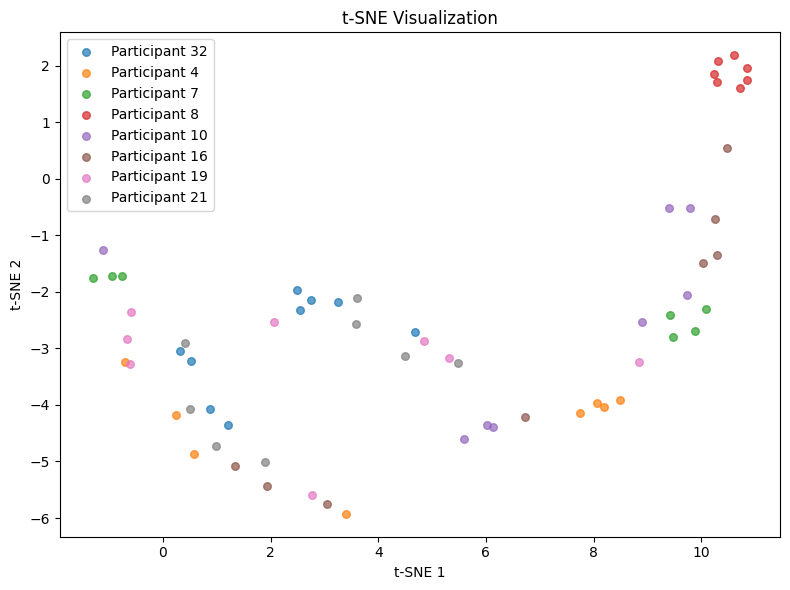

2026-02-06 17:18:27,680 - yolo_butterworth - INFO - Test set size for rank classification: 63
2026-02-06 17:18:27,681 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 17:18:27,682 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 17:18:27,682 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 17:18:27,705 - yolo_butterworth - INFO - k-NN eucl    | 0.5064     | 0.6821     | 0.8282
2026-02-06 17:18:27,725 - yolo_butterworth - INFO - k-NN manh    | 0.5064     | 0.6654     | 0.8115
2026-02-06 17:18:27,757 - yolo_butterworth - INFO - SVM          | 0.3474     | 0.4923     | 0.7795
2026-02-06 17:18:28,834 - yolo_butterworth - INFO - MLP          | 0.5705     | 0.6974     | 0.8897
2026-02-06 17:18:28,855 - yolo_butterworth - INFO - NB           | 0.4615     | 0.5897     | 0.7962
2026-02-06 17:18:28,898 - yolo_butterworth - INFO - LR           | 0.3974     | 0.6372     | 0.81

In [32]:
cv = CrossValidationSiameseRaw(
    sequence_cycles=yolo_cycles_butterworth, 
    coordinates_idx=CoordinatesIdx(0, 1, 2), 
    log_level=logging.INFO,
    logger_name = 'yolo_butterworth',
)

cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "lstm",
    learning_rate = 1e-4,
    batch_size = 32,
    n_epochs = 50,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-06 17:18:53,947 - yolo_butterworth - INFO - [Iteration 1/4]
2026-02-06 17:18:53,965 - yolo_butterworth - INFO - Train dataset size: 1642
2026-02-06 17:18:54,457 - yolo_butterworth - INFO - Epoch 1, Train Loss: 0.35708323350319493
2026-02-06 17:18:54,997 - yolo_butterworth - INFO - Epoch 2, Train Loss: 0.33023137083420384
2026-02-06 17:18:55,485 - yolo_butterworth - INFO - Epoch 3, Train Loss: 0.2976793348789215
2026-02-06 17:18:55,970 - yolo_butterworth - INFO - Epoch 4, Train Loss: 0.27739901496813846
2026-02-06 17:18:56,466 - yolo_butterworth - INFO - Epoch 5, Train Loss: 0.2500683046304263
2026-02-06 17:18:56,966 - yolo_butterworth - INFO - Epoch 6, Train Loss: 0.227453717818627
2026-02-06 17:18:57,440 - yolo_butterworth - INFO - Epoch 7, Train Loss: 0.20660918492537278
2026-02-06 17:18:57,935 - yolo_butterworth - INFO - Epoch 8, Train Loss: 0.19969448332603162
2026-02-06 17:18:58,416 - yolo_butterworth - INFO - Epoch 9, Train Loss: 0.1879878846498636
2026-02-06 17:18:58,910

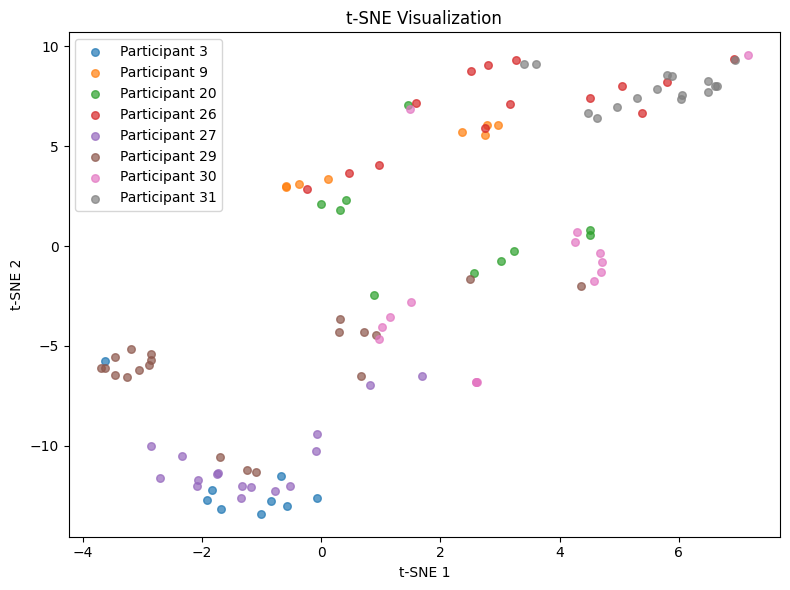

2026-02-06 17:19:44,532 - yolo_butterworth - INFO - Test set size for rank classification: 108
2026-02-06 17:19:44,533 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 17:19:44,533 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 17:19:44,534 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 17:19:44,556 - yolo_butterworth - INFO - k-NN eucl    | 0.6104     | 0.8424     | 0.9537
2026-02-06 17:19:44,575 - yolo_butterworth - INFO - k-NN manh    | 0.6377     | 0.8424     | 0.9541
2026-02-06 17:19:44,618 - yolo_butterworth - INFO - SVM          | 0.6381     | 0.8701     | 0.9818
2026-02-06 17:19:45,859 - yolo_butterworth - INFO - MLP          | 0.6195     | 0.8983     | 0.9905
2026-02-06 17:19:45,883 - yolo_butterworth - INFO - NB           | 0.5745     | 0.8706     | 0.9719
2026-02-06 17:19:45,934 - yolo_butterworth - INFO - LR           | 0.6017     | 0.9074     | 0.9

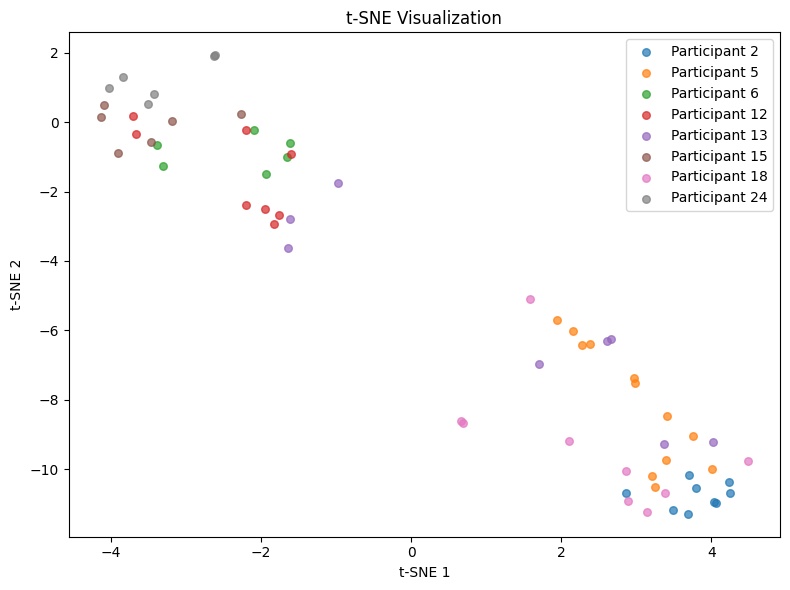

2026-02-06 17:21:11,551 - yolo_butterworth - INFO - Test set size for rank classification: 64
2026-02-06 17:21:11,552 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 17:21:11,553 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 17:21:11,553 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 17:21:11,579 - yolo_butterworth - INFO - k-NN eucl    | 0.4846     | 0.6859     | 0.8436
2026-02-06 17:21:11,600 - yolo_butterworth - INFO - k-NN manh    | 0.5308     | 0.7500     | 0.8769
2026-02-06 17:21:11,633 - yolo_butterworth - INFO - SVM          | 0.2500     | 0.5308     | 0.8590
2026-02-06 17:21:12,724 - yolo_butterworth - INFO - MLP          | 0.5756     | 0.7513     | 0.9692
2026-02-06 17:21:12,745 - yolo_butterworth - INFO - NB           | 0.4833     | 0.8269     | 0.9372
2026-02-06 17:21:12,795 - yolo_butterworth - INFO - LR           | 0.5141     | 0.7487     | 0.93

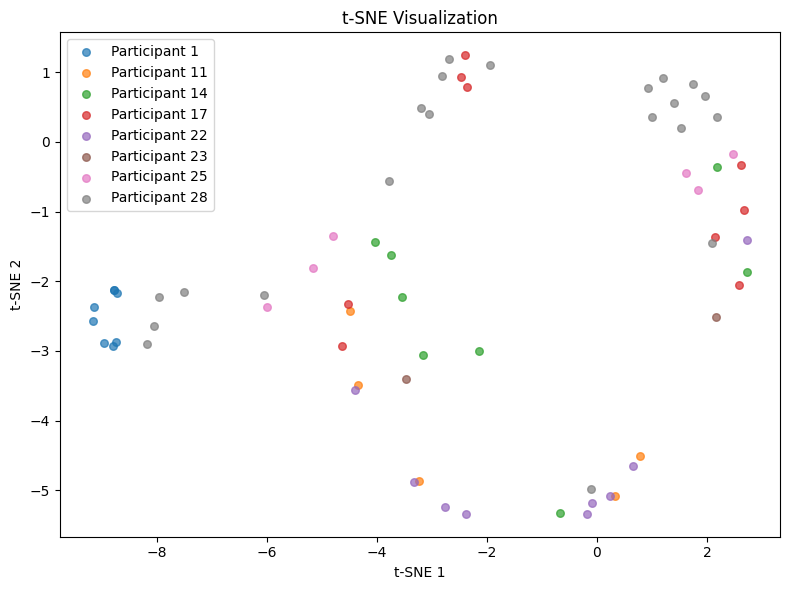

2026-02-06 17:22:30,584 - yolo_butterworth - INFO - Test set size for rank classification: 68
2026-02-06 17:22:30,585 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 17:22:30,586 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 17:22:30,586 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 17:22:30,609 - yolo_butterworth - INFO - k-NN eucl    | 0.5297     | 0.6934     | 0.7813
2026-02-06 17:22:30,628 - yolo_butterworth - INFO - k-NN manh    | 0.5000     | 0.6780     | 0.7813
2026-02-06 17:22:30,662 - yolo_butterworth - INFO - SVM          | 0.4967     | 0.6330     | 0.7077
2026-02-06 17:22:31,758 - yolo_butterworth - INFO - MLP          | 0.6352     | 0.7659     | 0.7945
2026-02-06 17:22:31,780 - yolo_butterworth - INFO - NB           | 0.5604     | 0.7352     | 0.7791
2026-02-06 17:22:31,824 - yolo_butterworth - INFO - LR           | 0.5440     | 0.7198     | 0.85

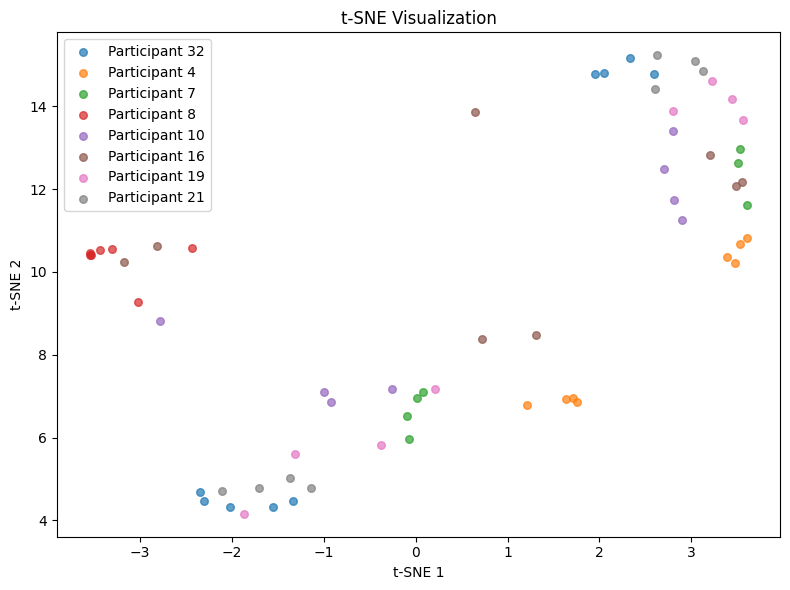

2026-02-06 17:23:58,346 - yolo_butterworth - INFO - Test set size for rank classification: 63
2026-02-06 17:23:58,347 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 17:23:58,347 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 17:23:58,348 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 17:23:58,371 - yolo_butterworth - INFO - k-NN eucl    | 0.5090     | 0.7962     | 0.9372
2026-02-06 17:23:58,390 - yolo_butterworth - INFO - k-NN manh    | 0.4756     | 0.7795     | 0.9205
2026-02-06 17:23:58,423 - yolo_butterworth - INFO - SVM          | 0.4769     | 0.6987     | 0.9372
2026-02-06 17:23:59,514 - yolo_butterworth - INFO - MLP          | 0.6051     | 0.8103     | 0.8897
2026-02-06 17:23:59,536 - yolo_butterworth - INFO - NB           | 0.4949     | 0.7487     | 0.8744
2026-02-06 17:23:59,575 - yolo_butterworth - INFO - LR           | 0.5397     | 0.7949     | 0.93

In [33]:
cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "lstm",
    learning_rate = 1e-4,
    batch_size = 128,
    n_epochs = 100,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-06 17:27:53,234 - yolo_butterworth - INFO - [Iteration 1/4]
2026-02-06 17:27:53,252 - yolo_butterworth - INFO - Train dataset size: 1642
2026-02-06 17:27:54,013 - yolo_butterworth - INFO - Epoch 1, Train Loss: 0.37331723937621486
2026-02-06 17:27:54,800 - yolo_butterworth - INFO - Epoch 2, Train Loss: 0.36100422275754124
2026-02-06 17:27:55,553 - yolo_butterworth - INFO - Epoch 3, Train Loss: 0.351922524949679
2026-02-06 17:27:56,397 - yolo_butterworth - INFO - Epoch 4, Train Loss: 0.3432635905650946
2026-02-06 17:27:57,200 - yolo_butterworth - INFO - Epoch 5, Train Loss: 0.3340670687074845
2026-02-06 17:27:58,090 - yolo_butterworth - INFO - Epoch 6, Train Loss: 0.32235088328329414
2026-02-06 17:27:58,887 - yolo_butterworth - INFO - Epoch 7, Train Loss: 0.3122923649274386
2026-02-06 17:27:59,655 - yolo_butterworth - INFO - Epoch 8, Train Loss: 0.3007875024699248
2026-02-06 17:28:00,430 - yolo_butterworth - INFO - Epoch 9, Train Loss: 0.2901260291154568
2026-02-06 17:28:01,211 -

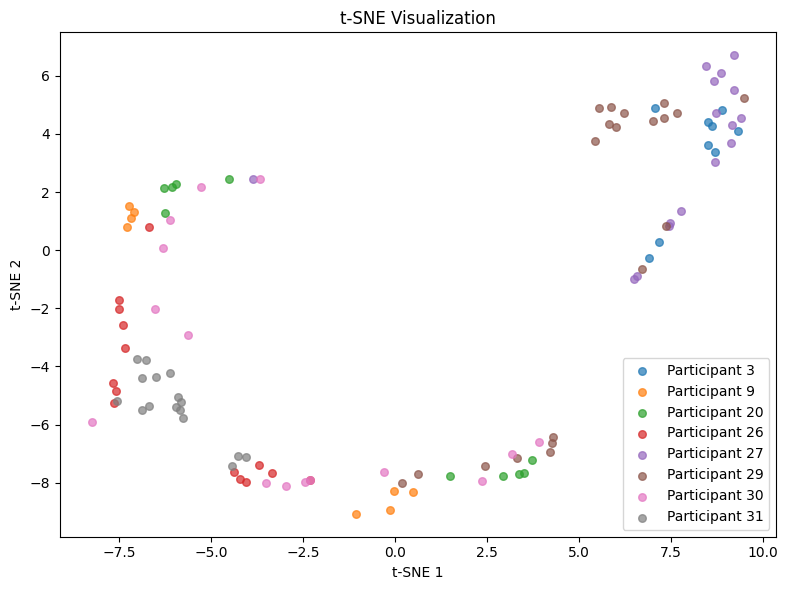

2026-02-06 17:29:53,471 - yolo_butterworth - INFO - Test set size for rank classification: 108
2026-02-06 17:29:53,472 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 17:29:53,473 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 17:29:53,473 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 17:29:53,494 - yolo_butterworth - INFO - k-NN eucl    | 0.5342     | 0.8411     | 0.9338
2026-02-06 17:29:53,513 - yolo_butterworth - INFO - k-NN manh    | 0.5242     | 0.8134     | 0.9061
2026-02-06 17:29:53,552 - yolo_butterworth - INFO - SVM          | 0.4528     | 0.7766     | 0.9810
2026-02-06 17:29:54,766 - yolo_butterworth - INFO - MLP          | 0.7013     | 0.8688     | 0.9714
2026-02-06 17:29:54,787 - yolo_butterworth - INFO - NB           | 0.3983     | 0.7316     | 0.9442
2026-02-06 17:29:54,844 - yolo_butterworth - INFO - LR           | 0.5459     | 0.8039     | 0.9

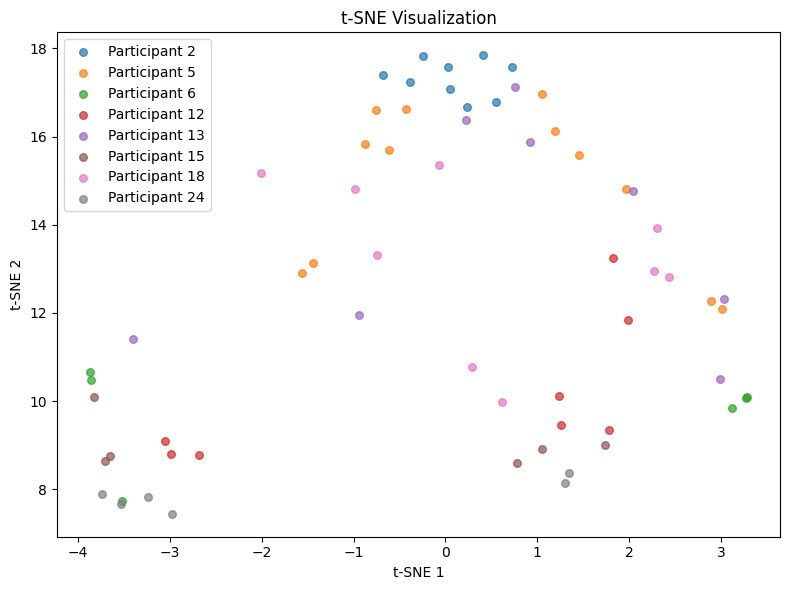

2026-02-06 17:33:14,215 - yolo_butterworth - INFO - Test set size for rank classification: 64
2026-02-06 17:33:14,216 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 17:33:14,217 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 17:33:14,217 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 17:33:14,239 - yolo_butterworth - INFO - k-NN eucl    | 0.4577     | 0.7205     | 0.7974
2026-02-06 17:33:14,259 - yolo_butterworth - INFO - k-NN manh    | 0.4282     | 0.7051     | 0.7821
2026-02-06 17:33:14,291 - yolo_butterworth - INFO - SVM          | 0.4538     | 0.7654     | 0.9064
2026-02-06 17:33:15,378 - yolo_butterworth - INFO - MLP          | 0.7500     | 0.8603     | 0.9064
2026-02-06 17:33:15,399 - yolo_butterworth - INFO - NB           | 0.5795     | 0.7359     | 0.8436
2026-02-06 17:33:15,444 - yolo_butterworth - INFO - LR           | 0.6090     | 0.7949     | 0.87

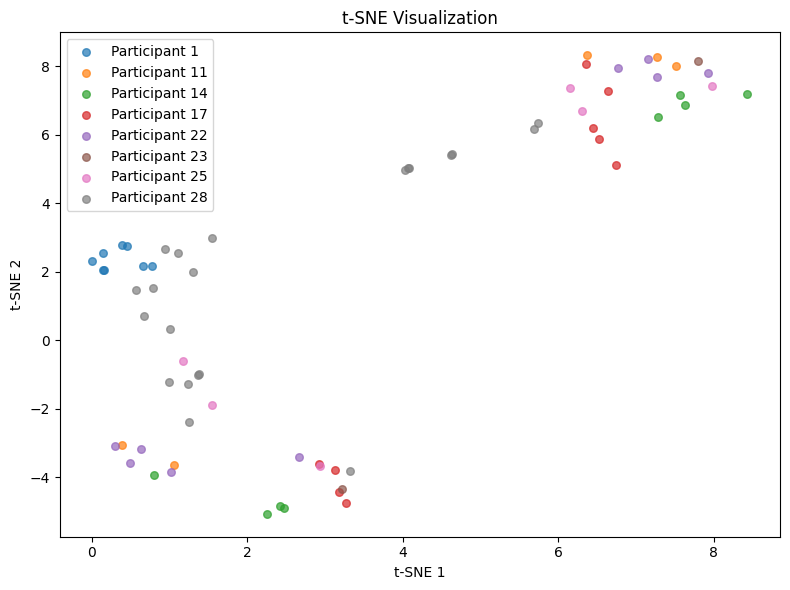

2026-02-06 17:36:11,812 - yolo_butterworth - INFO - Test set size for rank classification: 68
2026-02-06 17:36:11,813 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 17:36:11,814 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 17:36:11,814 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 17:36:11,836 - yolo_butterworth - INFO - k-NN eucl    | 0.6176     | 0.7813     | 0.8703
2026-02-06 17:36:11,856 - yolo_butterworth - INFO - k-NN manh    | 0.6011     | 0.7505     | 0.8549
2026-02-06 17:36:11,888 - yolo_butterworth - INFO - SVM          | 0.5308     | 0.7967     | 0.8538
2026-02-06 17:36:13,002 - yolo_butterworth - INFO - MLP          | 0.6780     | 0.8110     | 0.9132
2026-02-06 17:36:13,023 - yolo_butterworth - INFO - NB           | 0.5725     | 0.6912     | 0.7945
2026-02-06 17:36:13,070 - yolo_butterworth - INFO - LR           | 0.6330     | 0.7670     | 0.92

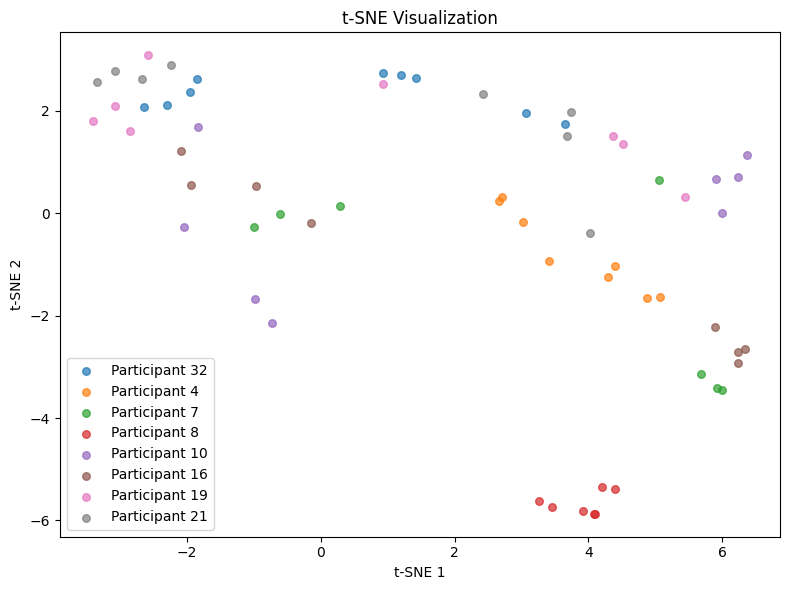

2026-02-06 17:39:28,653 - yolo_butterworth - INFO - Test set size for rank classification: 63
2026-02-06 17:39:28,655 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-06 17:39:28,655 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-06 17:39:28,656 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-06 17:39:28,679 - yolo_butterworth - INFO - k-NN eucl    | 0.5077     | 0.7808     | 0.9526
2026-02-06 17:39:28,700 - yolo_butterworth - INFO - k-NN manh    | 0.4731     | 0.8103     | 0.9372
2026-02-06 17:39:28,731 - yolo_butterworth - INFO - SVM          | 0.5859     | 0.7628     | 0.8744
2026-02-06 17:39:29,811 - yolo_butterworth - INFO - MLP          | 0.7128     | 0.8897     | 0.9359
2026-02-06 17:39:29,833 - yolo_butterworth - INFO - NB           | 0.4449     | 0.7167     | 0.8590
2026-02-06 17:39:29,873 - yolo_butterworth - INFO - LR           | 0.6372     | 0.7795     | 0.96

In [35]:
cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "lstm",
    learning_rate = 1e-5,
    batch_size = 32,
    n_epochs = 150,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-07 10:37:55,666 - yolo - INFO - Preparing cycles and participant labels...
2026-02-07 10:38:06,660 - yolo - INFO - [Iteration 1/4]
2026-02-07 10:38:06,686 - yolo - INFO - Train dataset size: 1944
2026-02-07 10:38:07,584 - yolo - INFO - Epoch 1, Train Loss: 0.35316886325351526
2026-02-07 10:38:08,474 - yolo - INFO - Epoch 2, Train Loss: 0.3432541206234791
2026-02-07 10:38:09,337 - yolo - INFO - Epoch 3, Train Loss: 0.33551892442781417
2026-02-07 10:38:10,205 - yolo - INFO - Epoch 4, Train Loss: 0.3283810745008656
2026-02-07 10:38:11,072 - yolo - INFO - Epoch 5, Train Loss: 0.32034820660215907
2026-02-07 10:38:11,995 - yolo - INFO - Epoch 6, Train Loss: 0.3101556218061291
2026-02-07 10:38:12,863 - yolo - INFO - Epoch 7, Train Loss: 0.3061648900391626
2026-02-07 10:38:13,760 - yolo - INFO - Epoch 8, Train Loss: 0.3020540092323647
2026-02-07 10:38:14,619 - yolo - INFO - Epoch 9, Train Loss: 0.2954604464476226
2026-02-07 10:38:15,494 - yolo - INFO - Epoch 10, Train Loss: 0.282441221

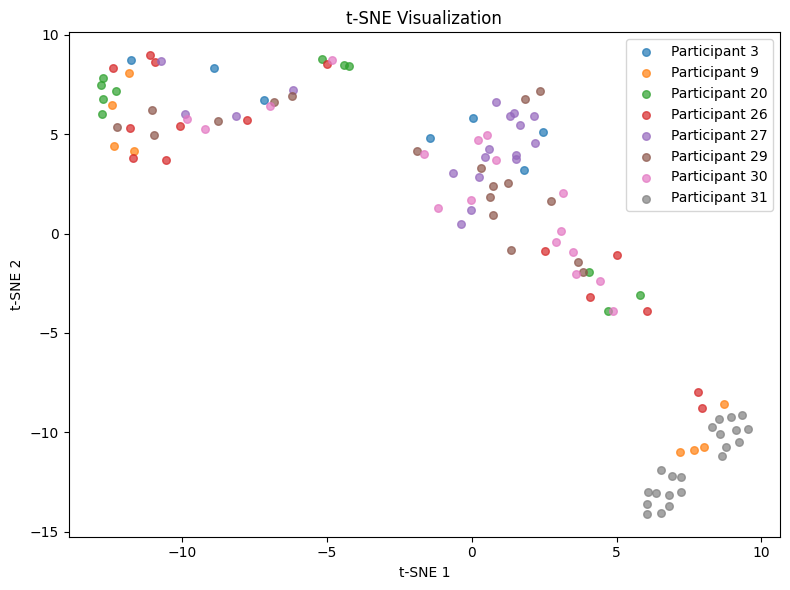

2026-02-07 10:40:20,300 - yolo - INFO - Test set size for rank classification: 115
2026-02-07 10:40:20,301 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-07 10:40:20,302 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-07 10:40:20,302 - yolo - INFO - -------------------------------------------------------
2026-02-07 10:40:20,325 - yolo - INFO - k-NN eucl    | 0.4435     | 0.6261     | 0.7478
2026-02-07 10:40:20,346 - yolo - INFO - k-NN manh    | 0.4522     | 0.6261     | 0.7304
2026-02-07 10:40:20,389 - yolo - INFO - SVM          | 0.4174     | 0.5652     | 0.7652
2026-02-07 10:40:21,626 - yolo - INFO - MLP          | 0.4435     | 0.6000     | 0.8174
2026-02-07 10:40:21,647 - yolo - INFO - NB           | 0.4261     | 0.5565     | 0.7391
2026-02-07 10:40:21,692 - yolo - INFO - LR           | 0.4696     | 0.6783     | 0.8000
2026-02-07 10:40:22,315 - yolo - INFO - RF           | 0.4870     | 0.6435     | 0.7478
2026-02-07 10:40:26,036 - yo

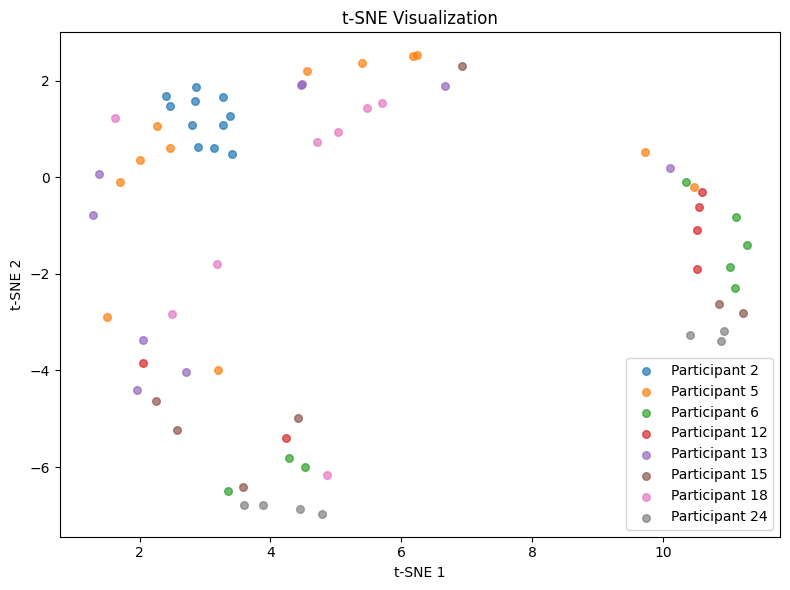

2026-02-07 10:44:00,801 - yolo - INFO - Test set size for rank classification: 68
2026-02-07 10:44:00,802 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-07 10:44:00,803 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-07 10:44:00,803 - yolo - INFO - -------------------------------------------------------
2026-02-07 10:44:00,824 - yolo - INFO - k-NN eucl    | 0.4956     | 0.6582     | 0.8077
2026-02-07 10:44:00,842 - yolo - INFO - k-NN manh    | 0.4802     | 0.6451     | 0.8077
2026-02-07 10:44:00,874 - yolo - INFO - SVM          | 0.2341     | 0.4846     | 0.7341
2026-02-07 10:44:01,976 - yolo - INFO - MLP          | 0.5264     | 0.7484     | 0.8077
2026-02-07 10:44:01,996 - yolo - INFO - NB           | 0.4242     | 0.5846     | 0.7758
2026-02-07 10:44:02,038 - yolo - INFO - LR           | 0.4374     | 0.6011     | 0.7495
2026-02-07 10:44:02,628 - yolo - INFO - RF           | 0.5571     | 0.7341     | 0.8088
2026-02-07 10:44:05,880 - yol

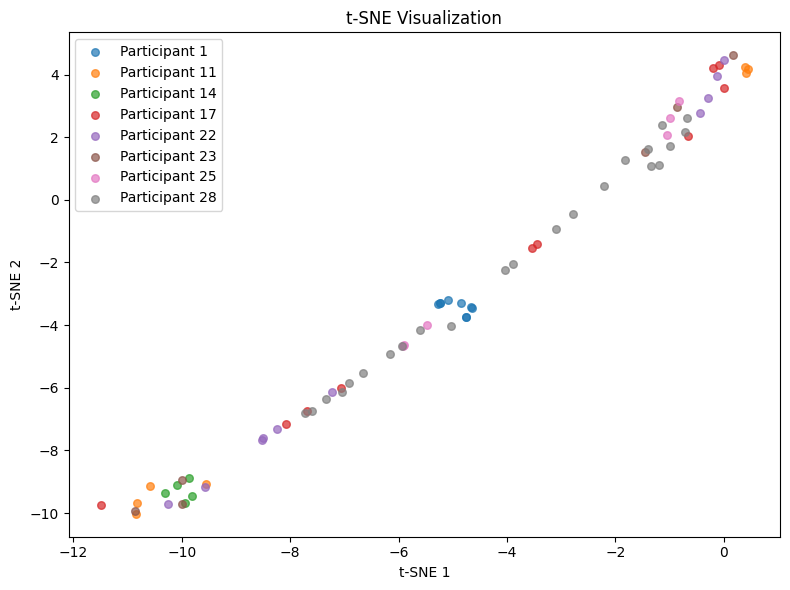

2026-02-07 10:47:16,680 - yolo - INFO - Test set size for rank classification: 76
2026-02-07 10:47:16,681 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-07 10:47:16,681 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-07 10:47:16,682 - yolo - INFO - -------------------------------------------------------
2026-02-07 10:47:16,705 - yolo - INFO - k-NN eucl    | 0.5008     | 0.6983     | 0.8033
2026-02-07 10:47:16,724 - yolo - INFO - k-NN manh    | 0.4875     | 0.6583     | 0.8033
2026-02-07 10:47:16,757 - yolo - INFO - SVM          | 0.4733     | 0.6058     | 0.7125
2026-02-07 10:47:17,889 - yolo - INFO - MLP          | 0.4983     | 0.6708     | 0.8817
2026-02-07 10:47:17,910 - yolo - INFO - NB           | 0.3950     | 0.5267     | 0.7367
2026-02-07 10:47:17,956 - yolo - INFO - LR           | 0.5125     | 0.6317     | 0.7625
2026-02-07 10:47:18,550 - yolo - INFO - RF           | 0.4733     | 0.7108     | 0.8433
2026-02-07 10:47:21,869 - yol

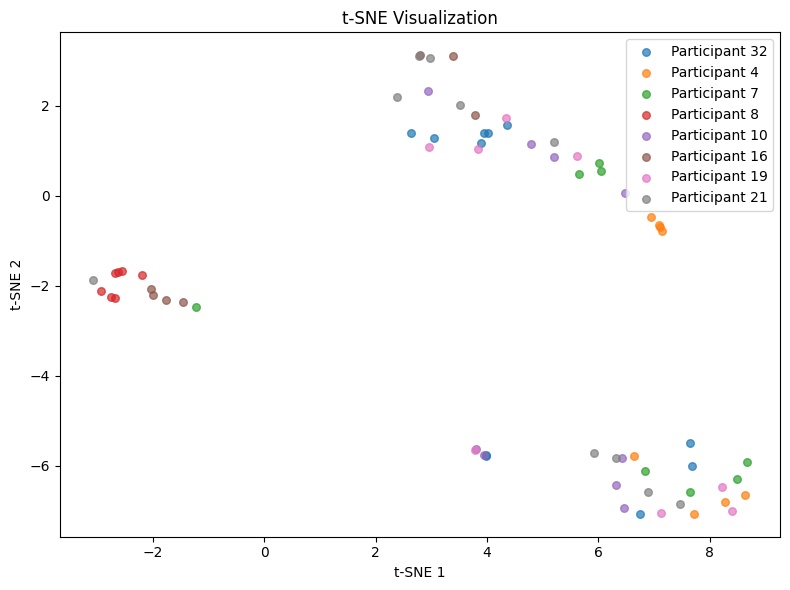

2026-02-07 10:50:59,799 - yolo - INFO - Test set size for rank classification: 68
2026-02-07 10:50:59,800 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-07 10:50:59,801 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-07 10:50:59,802 - yolo - INFO - -------------------------------------------------------
2026-02-07 10:50:59,822 - yolo - INFO - k-NN eucl    | 0.3099     | 0.6484     | 0.7374
2026-02-07 10:50:59,841 - yolo - INFO - k-NN manh    | 0.3242     | 0.6780     | 0.7374
2026-02-07 10:50:59,873 - yolo - INFO - SVM          | 0.4264     | 0.5440     | 0.6923
2026-02-07 10:51:00,968 - yolo - INFO - MLP          | 0.5747     | 0.7066     | 0.8242
2026-02-07 10:51:00,989 - yolo - INFO - NB           | 0.3835     | 0.5604     | 0.7505
2026-02-07 10:51:01,036 - yolo - INFO - LR           | 0.3681     | 0.5593     | 0.6758
2026-02-07 10:51:01,631 - yolo - INFO - RF           | 0.4275     | 0.6044     | 0.7945
2026-02-07 10:51:04,873 - yol

In [36]:
cv = CrossValidationSiameseRaw(
    sequence_cycles = yolo_cycles, 
    coordinates_idx = CoordinatesIdx(0, 1, 2), 
    log_level = logging.INFO,
    logger_name = 'yolo',
)

cv.perform_training_with_rank_classification(
    n_folds = 4,
    siamese_nn_type = "lstm",
    learning_rate = 1e-5,
    batch_size = 32,
    n_epochs = 150,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)